In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns
import torch
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from torch.utils.data import random_split
import torch.nn.functional as F
import torch.nn as nn
from collections import defaultdict
import random
from torch.distributions.normal import Normal
import torch.optim as optim
import gc
import pickle

In [3]:
import warnings

# Suppress DeprecationWarning for is_categorical_dtype
warnings.filterwarnings('ignore', category=DeprecationWarning)

# Suppress FutureWarning for use_inf_as_na
warnings.filterwarnings('ignore', category=FutureWarning)

# Parâmetros fixos

In [4]:
DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

LR = 0.001
PATIENCE = 5
IMAGE_SIZE = 32
CHANNELS = 1
BATCH_SIZE = 2*64
SHAPE_BEFORE_FLATTENING = (128, IMAGE_SIZE // 8, IMAGE_SIZE // 8)

# Carregamento e Segmentação dos Dados

In [5]:
train_data = datasets.MNIST(
    root = 'data',
    train = True,                         
    transform = transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.1307,), (0.3081,)),transforms.Pad(padding=2)]), 
    download = True,            
)
test_data = datasets.MNIST(
    root = 'data', 
    train = False, 
    transform = transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.1307,), (0.3081,)),transforms.Pad(padding=2)])
)

### Dataloaders para treinar o classificador

In [6]:
train_loader = torch.utils.data.DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=True)

### Dataloaders para treinar um VAE especializado em cada classe

In [7]:
def segmentar_dataset(dataset):
    
    datasets = defaultdict(list)
    
    for img, label in dataset:
        
        datasets[label].append(img)
        
    return datasets

In [8]:
%%time

subdatasets = segmentar_dataset(train_data)

loaders = {}

for classe, subdataset in subdatasets.items():
    
    loaders[classe]=torch.utils.data.DataLoader(subdataset, batch_size=BATCH_SIZE, shuffle=False)

CPU times: user 20.3 s, sys: 643 ms, total: 20.9 s
Wall time: 21.1 s


# Treinamento do Classificador

In [9]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(
                in_channels=1,              
                out_channels=16,            
                kernel_size=5,              
                stride=1,                   
                padding=2,                  
            ),                              
            nn.ReLU(),                      
            nn.MaxPool2d(kernel_size=2),    
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(16, 32, 5, 1, 2),     
            nn.ReLU(),                      
            nn.MaxPool2d(2),                
        )
        
        # Calculate the size after convolutional layers
        self._calculate_output_size()
        
        # Fully connected layer, output 10 classes
        self.dense1 = nn.Linear(self.flat_features, 10)
        
    def _calculate_output_size(self):
        # Test input to get the output size after conv layers
        with torch.no_grad():
            x = torch.zeros(1, 1, 32, 32)
            x = self.conv1(x)
            x = self.conv2(x)
            self.flat_features = x.numel()
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        # Flatten the output of conv2 to (batch_size, flat_features)
        x = x.view(x.size(0), -1)
        x = self.dense1(x)
        output = F.softmax(x, dim=1)
        return output

In [10]:
def test_model(net, testloader):
      """Evaluate the network on the entire test set."""
      criterion = torch.nn.CrossEntropyLoss()
      correct, total, loss = 0, 0, 0.0
      net.eval()
      with torch.no_grad():
          for batch in testloader:
              images, labels = batch[0].to(DEVICE), batch[1].to(DEVICE)
              outputs = net(images)
              loss += criterion(outputs, labels).item()
              _, predicted = torch.max(outputs.data, 1)
              total += labels.size(0)
              correct += (predicted == labels).sum().item()
            
          gc.collect()
                
      loss /= len(testloader.dataset)
      accuracy = correct / total
      return loss, accuracy

def train_model(net, trainloader=train_loader, valloader=test_loader, epochs=6):
    """Train the network on the training set."""
    
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(net.parameters())
    
    log = {'train_loss':[],'train_accuracy':[],'val_loss':[],'val_accuracy':[]}
    
    for epoch in range(epochs):
        
        print(f"Epoch {epoch+1}")
        
        net.train()
        
        correct, total, epoch_loss = 0, 0, 0.0
        
        for batch in trainloader:

            images, labels = batch[0].to(DEVICE), batch[1].to(DEVICE)
            optimizer.zero_grad() # reseta gradientes

            outputs = net(images)
            loss = criterion(outputs, labels)
            loss.backward()

            optimizer.step()
            # Metrics
            epoch_loss += loss
            total += labels.size(0)
            correct += (torch.max(outputs.data, 1)[1] == labels).sum().item()
            
        gc.collect()   
        log['train_loss'].append(epoch_loss/len(trainloader.dataset))
        log['train_accuracy'].append(correct / total)
        
        val_loss, val_acc = test_model(net, valloader)
        gc.collect()
        
        log['val_loss'].append(val_loss)
        log['val_accuracy'].append(val_acc)
        
    return log

In [10]:
%%time
model = Net()
model.to(DEVICE)
log = train_model(model)

Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
CPU times: user 2min 11s, sys: 685 ms, total: 2min 12s
Wall time: 2min 11s


In [11]:
for train_acc, val_acc in zip(log['train_accuracy'],log['val_accuracy']):
    print('Train acc: {:.2f}'.format(train_acc),'Val acc: {:.2f}'.format(val_acc))

Train acc: 0.79 Val acc: 0.97
Train acc: 0.98 Val acc: 0.98
Train acc: 0.98 Val acc: 0.99
Train acc: 0.99 Val acc: 0.99
Train acc: 0.99 Val acc: 0.99
Train acc: 0.99 Val acc: 0.99


In [12]:
with open('classificador.pkl', 'wb') as f:
    pickle.dump(model, f)

In [8]:
with open('classificador.pkl', 'rb') as f:
    model = pickle.load(f)

# Implementando o VAE

In [11]:
# define a class for sampling
# this class will be used in the encoder for sampling in the latent space
class Sampling(nn.Module):
    def forward(self, z_mean, z_log_var):
        # get the shape of the tensor for the mean and log variance
        batch, dim = z_mean.shape
        # generate a normal random tensor (epsilon) with the same shape as z_mean
        # this tensor will be used for reparameterization trick
        epsilon = Normal(0, 1).sample((batch, dim)).to(z_mean.device)
        # apply the reparameterization trick to generate the samples in the
        # latent space
        return z_mean + torch.exp(0.5 * z_log_var) * epsilon

In [12]:
##encoder with batch normalization and dropout

class Encoder(nn.Module):
    def __init__(self, image_size, embedding_dim):
        super(Encoder, self).__init__()
        # Define the convolutional layers with batch normalization
        self.conv1 = nn.Conv2d(1, 32, 3, stride=2, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, stride=2, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, 3, stride=2, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        # Define a flatten layer to flatten the tensor before feeding it into the fully connected layer
        self.flatten = nn.Flatten()
        
        # Define fully connected layers to transform the tensor into the desired embedding dimensions
        self.fc_mean = nn.Linear(128 * (image_size // 8) * (image_size // 8), embedding_dim)
        self.fc_log_var = nn.Linear(128 * (image_size // 8) * (image_size // 8), embedding_dim)
        
        # Define dropout layer
        self.dropout = nn.Dropout(0.5)
        
        # Initialize the sampling layer
        self.sampling = Sampling()

    def forward(self, x):
        # Apply convolutional layers with ReLU activation function and batch normalization
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        
        # Flatten the tensor
        x = self.flatten(x)
        
        # Apply dropout before the fully connected layers
        x = self.dropout(x)
        
        # Get the mean and log variance of the latent space distribution
        z_mean = self.fc_mean(x)
        z_log_var = self.fc_log_var(x)
        
        # Sample a latent vector using the reparameterization trick
        z = self.sampling(z_mean, z_log_var)
        
        return z_mean, z_log_var, z

In [11]:
# define the encoder
class Encoder(nn.Module):
    def __init__(self, image_size, embedding_dim):
        super(Encoder, self).__init__()
        # define the convolutional layers for downsampling and feature
        # extraction
        self.conv1 = nn.Conv2d(1, 32, 3, stride=2, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, stride=2, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, stride=2, padding=1)
        # define a flatten layer to flatten the tensor before feeding it into
        # the fully connected layer
        self.flatten = nn.Flatten()
        # define fully connected layers to transform the tensor into the desired
        # embedding dimensions
        self.fc_mean = nn.Linear(
            128 * (image_size // 8) * (image_size // 8), embedding_dim
        )
        self.fc_log_var = nn.Linear(
            128 * (image_size // 8) * (image_size // 8), embedding_dim
        )
        # initialize the sampling layer
        self.sampling = Sampling()
    def forward(self, x):
        # apply convolutional layers with relu activation function
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        # flatten the tensor
        x = self.flatten(x)
        # get the mean and log variance of the latent space distribution
        z_mean = self.fc_mean(x)
        z_log_var = self.fc_log_var(x)
        # sample a latent vector using the reparameterization trick
        z = self.sampling(z_mean, z_log_var)
        return z_mean, z_log_var, z

In [13]:
# define the decoder
class Decoder(nn.Module):
    def __init__(self, embedding_dim, shape_before_flattening):
        super(Decoder, self).__init__()
        # define a fully connected layer to transform the latent vector back to
        # the shape before flattening
        self.fc = nn.Linear(
            embedding_dim,
            shape_before_flattening[0]
            * shape_before_flattening[1]
            * shape_before_flattening[2],
        )
        # define a reshape function to reshape the tensor back to its original
        # shape
        self.reshape = lambda x: x.view(-1, *shape_before_flattening)
        # define the transposed convolutional layers for the decoder to upsample
        # and generate the reconstructed image
        self.deconv1 = nn.ConvTranspose2d(
            128, 64, 3, stride=2, padding=1, output_padding=1
        )
        self.deconv2 = nn.ConvTranspose2d(
            64, 32, 3, stride=2, padding=1, output_padding=1
        )
        self.deconv3 = nn.ConvTranspose2d(
            32, 1, 3, stride=2, padding=1, output_padding=1
        )
    def forward(self, x):
        # pass the latent vector through the fully connected layer
        x = self.fc(x)
        # reshape the tensor
        x = self.reshape(x)
        # apply transposed convolutional layers with relu activation function
        x = F.relu(self.deconv1(x))
        x = F.relu(self.deconv2(x))
        # apply the final transposed convolutional layer with a sigmoid
        # activation to generate the final output
        x = torch.sigmoid(self.deconv3(x))
        return x

In [14]:
class VAE(nn.Module):
    def __init__(self, encoder, decoder):
        super(VAE, self).__init__()
        # initialize the encoder and decoder
        self.encoder = encoder
        self.decoder = decoder
    def forward(self, x):
        # pass the input through the encoder to get the latent vector
        z_mean, z_log_var, z = self.encoder(x)
        # pass the latent vector through the decoder to get the reconstructed
        # image
        reconstruction = self.decoder(z)
        # return the mean, log variance and the reconstructed image
        return z_mean, z_log_var, reconstruction

In [15]:
def vae_gaussian_kl_loss(mu, logvar):
    # see Appendix B from VAE paper:
    # Kingma and Welling. Auto-Encoding Variational Bayes. ICLR, 2014
    # https://arxiv.org/abs/1312.6114
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
    return KLD.mean()
def reconstruction_loss(x_reconstructed, x):
    mse_loss = nn.MSELoss()
    return mse_loss(x_reconstructed, x)
def vae_loss(y_pred, y_true, lamb):
    mu, logvar, recon_x = y_pred
    recon_loss = reconstruction_loss(recon_x, y_true)
    kld_loss = vae_gaussian_kl_loss(mu, logvar)
    return (lamb * recon_loss + (1-lamb)*kld_loss), recon_loss, kld_loss

In [16]:
def train_vae(EMBEDDING_DIM,EPOCHS,LAMB, train_loader, sch=False):
    
    log={'total_loss':[],'recon_loss':[],'kld_loss':[]}
    
    # instantiate the encoder and decoder models
    encoder = Encoder(IMAGE_SIZE, EMBEDDING_DIM).to(DEVICE)
    decoder = Decoder(EMBEDDING_DIM, SHAPE_BEFORE_FLATTENING).to(DEVICE)
    # pass the encoder and decoder to VAE class
    vae = VAE(encoder, decoder).to(DEVICE)
    
    optimizer = optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=LR)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.1, patience=5)
    #scheduler = torch.optim.lr_scheduler.CyclicLR(optimizer, base_lr=0.01, max_lr=0.1, step_size_up=1000, mode='triangular')
        
    for epoch in range(EPOCHS):
        # set the vae model to train mode
        # and move it to CPU/GPU
        vae.train()
        vae.to(DEVICE)
        running_loss = 0.0
        total_recon_loss = 0.0
        total_kld_loss = 0.0
    
        # loop over the batches of the training dataset
        for batch_idx, data in enumerate(train_loader):
            data = data.to(DEVICE)
            optimizer.zero_grad()
            # forward pass through the VAE
            pred = vae(data)
            # compute the VAE loss
            loss, recon_loss, kld_loss = vae_loss(pred, data,lamb=LAMB)
            # backward pass and optimizer step
            loss.backward()
            optimizer.step()
            
            if sch:
                scheduler.step(loss)
            
            running_loss += loss.item()
            total_recon_loss+= recon_loss.item()
            total_kld_loss += kld_loss.item()
        
    
        # compute average loss for the epoch
        total_loss = running_loss / len(train_loader)
        epoch_recon_loss = total_recon_loss / len(train_loader)
        epoch_kld_loss = total_kld_loss / len(train_loader)
        
        log['total_loss'].append(running_loss / len(train_loader))
        log['recon_loss'].append(total_recon_loss / len(train_loader))
        log['kld_loss'].append(total_kld_loss / len(train_loader))
    
        # print training and validation loss at every 50 epochs
        if epoch % 50 == 0 or (epoch+1) == EPOCHS:
            print(
                f"Epoch {epoch} | Total Loss: {log['total_loss'][epoch]:.4f} | Reconstruction Loss: {log['recon_loss'][epoch]:.4f} | KLD Loss: {log['kld_loss'][epoch]:.4f}"
            )
            
    return encoder, decoder, vae, log

# Dado um VAE treinado, gerar o espaço latente

In [17]:
def latent_space(dataloader, encoder):
    
    latent_space = []

    for data in dataloader:

        z_mean, z_log_var, z = encoder(data.to(DEVICE))

        for mu, var in zip(z_mean,z_log_var):

            latent_space.append((mu,var))
            
    return latent_space

# Dado um espaço latente, plotar amostras de reconstruções

In [18]:
def plot_sample(latent_space, decoder, n=1):
    
    def sample_from_dist(z_mean, z_log_var):
        dim = z_mean.shape
        # generate a normal random tensor (epsilon) with the same shape as z_mean
        # this tensor will be used for reparameterization trick
        epsilon = Normal(0, 1).sample(dim).to(z_mean.device)
        # apply the reparameterization trick to generate the samples in the
        # latent space
        return z_mean + torch.exp(0.5 * z_log_var) * epsilon
    
    fig, ax = plt.subplots(1,n)
    
    for i in range(n):
        
        sample_dist = random.choice(latent_space)

        sample = sample_from_dist(sample_dist[0],sample_dist[1])

        sample_reconstructed = decoder(sample)

        ax[i].imshow(sample_reconstructed.cpu().detach().numpy().reshape((32,32)))
        
        ax[i].grid(False)
        ax[i].axis('off')
        
    plt.show()

# Teste

In [75]:
%%time
test_encoder, test_decoder, test_vae, log = train_vae(EMBEDDING_DIM=2,EPOCHS=1000,LAMB=0.999, train_loader=loaders[2])

Epoch 0 | Total Loss: 0.6744 | Reconstruction Loss: 0.6615 | KLD Loss: 13.5078
Epoch 50 | Total Loss: 0.5355 | Reconstruction Loss: 0.5302 | KLD Loss: 5.8015
Epoch 100 | Total Loss: 0.5307 | Reconstruction Loss: 0.5249 | KLD Loss: 6.2623
Epoch 150 | Total Loss: 0.5277 | Reconstruction Loss: 0.5218 | KLD Loss: 6.3992
Epoch 200 | Total Loss: 0.5260 | Reconstruction Loss: 0.5199 | KLD Loss: 6.5642
Epoch 250 | Total Loss: 0.5245 | Reconstruction Loss: 0.5184 | KLD Loss: 6.6450
Epoch 300 | Total Loss: 0.5234 | Reconstruction Loss: 0.5172 | KLD Loss: 6.7428
Epoch 350 | Total Loss: 0.5225 | Reconstruction Loss: 0.5162 | KLD Loss: 6.8495
Epoch 400 | Total Loss: 0.5218 | Reconstruction Loss: 0.5153 | KLD Loss: 6.9665
Epoch 450 | Total Loss: 0.5210 | Reconstruction Loss: 0.5146 | KLD Loss: 6.9352
Epoch 500 | Total Loss: 0.5202 | Reconstruction Loss: 0.5138 | KLD Loss: 6.9052
Epoch 550 | Total Loss: 0.5196 | Reconstruction Loss: 0.5131 | KLD Loss: 6.9939
Epoch 600 | Total Loss: 0.5193 | Reconstru

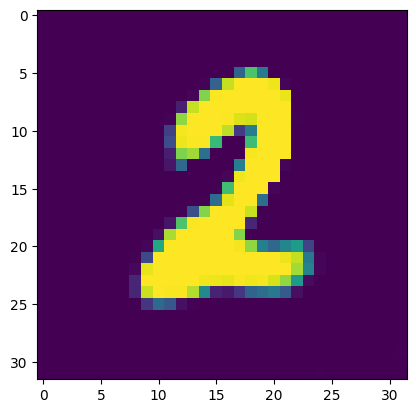

In [76]:
l_space =latent_space(loaders[2], test_encoder)
plot_sample(l_space, test_decoder)

In [77]:
%%time
test_encoder, test_decoder, test_vae, log = train_vae(EMBEDDING_DIM=1000,EPOCHS=1000,LAMB=0.999, train_loader=loaders[2])

Epoch 0 | Total Loss: 0.8070 | Reconstruction Loss: 0.7451 | KLD Loss: 62.6299
Epoch 50 | Total Loss: 0.4929 | Reconstruction Loss: 0.4597 | KLD Loss: 33.6346
Epoch 100 | Total Loss: 0.4809 | Reconstruction Loss: 0.4490 | KLD Loss: 32.3564
Epoch 150 | Total Loss: 0.4621 | Reconstruction Loss: 0.4345 | KLD Loss: 27.9673
Epoch 200 | Total Loss: 0.4562 | Reconstruction Loss: 0.4299 | KLD Loss: 26.8093
Epoch 250 | Total Loss: 0.4531 | Reconstruction Loss: 0.4270 | KLD Loss: 26.6224
Epoch 300 | Total Loss: 0.4511 | Reconstruction Loss: 0.4252 | KLD Loss: 26.3446
Epoch 350 | Total Loss: 0.4496 | Reconstruction Loss: 0.4239 | KLD Loss: 26.0873
Epoch 400 | Total Loss: 0.4489 | Reconstruction Loss: 0.4231 | KLD Loss: 26.2292
Epoch 450 | Total Loss: 0.4479 | Reconstruction Loss: 0.4222 | KLD Loss: 26.0675
Epoch 500 | Total Loss: 0.4473 | Reconstruction Loss: 0.4218 | KLD Loss: 26.0161
Epoch 550 | Total Loss: 0.4468 | Reconstruction Loss: 0.4213 | KLD Loss: 25.9057
Epoch 600 | Total Loss: 0.4460 

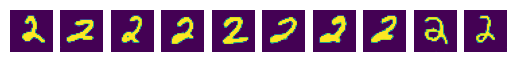

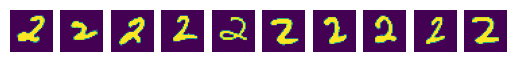

In [110]:
l_space =latent_space(loaders[2], test_encoder)
plot_sample(l_space, test_decoder, 10)
plot_sample(l_space, test_decoder, 10)

# Fine-tuning the VAE

In [113]:
params = {'lambda':[0.90,0.99,0.9990,0.99990],'embedding_dim':[2,10,100,1000,2000,4000]}

In [125]:
params

{'lambda': [0.9, 0.99, 0.999, 0.9999],
 'embedding_dim': [2, 10, 100, 1000, 2000, 4000]}

In [22]:
def grid_search(params, classe):
    
    output = []
    
    data_loader = loaders[classe]
    
    for lamb in params['lambda']:
        
        for embedding_dim in params['embedding_dim']:
            
            print('Lambda: ',lamb,'|',"Embedding Dim: ", embedding_dim)
            print('---------------------------------------------------------')
              
            encoder, decoder, vae, log = train_vae(EMBEDDING_DIM=embedding_dim,EPOCHS=300,LAMB=lamb, train_loader=data_loader)
            
            output.append({'lambda':lamb,'embedding_dim':embedding_dim,'log':log})
                
            l_space = latent_space(data_loader, encoder)
            
            plot_sample(l_space, decoder, 10)
            
    with open(f'log_{classe}.pkl', 'wb') as f:
                pickle.dump(output, f)
            
    return output

Classe:  0 

Lambda:  0.9 | Embedding Dim:  2
---------------------------------------------------------
Epoch 0 | Total Loss: 0.7126 | Reconstruction Loss: 0.7646 | KLD Loss: 0.2450
Epoch 50 | Total Loss: 0.5768 | Reconstruction Loss: 0.6408 | KLD Loss: 0.0010
Epoch 100 | Total Loss: 0.5767 | Reconstruction Loss: 0.6408 | KLD Loss: 0.0000
Epoch 150 | Total Loss: 0.5766 | Reconstruction Loss: 0.6406 | KLD Loss: 0.0000
Epoch 200 | Total Loss: 0.5765 | Reconstruction Loss: 0.6406 | KLD Loss: 0.0000
Epoch 250 | Total Loss: 0.5765 | Reconstruction Loss: 0.6405 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.5765 | Reconstruction Loss: 0.6405 | KLD Loss: 0.0000


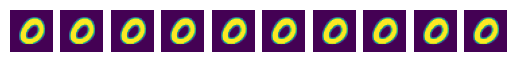

Lambda:  0.9 | Embedding Dim:  10
---------------------------------------------------------
Epoch 0 | Total Loss: 0.8179 | Reconstruction Loss: 0.8224 | KLD Loss: 0.7778
Epoch 50 | Total Loss: 0.5770 | Reconstruction Loss: 0.6410 | KLD Loss: 0.0008
Epoch 100 | Total Loss: 0.5767 | Reconstruction Loss: 0.6407 | KLD Loss: 0.0002
Epoch 150 | Total Loss: 0.5766 | Reconstruction Loss: 0.6407 | KLD Loss: 0.0000
Epoch 200 | Total Loss: 0.5766 | Reconstruction Loss: 0.6406 | KLD Loss: 0.0000
Epoch 250 | Total Loss: 0.5765 | Reconstruction Loss: 0.6406 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.5765 | Reconstruction Loss: 0.6406 | KLD Loss: 0.0000


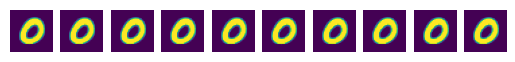

Lambda:  0.9 | Embedding Dim:  100
---------------------------------------------------------
Epoch 0 | Total Loss: 1.3911 | Reconstruction Loss: 0.9403 | KLD Loss: 5.4479
Epoch 50 | Total Loss: 0.5770 | Reconstruction Loss: 0.6410 | KLD Loss: 0.0008
Epoch 100 | Total Loss: 0.5768 | Reconstruction Loss: 0.6408 | KLD Loss: 0.0001
Epoch 150 | Total Loss: 0.5766 | Reconstruction Loss: 0.6407 | KLD Loss: 0.0000
Epoch 200 | Total Loss: 0.5766 | Reconstruction Loss: 0.6406 | KLD Loss: 0.0000
Epoch 250 | Total Loss: 0.5765 | Reconstruction Loss: 0.6406 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.5765 | Reconstruction Loss: 0.6406 | KLD Loss: 0.0000


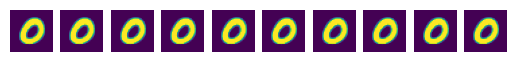

Lambda:  0.9 | Embedding Dim:  1000
---------------------------------------------------------
Epoch 0 | Total Loss: 5.4000 | Reconstruction Loss: 0.9434 | KLD Loss: 45.5094
Epoch 50 | Total Loss: 0.5774 | Reconstruction Loss: 0.6414 | KLD Loss: 0.0015
Epoch 100 | Total Loss: 0.5768 | Reconstruction Loss: 0.6409 | KLD Loss: 0.0001
Epoch 150 | Total Loss: 0.5767 | Reconstruction Loss: 0.6408 | KLD Loss: 0.0000
Epoch 200 | Total Loss: 0.5766 | Reconstruction Loss: 0.6407 | KLD Loss: 0.0000
Epoch 250 | Total Loss: 0.5766 | Reconstruction Loss: 0.6406 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.5766 | Reconstruction Loss: 0.6406 | KLD Loss: 0.0000


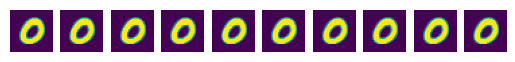

Lambda:  0.9 | Embedding Dim:  2000
---------------------------------------------------------
Epoch 0 | Total Loss: 9.6710 | Reconstruction Loss: 0.9464 | KLD Loss: 88.1927
Epoch 50 | Total Loss: 0.5780 | Reconstruction Loss: 0.6420 | KLD Loss: 0.0026
Epoch 100 | Total Loss: 0.5771 | Reconstruction Loss: 0.6413 | KLD Loss: 0.0001
Epoch 150 | Total Loss: 0.5769 | Reconstruction Loss: 0.6409 | KLD Loss: 0.0000
Epoch 200 | Total Loss: 0.5767 | Reconstruction Loss: 0.6408 | KLD Loss: 0.0000
Epoch 250 | Total Loss: 0.5767 | Reconstruction Loss: 0.6407 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.5766 | Reconstruction Loss: 0.6407 | KLD Loss: 0.0000


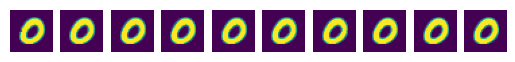

Lambda:  0.9 | Embedding Dim:  4000
---------------------------------------------------------
Epoch 0 | Total Loss: 18.7241 | Reconstruction Loss: 0.9380 | KLD Loss: 178.7991
Epoch 50 | Total Loss: 0.5788 | Reconstruction Loss: 0.6426 | KLD Loss: 0.0050
Epoch 100 | Total Loss: 0.5773 | Reconstruction Loss: 0.6414 | KLD Loss: 0.0001
Epoch 150 | Total Loss: 0.5770 | Reconstruction Loss: 0.6411 | KLD Loss: 0.0000
Epoch 200 | Total Loss: 0.5768 | Reconstruction Loss: 0.6409 | KLD Loss: 0.0001
Epoch 250 | Total Loss: 0.5767 | Reconstruction Loss: 0.6408 | KLD Loss: 0.0001
Epoch 299 | Total Loss: 0.5767 | Reconstruction Loss: 0.6407 | KLD Loss: 0.0001


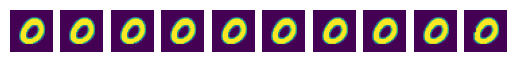

Lambda:  0.99 | Embedding Dim:  2
---------------------------------------------------------
Epoch 0 | Total Loss: 0.7406 | Reconstruction Loss: 0.7246 | KLD Loss: 2.3270
Epoch 50 | Total Loss: 0.5743 | Reconstruction Loss: 0.5527 | KLD Loss: 2.7098
Epoch 100 | Total Loss: 0.5728 | Reconstruction Loss: 0.5509 | KLD Loss: 2.7419
Epoch 150 | Total Loss: 0.5725 | Reconstruction Loss: 0.5503 | KLD Loss: 2.7702
Epoch 200 | Total Loss: 0.5719 | Reconstruction Loss: 0.5493 | KLD Loss: 2.8057
Epoch 250 | Total Loss: 0.5716 | Reconstruction Loss: 0.5490 | KLD Loss: 2.8177
Epoch 299 | Total Loss: 0.5712 | Reconstruction Loss: 0.5484 | KLD Loss: 2.8288


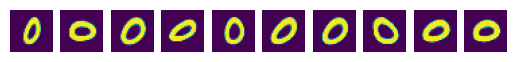

Lambda:  0.99 | Embedding Dim:  10
---------------------------------------------------------
Epoch 0 | Total Loss: 0.7994 | Reconstruction Loss: 0.7825 | KLD Loss: 2.4708
Epoch 50 | Total Loss: 0.5626 | Reconstruction Loss: 0.5217 | KLD Loss: 4.6133
Epoch 100 | Total Loss: 0.5619 | Reconstruction Loss: 0.5198 | KLD Loss: 4.7260
Epoch 150 | Total Loss: 0.5608 | Reconstruction Loss: 0.5187 | KLD Loss: 4.7217
Epoch 200 | Total Loss: 0.5602 | Reconstruction Loss: 0.5178 | KLD Loss: 4.7524
Epoch 250 | Total Loss: 0.5599 | Reconstruction Loss: 0.5175 | KLD Loss: 4.7553
Epoch 299 | Total Loss: 0.5599 | Reconstruction Loss: 0.5173 | KLD Loss: 4.7703


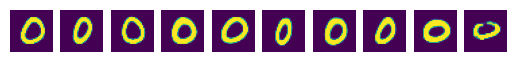

Lambda:  0.99 | Embedding Dim:  100
---------------------------------------------------------
Epoch 0 | Total Loss: 0.9080 | Reconstruction Loss: 0.8418 | KLD Loss: 7.4624
Epoch 50 | Total Loss: 0.5658 | Reconstruction Loss: 0.5284 | KLD Loss: 4.2662
Epoch 100 | Total Loss: 0.5637 | Reconstruction Loss: 0.5238 | KLD Loss: 4.5068
Epoch 150 | Total Loss: 0.5622 | Reconstruction Loss: 0.5223 | KLD Loss: 4.5162
Epoch 200 | Total Loss: 0.5614 | Reconstruction Loss: 0.5214 | KLD Loss: 4.5306
Epoch 250 | Total Loss: 0.5614 | Reconstruction Loss: 0.5208 | KLD Loss: 4.5829
Epoch 299 | Total Loss: 0.5610 | Reconstruction Loss: 0.5201 | KLD Loss: 4.6061


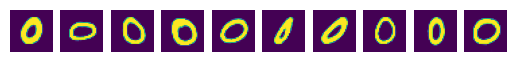

Lambda:  0.99 | Embedding Dim:  1000
---------------------------------------------------------
Epoch 0 | Total Loss: 1.3429 | Reconstruction Loss: 0.8805 | KLD Loss: 47.1259
Epoch 50 | Total Loss: 0.5984 | Reconstruction Loss: 0.5713 | KLD Loss: 3.2801
Epoch 100 | Total Loss: 0.5973 | Reconstruction Loss: 0.5697 | KLD Loss: 3.3221
Epoch 150 | Total Loss: 0.5959 | Reconstruction Loss: 0.5679 | KLD Loss: 3.3634
Epoch 200 | Total Loss: 0.5947 | Reconstruction Loss: 0.5661 | KLD Loss: 3.4309
Epoch 250 | Total Loss: 0.5919 | Reconstruction Loss: 0.5628 | KLD Loss: 3.4731
Epoch 299 | Total Loss: 0.5741 | Reconstruction Loss: 0.5426 | KLD Loss: 3.6940


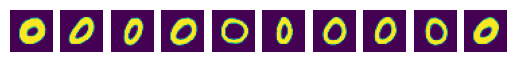

Lambda:  0.99 | Embedding Dim:  2000
---------------------------------------------------------
Epoch 0 | Total Loss: 1.7617 | Reconstruction Loss: 0.8555 | KLD Loss: 91.4758
Epoch 50 | Total Loss: 0.6000 | Reconstruction Loss: 0.5735 | KLD Loss: 3.2268
Epoch 100 | Total Loss: 0.5984 | Reconstruction Loss: 0.5707 | KLD Loss: 3.3364
Epoch 150 | Total Loss: 0.5982 | Reconstruction Loss: 0.5703 | KLD Loss: 3.3629
Epoch 200 | Total Loss: 0.5972 | Reconstruction Loss: 0.5694 | KLD Loss: 3.3564
Epoch 250 | Total Loss: 0.5959 | Reconstruction Loss: 0.5679 | KLD Loss: 3.3725
Epoch 299 | Total Loss: 0.5962 | Reconstruction Loss: 0.5679 | KLD Loss: 3.4009


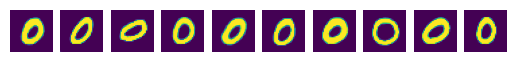

Lambda:  0.99 | Embedding Dim:  4000
---------------------------------------------------------
Epoch 0 | Total Loss: 2.5585 | Reconstruction Loss: 0.8419 | KLD Loss: 172.5066
Epoch 50 | Total Loss: 0.6030 | Reconstruction Loss: 0.5763 | KLD Loss: 3.2509
Epoch 100 | Total Loss: 0.6008 | Reconstruction Loss: 0.5744 | KLD Loss: 3.2115
Epoch 150 | Total Loss: 0.5982 | Reconstruction Loss: 0.5721 | KLD Loss: 3.1820
Epoch 200 | Total Loss: 0.5974 | Reconstruction Loss: 0.5708 | KLD Loss: 3.2319
Epoch 250 | Total Loss: 0.5974 | Reconstruction Loss: 0.5703 | KLD Loss: 3.2817
Epoch 299 | Total Loss: 0.5981 | Reconstruction Loss: 0.5706 | KLD Loss: 3.3252


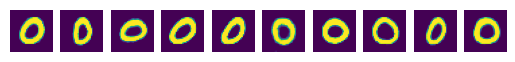

Lambda:  0.999 | Embedding Dim:  2
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6797 | Reconstruction Loss: 0.6638 | KLD Loss: 16.5353
Epoch 50 | Total Loss: 0.5450 | Reconstruction Loss: 0.5401 | KLD Loss: 5.4821
Epoch 100 | Total Loss: 0.5430 | Reconstruction Loss: 0.5379 | KLD Loss: 5.6826
Epoch 150 | Total Loss: 0.5411 | Reconstruction Loss: 0.5358 | KLD Loss: 5.8461
Epoch 200 | Total Loss: 0.5397 | Reconstruction Loss: 0.5342 | KLD Loss: 6.0091
Epoch 250 | Total Loss: 0.5384 | Reconstruction Loss: 0.5327 | KLD Loss: 6.1771
Epoch 299 | Total Loss: 0.5374 | Reconstruction Loss: 0.5315 | KLD Loss: 6.3447


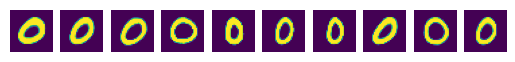

Lambda:  0.999 | Embedding Dim:  10
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6723 | Reconstruction Loss: 0.6482 | KLD Loss: 24.7954
Epoch 50 | Total Loss: 0.4903 | Reconstruction Loss: 0.4727 | KLD Loss: 18.0437
Epoch 100 | Total Loss: 0.4876 | Reconstruction Loss: 0.4704 | KLD Loss: 17.7388
Epoch 150 | Total Loss: 0.4864 | Reconstruction Loss: 0.4692 | KLD Loss: 17.7066
Epoch 200 | Total Loss: 0.4856 | Reconstruction Loss: 0.4684 | KLD Loss: 17.7493
Epoch 250 | Total Loss: 0.4849 | Reconstruction Loss: 0.4677 | KLD Loss: 17.6729
Epoch 299 | Total Loss: 0.4844 | Reconstruction Loss: 0.4670 | KLD Loss: 17.7994


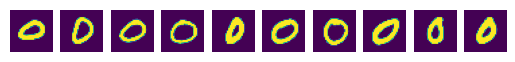

Lambda:  0.999 | Embedding Dim:  100
---------------------------------------------------------
Epoch 0 | Total Loss: 0.7685 | Reconstruction Loss: 0.7429 | KLD Loss: 26.3259
Epoch 50 | Total Loss: 0.4921 | Reconstruction Loss: 0.4723 | KLD Loss: 20.2226
Epoch 100 | Total Loss: 0.4892 | Reconstruction Loss: 0.4697 | KLD Loss: 20.0125
Epoch 150 | Total Loss: 0.4876 | Reconstruction Loss: 0.4682 | KLD Loss: 19.9286
Epoch 200 | Total Loss: 0.4867 | Reconstruction Loss: 0.4674 | KLD Loss: 19.7542
Epoch 250 | Total Loss: 0.4858 | Reconstruction Loss: 0.4664 | KLD Loss: 19.7797
Epoch 299 | Total Loss: 0.4850 | Reconstruction Loss: 0.4660 | KLD Loss: 19.5200


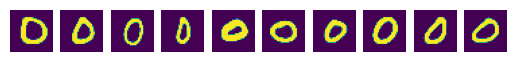

Lambda:  0.999 | Embedding Dim:  1000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.8553 | Reconstruction Loss: 0.7729 | KLD Loss: 83.1445
Epoch 50 | Total Loss: 0.5225 | Reconstruction Loss: 0.4964 | KLD Loss: 26.5864
Epoch 100 | Total Loss: 0.5009 | Reconstruction Loss: 0.4801 | KLD Loss: 21.2457
Epoch 150 | Total Loss: 0.4944 | Reconstruction Loss: 0.4748 | KLD Loss: 20.0538
Epoch 200 | Total Loss: 0.4914 | Reconstruction Loss: 0.4721 | KLD Loss: 19.8073
Epoch 250 | Total Loss: 0.4901 | Reconstruction Loss: 0.4709 | KLD Loss: 19.6810
Epoch 299 | Total Loss: 0.4892 | Reconstruction Loss: 0.4702 | KLD Loss: 19.4665


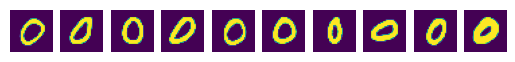

Lambda:  0.999 | Embedding Dim:  2000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.8955 | Reconstruction Loss: 0.7854 | KLD Loss: 110.8845
Epoch 50 | Total Loss: 0.5264 | Reconstruction Loss: 0.4995 | KLD Loss: 27.3861
Epoch 100 | Total Loss: 0.5226 | Reconstruction Loss: 0.4954 | KLD Loss: 27.6480
Epoch 150 | Total Loss: 0.5211 | Reconstruction Loss: 0.4934 | KLD Loss: 28.1353
Epoch 200 | Total Loss: 0.5192 | Reconstruction Loss: 0.4919 | KLD Loss: 27.8229
Epoch 250 | Total Loss: 0.5149 | Reconstruction Loss: 0.4889 | KLD Loss: 26.4719
Epoch 299 | Total Loss: 0.5114 | Reconstruction Loss: 0.4868 | KLD Loss: 25.0493


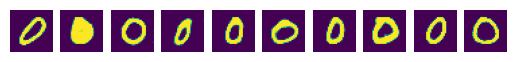

Lambda:  0.999 | Embedding Dim:  4000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.9544 | Reconstruction Loss: 0.7250 | KLD Loss: 230.0786
Epoch 50 | Total Loss: 0.5284 | Reconstruction Loss: 0.5009 | KLD Loss: 28.0184
Epoch 100 | Total Loss: 0.5246 | Reconstruction Loss: 0.4967 | KLD Loss: 28.3516
Epoch 150 | Total Loss: 0.5221 | Reconstruction Loss: 0.4943 | KLD Loss: 28.3199
Epoch 200 | Total Loss: 0.5205 | Reconstruction Loss: 0.4928 | KLD Loss: 28.1799
Epoch 250 | Total Loss: 0.5193 | Reconstruction Loss: 0.4917 | KLD Loss: 28.1259
Epoch 299 | Total Loss: 0.5188 | Reconstruction Loss: 0.4913 | KLD Loss: 27.9935


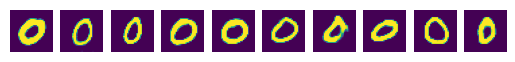

Lambda:  0.9999 | Embedding Dim:  2
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6648 | Reconstruction Loss: 0.6570 | KLD Loss: 78.7045
Epoch 50 | Total Loss: 0.5397 | Reconstruction Loss: 0.5389 | KLD Loss: 9.1337
Epoch 100 | Total Loss: 0.5364 | Reconstruction Loss: 0.5355 | KLD Loss: 9.5479
Epoch 150 | Total Loss: 0.5344 | Reconstruction Loss: 0.5335 | KLD Loss: 9.9569
Epoch 200 | Total Loss: 0.5332 | Reconstruction Loss: 0.5322 | KLD Loss: 10.4358
Epoch 250 | Total Loss: 0.5312 | Reconstruction Loss: 0.5302 | KLD Loss: 10.5246
Epoch 299 | Total Loss: 0.5303 | Reconstruction Loss: 0.5293 | KLD Loss: 10.6773


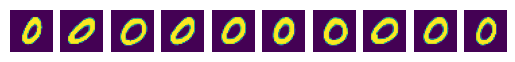

Lambda:  0.9999 | Embedding Dim:  10
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6673 | Reconstruction Loss: 0.6543 | KLD Loss: 130.1528
Epoch 50 | Total Loss: 0.4703 | Reconstruction Loss: 0.4671 | KLD Loss: 33.1909
Epoch 100 | Total Loss: 0.4678 | Reconstruction Loss: 0.4646 | KLD Loss: 32.6004
Epoch 150 | Total Loss: 0.4663 | Reconstruction Loss: 0.4631 | KLD Loss: 32.2376
Epoch 200 | Total Loss: 0.4655 | Reconstruction Loss: 0.4623 | KLD Loss: 32.1305
Epoch 250 | Total Loss: 0.4648 | Reconstruction Loss: 0.4616 | KLD Loss: 32.1023
Epoch 299 | Total Loss: 0.4643 | Reconstruction Loss: 0.4611 | KLD Loss: 31.9740


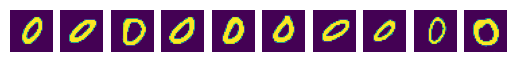

Lambda:  0.9999 | Embedding Dim:  100
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6482 | Reconstruction Loss: 0.6301 | KLD Loss: 181.3993
Epoch 50 | Total Loss: 0.4636 | Reconstruction Loss: 0.4558 | KLD Loss: 78.1009
Epoch 100 | Total Loss: 0.4603 | Reconstruction Loss: 0.4529 | KLD Loss: 74.5007
Epoch 150 | Total Loss: 0.4589 | Reconstruction Loss: 0.4516 | KLD Loss: 73.2959
Epoch 200 | Total Loss: 0.4579 | Reconstruction Loss: 0.4507 | KLD Loss: 72.2515
Epoch 250 | Total Loss: 0.4572 | Reconstruction Loss: 0.4501 | KLD Loss: 71.1632
Epoch 299 | Total Loss: 0.4568 | Reconstruction Loss: 0.4497 | KLD Loss: 71.3812


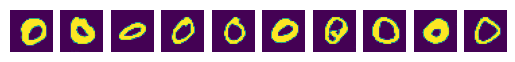

Lambda:  0.9999 | Embedding Dim:  1000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6804 | Reconstruction Loss: 0.6492 | KLD Loss: 312.7352
Epoch 50 | Total Loss: 0.4704 | Reconstruction Loss: 0.4608 | KLD Loss: 96.2958
Epoch 100 | Total Loss: 0.4644 | Reconstruction Loss: 0.4560 | KLD Loss: 83.6752
Epoch 150 | Total Loss: 0.4619 | Reconstruction Loss: 0.4541 | KLD Loss: 78.9808
Epoch 200 | Total Loss: 0.4605 | Reconstruction Loss: 0.4529 | KLD Loss: 76.4577
Epoch 250 | Total Loss: 0.4596 | Reconstruction Loss: 0.4521 | KLD Loss: 75.1641
Epoch 299 | Total Loss: 0.4589 | Reconstruction Loss: 0.4516 | KLD Loss: 73.9375


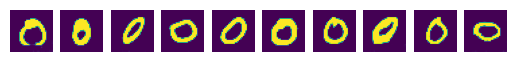

Lambda:  0.9999 | Embedding Dim:  2000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6710 | Reconstruction Loss: 0.6392 | KLD Loss: 318.2736
Epoch 50 | Total Loss: 0.4796 | Reconstruction Loss: 0.4674 | KLD Loss: 122.9900
Epoch 100 | Total Loss: 0.4719 | Reconstruction Loss: 0.4613 | KLD Loss: 106.4318
Epoch 150 | Total Loss: 0.4667 | Reconstruction Loss: 0.4577 | KLD Loss: 91.1515
Epoch 200 | Total Loss: 0.4640 | Reconstruction Loss: 0.4557 | KLD Loss: 83.0092
Epoch 250 | Total Loss: 0.4623 | Reconstruction Loss: 0.4544 | KLD Loss: 78.8282
Epoch 299 | Total Loss: 0.4611 | Reconstruction Loss: 0.4535 | KLD Loss: 75.8834


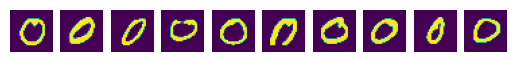

Lambda:  0.9999 | Embedding Dim:  4000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.7084 | Reconstruction Loss: 0.6587 | KLD Loss: 497.4374
Epoch 100 | Total Loss: 0.4776 | Reconstruction Loss: 0.4652 | KLD Loss: 124.4079
Epoch 150 | Total Loss: 0.4756 | Reconstruction Loss: 0.4635 | KLD Loss: 122.2020
Epoch 200 | Total Loss: 0.4741 | Reconstruction Loss: 0.4622 | KLD Loss: 119.8490
Epoch 250 | Total Loss: 0.4732 | Reconstruction Loss: 0.4613 | KLD Loss: 119.4478
Epoch 299 | Total Loss: 0.4725 | Reconstruction Loss: 0.4607 | KLD Loss: 118.3526


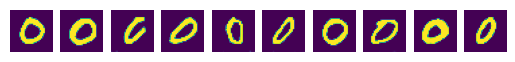

Classe:  1 

Lambda:  0.9 | Embedding Dim:  2
---------------------------------------------------------
Epoch 0 | Total Loss: 0.4561 | Reconstruction Loss: 0.4843 | KLD Loss: 0.2028
Epoch 50 | Total Loss: 0.3324 | Reconstruction Loss: 0.3693 | KLD Loss: 0.0003
Epoch 100 | Total Loss: 0.3322 | Reconstruction Loss: 0.3691 | KLD Loss: 0.0000
Epoch 150 | Total Loss: 0.3321 | Reconstruction Loss: 0.3690 | KLD Loss: 0.0000
Epoch 200 | Total Loss: 0.3321 | Reconstruction Loss: 0.3690 | KLD Loss: 0.0000
Epoch 250 | Total Loss: 0.3321 | Reconstruction Loss: 0.3690 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.3321 | Reconstruction Loss: 0.3690 | KLD Loss: 0.0000


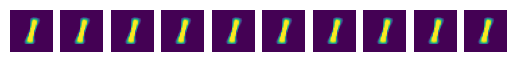

Lambda:  0.9 | Embedding Dim:  10
---------------------------------------------------------
Epoch 0 | Total Loss: 0.4954 | Reconstruction Loss: 0.4938 | KLD Loss: 0.5105
Epoch 50 | Total Loss: 0.3324 | Reconstruction Loss: 0.3693 | KLD Loss: 0.0002
Epoch 100 | Total Loss: 0.3322 | Reconstruction Loss: 0.3691 | KLD Loss: 0.0000
Epoch 150 | Total Loss: 0.3322 | Reconstruction Loss: 0.3691 | KLD Loss: 0.0000
Epoch 200 | Total Loss: 0.3322 | Reconstruction Loss: 0.3691 | KLD Loss: 0.0000
Epoch 250 | Total Loss: 0.3321 | Reconstruction Loss: 0.3690 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.3321 | Reconstruction Loss: 0.3690 | KLD Loss: 0.0000


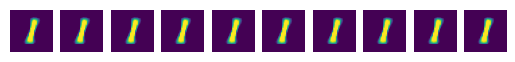

Lambda:  0.9 | Embedding Dim:  100
---------------------------------------------------------
Epoch 0 | Total Loss: 0.8397 | Reconstruction Loss: 0.5424 | KLD Loss: 3.5156
Epoch 50 | Total Loss: 0.3325 | Reconstruction Loss: 0.3694 | KLD Loss: 0.0002
Epoch 100 | Total Loss: 0.3323 | Reconstruction Loss: 0.3692 | KLD Loss: 0.0000
Epoch 150 | Total Loss: 0.3322 | Reconstruction Loss: 0.3691 | KLD Loss: 0.0000
Epoch 200 | Total Loss: 0.3322 | Reconstruction Loss: 0.3691 | KLD Loss: 0.0000
Epoch 250 | Total Loss: 0.3321 | Reconstruction Loss: 0.3690 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.3321 | Reconstruction Loss: 0.3690 | KLD Loss: 0.0000


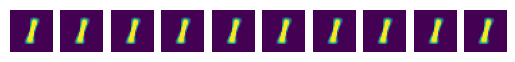

Lambda:  0.9 | Embedding Dim:  1000
---------------------------------------------------------
Epoch 0 | Total Loss: 3.3482 | Reconstruction Loss: 0.5595 | KLD Loss: 28.4460
Epoch 50 | Total Loss: 0.3327 | Reconstruction Loss: 0.3696 | KLD Loss: 0.0002
Epoch 100 | Total Loss: 0.3324 | Reconstruction Loss: 0.3693 | KLD Loss: 0.0000
Epoch 150 | Total Loss: 0.3323 | Reconstruction Loss: 0.3692 | KLD Loss: 0.0000
Epoch 200 | Total Loss: 0.3322 | Reconstruction Loss: 0.3692 | KLD Loss: 0.0000
Epoch 250 | Total Loss: 0.3322 | Reconstruction Loss: 0.3691 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.3322 | Reconstruction Loss: 0.3691 | KLD Loss: 0.0000


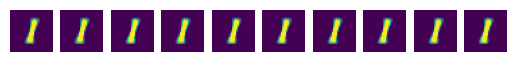

Lambda:  0.9 | Embedding Dim:  2000
---------------------------------------------------------
Epoch 0 | Total Loss: 6.1111 | Reconstruction Loss: 0.5561 | KLD Loss: 56.1059
Epoch 50 | Total Loss: 0.3331 | Reconstruction Loss: 0.3700 | KLD Loss: 0.0009
Epoch 100 | Total Loss: 0.3325 | Reconstruction Loss: 0.3694 | KLD Loss: 0.0001
Epoch 150 | Total Loss: 0.3323 | Reconstruction Loss: 0.3692 | KLD Loss: 0.0000
Epoch 200 | Total Loss: 0.3322 | Reconstruction Loss: 0.3692 | KLD Loss: 0.0000
Epoch 250 | Total Loss: 0.3322 | Reconstruction Loss: 0.3691 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.3322 | Reconstruction Loss: 0.3691 | KLD Loss: 0.0000


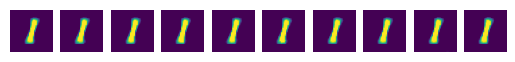

Lambda:  0.9 | Embedding Dim:  4000
---------------------------------------------------------
Epoch 0 | Total Loss: 11.8422 | Reconstruction Loss: 0.5620 | KLD Loss: 113.3648
Epoch 50 | Total Loss: 0.3339 | Reconstruction Loss: 0.3709 | KLD Loss: 0.0006
Epoch 100 | Total Loss: 0.3327 | Reconstruction Loss: 0.3697 | KLD Loss: 0.0001
Epoch 150 | Total Loss: 0.3324 | Reconstruction Loss: 0.3694 | KLD Loss: 0.0001
Epoch 200 | Total Loss: 0.3324 | Reconstruction Loss: 0.3693 | KLD Loss: 0.0001
Epoch 250 | Total Loss: 0.3323 | Reconstruction Loss: 0.3692 | KLD Loss: 0.0001
Epoch 299 | Total Loss: 0.3323 | Reconstruction Loss: 0.3692 | KLD Loss: 0.0001


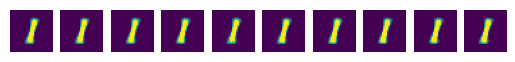

Lambda:  0.99 | Embedding Dim:  2
---------------------------------------------------------
Epoch 0 | Total Loss: 0.4756 | Reconstruction Loss: 0.4567 | KLD Loss: 2.3522
Epoch 50 | Total Loss: 0.3221 | Reconstruction Loss: 0.3064 | KLD Loss: 1.8768
Epoch 100 | Total Loss: 0.3220 | Reconstruction Loss: 0.3061 | KLD Loss: 1.8962
Epoch 150 | Total Loss: 0.3217 | Reconstruction Loss: 0.3057 | KLD Loss: 1.9023
Epoch 200 | Total Loss: 0.3215 | Reconstruction Loss: 0.3056 | KLD Loss: 1.8873
Epoch 250 | Total Loss: 0.3211 | Reconstruction Loss: 0.3050 | KLD Loss: 1.9115
Epoch 299 | Total Loss: 0.3213 | Reconstruction Loss: 0.3051 | KLD Loss: 1.9300


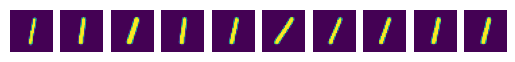

Lambda:  0.99 | Embedding Dim:  10
---------------------------------------------------------
Epoch 0 | Total Loss: 0.5018 | Reconstruction Loss: 0.4840 | KLD Loss: 2.2553
Epoch 50 | Total Loss: 0.3225 | Reconstruction Loss: 0.3062 | KLD Loss: 1.9413
Epoch 100 | Total Loss: 0.3219 | Reconstruction Loss: 0.3054 | KLD Loss: 1.9586
Epoch 150 | Total Loss: 0.3218 | Reconstruction Loss: 0.3048 | KLD Loss: 2.0012
Epoch 200 | Total Loss: 0.3215 | Reconstruction Loss: 0.3045 | KLD Loss: 2.0073
Epoch 250 | Total Loss: 0.3215 | Reconstruction Loss: 0.3047 | KLD Loss: 1.9900
Epoch 299 | Total Loss: 0.3212 | Reconstruction Loss: 0.3043 | KLD Loss: 1.9866


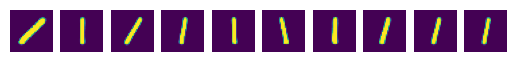

Lambda:  0.99 | Embedding Dim:  100
---------------------------------------------------------
Epoch 0 | Total Loss: 0.5585 | Reconstruction Loss: 0.5106 | KLD Loss: 5.2991
Epoch 50 | Total Loss: 0.3231 | Reconstruction Loss: 0.3071 | KLD Loss: 1.9160
Epoch 100 | Total Loss: 0.3225 | Reconstruction Loss: 0.3061 | KLD Loss: 1.9460
Epoch 150 | Total Loss: 0.3222 | Reconstruction Loss: 0.3058 | KLD Loss: 1.9479
Epoch 200 | Total Loss: 0.3222 | Reconstruction Loss: 0.3058 | KLD Loss: 1.9458
Epoch 250 | Total Loss: 0.3214 | Reconstruction Loss: 0.3051 | KLD Loss: 1.9370
Epoch 299 | Total Loss: 0.3217 | Reconstruction Loss: 0.3052 | KLD Loss: 1.9508


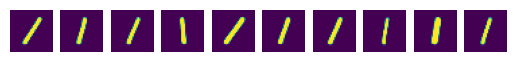

Lambda:  0.99 | Embedding Dim:  1000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.7914 | Reconstruction Loss: 0.4999 | KLD Loss: 29.6548
Epoch 50 | Total Loss: 0.3405 | Reconstruction Loss: 0.3267 | KLD Loss: 1.7149
Epoch 100 | Total Loss: 0.3393 | Reconstruction Loss: 0.3247 | KLD Loss: 1.7848
Epoch 150 | Total Loss: 0.3386 | Reconstruction Loss: 0.3240 | KLD Loss: 1.7791
Epoch 200 | Total Loss: 0.3381 | Reconstruction Loss: 0.3233 | KLD Loss: 1.8033
Epoch 250 | Total Loss: 0.3385 | Reconstruction Loss: 0.3233 | KLD Loss: 1.8431
Epoch 299 | Total Loss: 0.3387 | Reconstruction Loss: 0.3243 | KLD Loss: 1.7719


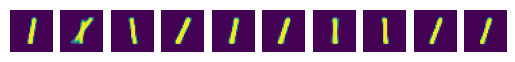

Lambda:  0.99 | Embedding Dim:  2000
---------------------------------------------------------
Epoch 0 | Total Loss: 1.0620 | Reconstruction Loss: 0.5027 | KLD Loss: 56.4357
Epoch 50 | Total Loss: 0.3418 | Reconstruction Loss: 0.3277 | KLD Loss: 1.7360
Epoch 100 | Total Loss: 0.3400 | Reconstruction Loss: 0.3263 | KLD Loss: 1.7012
Epoch 150 | Total Loss: 0.3393 | Reconstruction Loss: 0.3250 | KLD Loss: 1.7572
Epoch 200 | Total Loss: 0.3397 | Reconstruction Loss: 0.3250 | KLD Loss: 1.7853
Epoch 250 | Total Loss: 0.3385 | Reconstruction Loss: 0.3244 | KLD Loss: 1.7350
Epoch 299 | Total Loss: 0.3387 | Reconstruction Loss: 0.3237 | KLD Loss: 1.8214


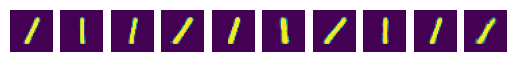

Lambda:  0.99 | Embedding Dim:  4000
---------------------------------------------------------
Epoch 0 | Total Loss: 1.5795 | Reconstruction Loss: 0.4979 | KLD Loss: 108.6620
Epoch 50 | Total Loss: 0.3433 | Reconstruction Loss: 0.3296 | KLD Loss: 1.7057
Epoch 100 | Total Loss: 0.3412 | Reconstruction Loss: 0.3272 | KLD Loss: 1.7276
Epoch 150 | Total Loss: 0.3412 | Reconstruction Loss: 0.3271 | KLD Loss: 1.7353
Epoch 200 | Total Loss: 0.3402 | Reconstruction Loss: 0.3264 | KLD Loss: 1.7112
Epoch 250 | Total Loss: 0.3401 | Reconstruction Loss: 0.3261 | KLD Loss: 1.7312
Epoch 299 | Total Loss: 0.3394 | Reconstruction Loss: 0.3252 | KLD Loss: 1.7411


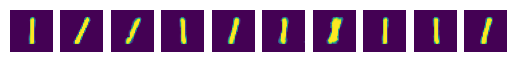

Lambda:  0.999 | Embedding Dim:  2
---------------------------------------------------------
Epoch 0 | Total Loss: 0.4124 | Reconstruction Loss: 0.3988 | KLD Loss: 13.9908
Epoch 50 | Total Loss: 0.2985 | Reconstruction Loss: 0.2940 | KLD Loss: 4.7593
Epoch 100 | Total Loss: 0.2974 | Reconstruction Loss: 0.2927 | KLD Loss: 4.9732
Epoch 150 | Total Loss: 0.2965 | Reconstruction Loss: 0.2917 | KLD Loss: 5.0926
Epoch 200 | Total Loss: 0.2959 | Reconstruction Loss: 0.2909 | KLD Loss: 5.2577
Epoch 250 | Total Loss: 0.2954 | Reconstruction Loss: 0.2904 | KLD Loss: 5.3014
Epoch 299 | Total Loss: 0.2951 | Reconstruction Loss: 0.2900 | KLD Loss: 5.3470


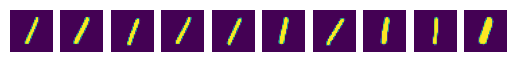

Lambda:  0.999 | Embedding Dim:  10
---------------------------------------------------------
Epoch 0 | Total Loss: 0.4120 | Reconstruction Loss: 0.3957 | KLD Loss: 16.6477
Epoch 50 | Total Loss: 0.2878 | Reconstruction Loss: 0.2781 | KLD Loss: 9.9989
Epoch 100 | Total Loss: 0.2868 | Reconstruction Loss: 0.2773 | KLD Loss: 9.8510
Epoch 150 | Total Loss: 0.2864 | Reconstruction Loss: 0.2768 | KLD Loss: 9.8651
Epoch 200 | Total Loss: 0.2861 | Reconstruction Loss: 0.2765 | KLD Loss: 9.8686
Epoch 250 | Total Loss: 0.2858 | Reconstruction Loss: 0.2763 | KLD Loss: 9.7952
Epoch 299 | Total Loss: 0.2857 | Reconstruction Loss: 0.2762 | KLD Loss: 9.7721


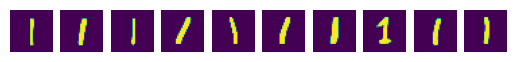

Lambda:  0.999 | Embedding Dim:  100
---------------------------------------------------------
Epoch 0 | Total Loss: 0.4667 | Reconstruction Loss: 0.4456 | KLD Loss: 21.6016
Epoch 50 | Total Loss: 0.2891 | Reconstruction Loss: 0.2793 | KLD Loss: 10.0798
Epoch 100 | Total Loss: 0.2880 | Reconstruction Loss: 0.2781 | KLD Loss: 10.1422
Epoch 150 | Total Loss: 0.2872 | Reconstruction Loss: 0.2775 | KLD Loss: 9.9761
Epoch 200 | Total Loss: 0.2867 | Reconstruction Loss: 0.2770 | KLD Loss: 10.0320
Epoch 250 | Total Loss: 0.2865 | Reconstruction Loss: 0.2768 | KLD Loss: 9.9745
Epoch 299 | Total Loss: 0.2862 | Reconstruction Loss: 0.2765 | KLD Loss: 9.9690


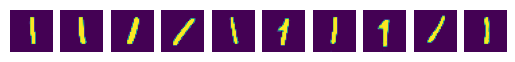

Lambda:  0.999 | Embedding Dim:  1000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.5101 | Reconstruction Loss: 0.4611 | KLD Loss: 49.4612
Epoch 50 | Total Loss: 0.3036 | Reconstruction Loss: 0.2906 | KLD Loss: 13.3358
Epoch 100 | Total Loss: 0.3006 | Reconstruction Loss: 0.2882 | KLD Loss: 12.6871
Epoch 150 | Total Loss: 0.2959 | Reconstruction Loss: 0.2851 | KLD Loss: 11.0780
Epoch 200 | Total Loss: 0.2913 | Reconstruction Loss: 0.2813 | KLD Loss: 10.2357
Epoch 250 | Total Loss: 0.2904 | Reconstruction Loss: 0.2806 | KLD Loss: 10.0585
Epoch 299 | Total Loss: 0.2896 | Reconstruction Loss: 0.2800 | KLD Loss: 9.8917


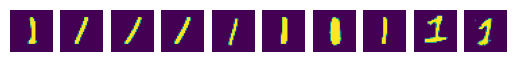

Lambda:  0.999 | Embedding Dim:  2000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.5165 | Reconstruction Loss: 0.4350 | KLD Loss: 81.9429
Epoch 50 | Total Loss: 0.3050 | Reconstruction Loss: 0.2918 | KLD Loss: 13.4882
Epoch 100 | Total Loss: 0.3028 | Reconstruction Loss: 0.2895 | KLD Loss: 13.5460
Epoch 150 | Total Loss: 0.3020 | Reconstruction Loss: 0.2887 | KLD Loss: 13.6264
Epoch 200 | Total Loss: 0.3012 | Reconstruction Loss: 0.2880 | KLD Loss: 13.5235
Epoch 250 | Total Loss: 0.2987 | Reconstruction Loss: 0.2867 | KLD Loss: 12.3398
Epoch 299 | Total Loss: 0.2973 | Reconstruction Loss: 0.2859 | KLD Loss: 11.7101


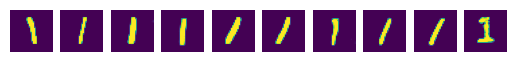

Lambda:  0.999 | Embedding Dim:  4000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.5761 | Reconstruction Loss: 0.4227 | KLD Loss: 153.8372
Epoch 50 | Total Loss: 0.3061 | Reconstruction Loss: 0.2924 | KLD Loss: 13.9932
Epoch 100 | Total Loss: 0.3043 | Reconstruction Loss: 0.2902 | KLD Loss: 14.4133
Epoch 150 | Total Loss: 0.3031 | Reconstruction Loss: 0.2895 | KLD Loss: 13.8787
Epoch 200 | Total Loss: 0.3023 | Reconstruction Loss: 0.2889 | KLD Loss: 13.7126
Epoch 250 | Total Loss: 0.3017 | Reconstruction Loss: 0.2884 | KLD Loss: 13.5046
Epoch 299 | Total Loss: 0.3016 | Reconstruction Loss: 0.2881 | KLD Loss: 13.8102


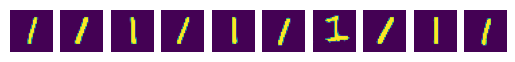

Lambda:  0.9999 | Embedding Dim:  2
---------------------------------------------------------
Epoch 0 | Total Loss: 0.4135 | Reconstruction Loss: 0.4053 | KLD Loss: 82.4210
Epoch 50 | Total Loss: 0.2942 | Reconstruction Loss: 0.2934 | KLD Loss: 8.1755
Epoch 100 | Total Loss: 0.2925 | Reconstruction Loss: 0.2917 | KLD Loss: 8.5090
Epoch 150 | Total Loss: 0.2917 | Reconstruction Loss: 0.2908 | KLD Loss: 8.7647
Epoch 200 | Total Loss: 0.2908 | Reconstruction Loss: 0.2899 | KLD Loss: 9.0302
Epoch 250 | Total Loss: 0.2901 | Reconstruction Loss: 0.2892 | KLD Loss: 9.2014
Epoch 299 | Total Loss: 0.2898 | Reconstruction Loss: 0.2889 | KLD Loss: 9.2608


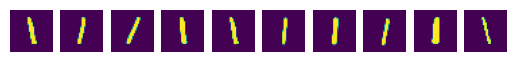

Lambda:  0.9999 | Embedding Dim:  10
---------------------------------------------------------
Epoch 0 | Total Loss: 0.3818 | Reconstruction Loss: 0.3729 | KLD Loss: 89.3189
Epoch 50 | Total Loss: 0.2753 | Reconstruction Loss: 0.2729 | KLD Loss: 24.3718
Epoch 100 | Total Loss: 0.2745 | Reconstruction Loss: 0.2721 | KLD Loss: 23.9377
Epoch 150 | Total Loss: 0.2739 | Reconstruction Loss: 0.2716 | KLD Loss: 23.7657
Epoch 200 | Total Loss: 0.2737 | Reconstruction Loss: 0.2713 | KLD Loss: 23.6242
Epoch 250 | Total Loss: 0.2734 | Reconstruction Loss: 0.2711 | KLD Loss: 23.4753
Epoch 299 | Total Loss: 0.2732 | Reconstruction Loss: 0.2709 | KLD Loss: 23.6047


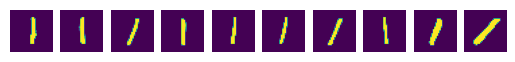

Lambda:  0.9999 | Embedding Dim:  100
---------------------------------------------------------
Epoch 0 | Total Loss: 0.3865 | Reconstruction Loss: 0.3730 | KLD Loss: 136.2516
Epoch 50 | Total Loss: 0.2755 | Reconstruction Loss: 0.2723 | KLD Loss: 32.3729
Epoch 100 | Total Loss: 0.2743 | Reconstruction Loss: 0.2712 | KLD Loss: 31.4375
Epoch 150 | Total Loss: 0.2738 | Reconstruction Loss: 0.2707 | KLD Loss: 30.9153
Epoch 200 | Total Loss: 0.2734 | Reconstruction Loss: 0.2704 | KLD Loss: 30.4404
Epoch 250 | Total Loss: 0.2732 | Reconstruction Loss: 0.2702 | KLD Loss: 30.2333
Epoch 299 | Total Loss: 0.2730 | Reconstruction Loss: 0.2700 | KLD Loss: 30.1879


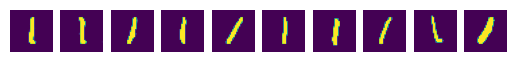

Lambda:  0.9999 | Embedding Dim:  1000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.3918 | Reconstruction Loss: 0.3747 | KLD Loss: 171.1570
Epoch 50 | Total Loss: 0.2788 | Reconstruction Loss: 0.2747 | KLD Loss: 41.8484
Epoch 100 | Total Loss: 0.2762 | Reconstruction Loss: 0.2727 | KLD Loss: 35.2399
Epoch 150 | Total Loss: 0.2752 | Reconstruction Loss: 0.2719 | KLD Loss: 33.5269
Epoch 200 | Total Loss: 0.2746 | Reconstruction Loss: 0.2714 | KLD Loss: 32.2880
Epoch 250 | Total Loss: 0.2743 | Reconstruction Loss: 0.2711 | KLD Loss: 31.9667
Epoch 299 | Total Loss: 0.2741 | Reconstruction Loss: 0.2710 | KLD Loss: 31.8064


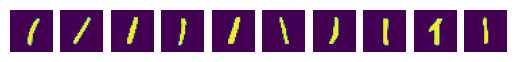

Lambda:  0.9999 | Embedding Dim:  2000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.3762 | Reconstruction Loss: 0.3581 | KLD Loss: 180.8167
Epoch 50 | Total Loss: 0.2827 | Reconstruction Loss: 0.2771 | KLD Loss: 55.9523
Epoch 100 | Total Loss: 0.2810 | Reconstruction Loss: 0.2755 | KLD Loss: 55.1085
Epoch 150 | Total Loss: 0.2798 | Reconstruction Loss: 0.2746 | KLD Loss: 52.6538
Epoch 200 | Total Loss: 0.2786 | Reconstruction Loss: 0.2738 | KLD Loss: 48.7303
Epoch 250 | Total Loss: 0.2776 | Reconstruction Loss: 0.2732 | KLD Loss: 44.8105
Epoch 299 | Total Loss: 0.2769 | Reconstruction Loss: 0.2728 | KLD Loss: 41.9260


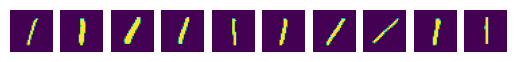

Lambda:  0.9999 | Embedding Dim:  4000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.4016 | Reconstruction Loss: 0.3730 | KLD Loss: 286.3857
Epoch 50 | Total Loss: 0.2833 | Reconstruction Loss: 0.2776 | KLD Loss: 57.7138
Epoch 100 | Total Loss: 0.2816 | Reconstruction Loss: 0.2759 | KLD Loss: 56.8454
Epoch 150 | Total Loss: 0.2806 | Reconstruction Loss: 0.2751 | KLD Loss: 55.4586
Epoch 200 | Total Loss: 0.2802 | Reconstruction Loss: 0.2748 | KLD Loss: 55.0437
Epoch 250 | Total Loss: 0.2799 | Reconstruction Loss: 0.2745 | KLD Loss: 54.9868
Epoch 299 | Total Loss: 0.2796 | Reconstruction Loss: 0.2743 | KLD Loss: 53.6194


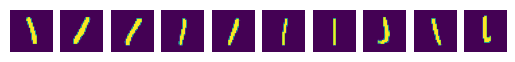

Classe:  2 

Lambda:  0.9 | Embedding Dim:  2
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6709 | Reconstruction Loss: 0.7205 | KLD Loss: 0.2246
Epoch 50 | Total Loss: 0.5552 | Reconstruction Loss: 0.6168 | KLD Loss: 0.0005
Epoch 100 | Total Loss: 0.5550 | Reconstruction Loss: 0.6166 | KLD Loss: 0.0000
Epoch 150 | Total Loss: 0.5549 | Reconstruction Loss: 0.6165 | KLD Loss: 0.0000
Epoch 200 | Total Loss: 0.5548 | Reconstruction Loss: 0.6165 | KLD Loss: 0.0000
Epoch 250 | Total Loss: 0.5548 | Reconstruction Loss: 0.6164 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.5548 | Reconstruction Loss: 0.6164 | KLD Loss: 0.0000


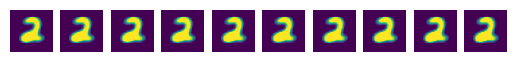

Lambda:  0.9 | Embedding Dim:  10
---------------------------------------------------------
Epoch 0 | Total Loss: 0.7514 | Reconstruction Loss: 0.7548 | KLD Loss: 0.7208
Epoch 50 | Total Loss: 0.5552 | Reconstruction Loss: 0.6168 | KLD Loss: 0.0006
Epoch 100 | Total Loss: 0.5550 | Reconstruction Loss: 0.6167 | KLD Loss: 0.0000
Epoch 150 | Total Loss: 0.5549 | Reconstruction Loss: 0.6165 | KLD Loss: 0.0000
Epoch 200 | Total Loss: 0.5548 | Reconstruction Loss: 0.6165 | KLD Loss: 0.0000
Epoch 250 | Total Loss: 0.5548 | Reconstruction Loss: 0.6164 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.5548 | Reconstruction Loss: 0.6164 | KLD Loss: 0.0000


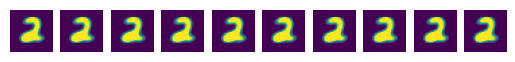

Lambda:  0.9 | Embedding Dim:  100
---------------------------------------------------------
Epoch 0 | Total Loss: 1.2612 | Reconstruction Loss: 0.8496 | KLD Loss: 4.9661
Epoch 50 | Total Loss: 0.5553 | Reconstruction Loss: 0.6170 | KLD Loss: 0.0004
Epoch 100 | Total Loss: 0.5551 | Reconstruction Loss: 0.6167 | KLD Loss: 0.0000
Epoch 150 | Total Loss: 0.5550 | Reconstruction Loss: 0.6166 | KLD Loss: 0.0000
Epoch 200 | Total Loss: 0.5549 | Reconstruction Loss: 0.6165 | KLD Loss: 0.0000
Epoch 250 | Total Loss: 0.5549 | Reconstruction Loss: 0.6165 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.5549 | Reconstruction Loss: 0.6165 | KLD Loss: 0.0000


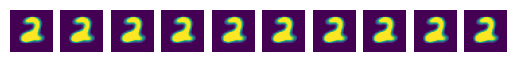

Lambda:  0.9 | Embedding Dim:  1000
---------------------------------------------------------
Epoch 0 | Total Loss: 4.8447 | Reconstruction Loss: 0.8561 | KLD Loss: 40.7415
Epoch 50 | Total Loss: 0.5557 | Reconstruction Loss: 0.6174 | KLD Loss: 0.0004
Epoch 100 | Total Loss: 0.5553 | Reconstruction Loss: 0.6170 | KLD Loss: 0.0000
Epoch 150 | Total Loss: 0.5551 | Reconstruction Loss: 0.6168 | KLD Loss: 0.0002
Epoch 200 | Total Loss: 0.5550 | Reconstruction Loss: 0.6166 | KLD Loss: 0.0000
Epoch 250 | Total Loss: 0.5549 | Reconstruction Loss: 0.6166 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.5549 | Reconstruction Loss: 0.6165 | KLD Loss: 0.0000


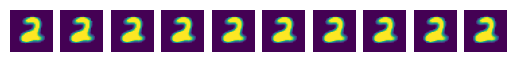

Lambda:  0.9 | Embedding Dim:  2000
---------------------------------------------------------
Epoch 0 | Total Loss: 9.0428 | Reconstruction Loss: 0.8496 | KLD Loss: 82.7821
Epoch 50 | Total Loss: 0.5562 | Reconstruction Loss: 0.6178 | KLD Loss: 0.0015
Epoch 100 | Total Loss: 0.5553 | Reconstruction Loss: 0.6170 | KLD Loss: 0.0000
Epoch 150 | Total Loss: 0.5551 | Reconstruction Loss: 0.6168 | KLD Loss: 0.0000
Epoch 200 | Total Loss: 0.5551 | Reconstruction Loss: 0.6167 | KLD Loss: 0.0000
Epoch 250 | Total Loss: 0.5550 | Reconstruction Loss: 0.6167 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.5550 | Reconstruction Loss: 0.6167 | KLD Loss: 0.0000


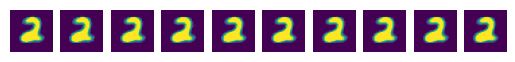

Lambda:  0.9 | Embedding Dim:  4000
---------------------------------------------------------
Epoch 0 | Total Loss: 16.3878 | Reconstruction Loss: 0.8864 | KLD Loss: 155.9009
Epoch 50 | Total Loss: 0.5568 | Reconstruction Loss: 0.6185 | KLD Loss: 0.0011
Epoch 100 | Total Loss: 0.5557 | Reconstruction Loss: 0.6174 | KLD Loss: 0.0001
Epoch 150 | Total Loss: 0.5554 | Reconstruction Loss: 0.6171 | KLD Loss: 0.0001
Epoch 200 | Total Loss: 0.5553 | Reconstruction Loss: 0.6170 | KLD Loss: 0.0001
Epoch 250 | Total Loss: 0.5552 | Reconstruction Loss: 0.6168 | KLD Loss: 0.0001
Epoch 299 | Total Loss: 0.5551 | Reconstruction Loss: 0.6168 | KLD Loss: 0.0001


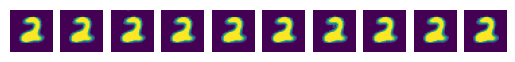

Lambda:  0.99 | Embedding Dim:  2
---------------------------------------------------------
Epoch 0 | Total Loss: 0.7206 | Reconstruction Loss: 0.7056 | KLD Loss: 2.2034
Epoch 50 | Total Loss: 0.5660 | Reconstruction Loss: 0.5472 | KLD Loss: 2.4304
Epoch 100 | Total Loss: 0.5644 | Reconstruction Loss: 0.5450 | KLD Loss: 2.4894
Epoch 150 | Total Loss: 0.5636 | Reconstruction Loss: 0.5432 | KLD Loss: 2.5811
Epoch 200 | Total Loss: 0.5623 | Reconstruction Loss: 0.5411 | KLD Loss: 2.6559
Epoch 250 | Total Loss: 0.5614 | Reconstruction Loss: 0.5397 | KLD Loss: 2.7078
Epoch 299 | Total Loss: 0.5612 | Reconstruction Loss: 0.5384 | KLD Loss: 2.8247


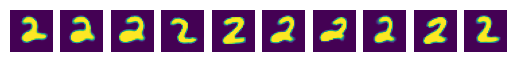

Lambda:  0.99 | Embedding Dim:  10
---------------------------------------------------------
Epoch 0 | Total Loss: 0.7817 | Reconstruction Loss: 0.7674 | KLD Loss: 2.2038
Epoch 50 | Total Loss: 0.5474 | Reconstruction Loss: 0.5006 | KLD Loss: 5.1776
Epoch 100 | Total Loss: 0.5465 | Reconstruction Loss: 0.4975 | KLD Loss: 5.4007
Epoch 150 | Total Loss: 0.5451 | Reconstruction Loss: 0.4959 | KLD Loss: 5.4187
Epoch 200 | Total Loss: 0.5448 | Reconstruction Loss: 0.4946 | KLD Loss: 5.5095
Epoch 250 | Total Loss: 0.5434 | Reconstruction Loss: 0.4930 | KLD Loss: 5.5345
Epoch 299 | Total Loss: 0.5433 | Reconstruction Loss: 0.4925 | KLD Loss: 5.5675


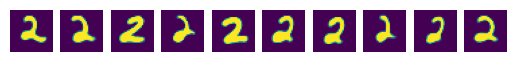

Lambda:  0.99 | Embedding Dim:  100
---------------------------------------------------------
Epoch 0 | Total Loss: 0.8420 | Reconstruction Loss: 0.7819 | KLD Loss: 6.7930
Epoch 50 | Total Loss: 0.5513 | Reconstruction Loss: 0.5082 | KLD Loss: 4.8207
Epoch 100 | Total Loss: 0.5487 | Reconstruction Loss: 0.5022 | KLD Loss: 5.1521
Epoch 150 | Total Loss: 0.5471 | Reconstruction Loss: 0.4998 | KLD Loss: 5.2321
Epoch 200 | Total Loss: 0.5459 | Reconstruction Loss: 0.4976 | KLD Loss: 5.3285
Epoch 250 | Total Loss: 0.5454 | Reconstruction Loss: 0.4963 | KLD Loss: 5.4061
Epoch 299 | Total Loss: 0.5449 | Reconstruction Loss: 0.4952 | KLD Loss: 5.4635


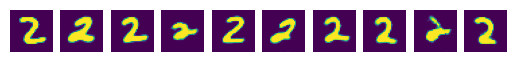

Lambda:  0.99 | Embedding Dim:  1000
---------------------------------------------------------
Epoch 0 | Total Loss: 1.2376 | Reconstruction Loss: 0.8156 | KLD Loss: 43.0194
Epoch 50 | Total Loss: 0.5819 | Reconstruction Loss: 0.5541 | KLD Loss: 3.3358
Epoch 100 | Total Loss: 0.5795 | Reconstruction Loss: 0.5508 | KLD Loss: 3.4201
Epoch 150 | Total Loss: 0.5785 | Reconstruction Loss: 0.5490 | KLD Loss: 3.5017
Epoch 200 | Total Loss: 0.5779 | Reconstruction Loss: 0.5483 | KLD Loss: 3.5102
Epoch 250 | Total Loss: 0.5762 | Reconstruction Loss: 0.5468 | KLD Loss: 3.4866
Epoch 299 | Total Loss: 0.5766 | Reconstruction Loss: 0.5472 | KLD Loss: 3.4885


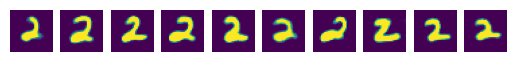

Lambda:  0.99 | Embedding Dim:  2000
---------------------------------------------------------
Epoch 0 | Total Loss: 1.6090 | Reconstruction Loss: 0.7958 | KLD Loss: 82.1133
Epoch 50 | Total Loss: 0.5838 | Reconstruction Loss: 0.5563 | KLD Loss: 3.3043
Epoch 100 | Total Loss: 0.5813 | Reconstruction Loss: 0.5528 | KLD Loss: 3.3967
Epoch 150 | Total Loss: 0.5801 | Reconstruction Loss: 0.5515 | KLD Loss: 3.4124
Epoch 200 | Total Loss: 0.5791 | Reconstruction Loss: 0.5504 | KLD Loss: 3.4206
Epoch 250 | Total Loss: 0.5772 | Reconstruction Loss: 0.5487 | KLD Loss: 3.3968
Epoch 299 | Total Loss: 0.5790 | Reconstruction Loss: 0.5499 | KLD Loss: 3.4602


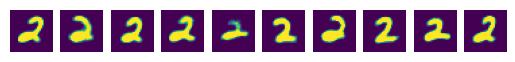

Lambda:  0.99 | Embedding Dim:  4000
---------------------------------------------------------
Epoch 0 | Total Loss: 2.3768 | Reconstruction Loss: 0.7823 | KLD Loss: 160.2295
Epoch 50 | Total Loss: 0.5851 | Reconstruction Loss: 0.5587 | KLD Loss: 3.1999
Epoch 100 | Total Loss: 0.5828 | Reconstruction Loss: 0.5556 | KLD Loss: 3.2730
Epoch 150 | Total Loss: 0.5808 | Reconstruction Loss: 0.5534 | KLD Loss: 3.2900
Epoch 200 | Total Loss: 0.5804 | Reconstruction Loss: 0.5524 | KLD Loss: 3.3456
Epoch 250 | Total Loss: 0.5798 | Reconstruction Loss: 0.5516 | KLD Loss: 3.3678
Epoch 299 | Total Loss: 0.5791 | Reconstruction Loss: 0.5510 | KLD Loss: 3.3633


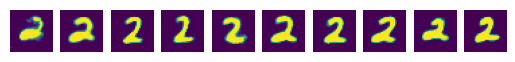

Lambda:  0.999 | Embedding Dim:  2
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6778 | Reconstruction Loss: 0.6632 | KLD Loss: 15.2390
Epoch 50 | Total Loss: 0.5364 | Reconstruction Loss: 0.5313 | KLD Loss: 5.7174
Epoch 100 | Total Loss: 0.5299 | Reconstruction Loss: 0.5241 | KLD Loss: 6.2618
Epoch 150 | Total Loss: 0.5273 | Reconstruction Loss: 0.5213 | KLD Loss: 6.4484
Epoch 200 | Total Loss: 0.5252 | Reconstruction Loss: 0.5191 | KLD Loss: 6.6158
Epoch 250 | Total Loss: 0.5238 | Reconstruction Loss: 0.5176 | KLD Loss: 6.7247
Epoch 299 | Total Loss: 0.5226 | Reconstruction Loss: 0.5163 | KLD Loss: 6.8213


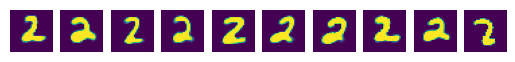

Lambda:  0.999 | Embedding Dim:  10
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6612 | Reconstruction Loss: 0.6415 | KLD Loss: 20.3294
Epoch 50 | Total Loss: 0.4565 | Reconstruction Loss: 0.4366 | KLD Loss: 20.3873
Epoch 100 | Total Loss: 0.4528 | Reconstruction Loss: 0.4324 | KLD Loss: 20.8402
Epoch 150 | Total Loss: 0.4505 | Reconstruction Loss: 0.4300 | KLD Loss: 20.9666
Epoch 200 | Total Loss: 0.4492 | Reconstruction Loss: 0.4286 | KLD Loss: 21.0133
Epoch 250 | Total Loss: 0.4480 | Reconstruction Loss: 0.4274 | KLD Loss: 20.9787
Epoch 299 | Total Loss: 0.4473 | Reconstruction Loss: 0.4267 | KLD Loss: 21.0528


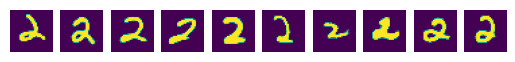

Lambda:  0.999 | Embedding Dim:  100
---------------------------------------------------------
Epoch 0 | Total Loss: 0.7454 | Reconstruction Loss: 0.7213 | KLD Loss: 24.8037
Epoch 50 | Total Loss: 0.4557 | Reconstruction Loss: 0.4289 | KLD Loss: 27.1951
Epoch 100 | Total Loss: 0.4516 | Reconstruction Loss: 0.4247 | KLD Loss: 27.3201
Epoch 150 | Total Loss: 0.4496 | Reconstruction Loss: 0.4229 | KLD Loss: 27.1188
Epoch 200 | Total Loss: 0.4482 | Reconstruction Loss: 0.4217 | KLD Loss: 26.9166
Epoch 250 | Total Loss: 0.4470 | Reconstruction Loss: 0.4204 | KLD Loss: 26.9397
Epoch 299 | Total Loss: 0.4461 | Reconstruction Loss: 0.4198 | KLD Loss: 26.7292


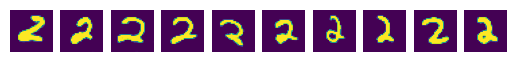

Lambda:  0.999 | Embedding Dim:  1000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.8139 | Reconstruction Loss: 0.7474 | KLD Loss: 67.2462
Epoch 50 | Total Loss: 0.4891 | Reconstruction Loss: 0.4569 | KLD Loss: 32.6741
Epoch 100 | Total Loss: 0.4664 | Reconstruction Loss: 0.4392 | KLD Loss: 27.6936
Epoch 150 | Total Loss: 0.4578 | Reconstruction Loss: 0.4319 | KLD Loss: 26.3092
Epoch 200 | Total Loss: 0.4541 | Reconstruction Loss: 0.4285 | KLD Loss: 25.9926
Epoch 250 | Total Loss: 0.4517 | Reconstruction Loss: 0.4265 | KLD Loss: 25.5741
Epoch 299 | Total Loss: 0.4504 | Reconstruction Loss: 0.4253 | KLD Loss: 25.4845


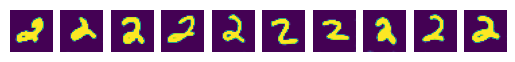

Lambda:  0.999 | Embedding Dim:  2000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.8551 | Reconstruction Loss: 0.7473 | KLD Loss: 108.6422
Epoch 50 | Total Loss: 0.4958 | Reconstruction Loss: 0.4617 | KLD Loss: 34.5518
Epoch 100 | Total Loss: 0.4908 | Reconstruction Loss: 0.4566 | KLD Loss: 34.6018
Epoch 150 | Total Loss: 0.4883 | Reconstruction Loss: 0.4539 | KLD Loss: 34.8190
Epoch 200 | Total Loss: 0.4866 | Reconstruction Loss: 0.4525 | KLD Loss: 34.5790
Epoch 250 | Total Loss: 0.4854 | Reconstruction Loss: 0.4511 | KLD Loss: 34.7451
Epoch 299 | Total Loss: 0.4831 | Reconstruction Loss: 0.4492 | KLD Loss: 34.3113


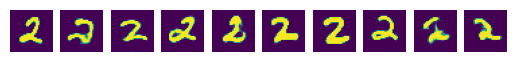

Lambda:  0.999 | Embedding Dim:  4000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.9146 | Reconstruction Loss: 0.7411 | KLD Loss: 174.1832
Epoch 50 | Total Loss: 0.4980 | Reconstruction Loss: 0.4635 | KLD Loss: 34.9834
Epoch 100 | Total Loss: 0.4924 | Reconstruction Loss: 0.4578 | KLD Loss: 35.0330
Epoch 150 | Total Loss: 0.4898 | Reconstruction Loss: 0.4553 | KLD Loss: 34.8851
Epoch 200 | Total Loss: 0.4890 | Reconstruction Loss: 0.4540 | KLD Loss: 35.4327
Epoch 250 | Total Loss: 0.4880 | Reconstruction Loss: 0.4530 | KLD Loss: 35.3873
Epoch 299 | Total Loss: 0.4862 | Reconstruction Loss: 0.4521 | KLD Loss: 34.5863


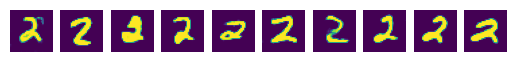

Lambda:  0.9999 | Embedding Dim:  2
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6508 | Reconstruction Loss: 0.6454 | KLD Loss: 54.8777
Epoch 50 | Total Loss: 0.5305 | Reconstruction Loss: 0.5295 | KLD Loss: 10.2581
Epoch 100 | Total Loss: 0.5239 | Reconstruction Loss: 0.5229 | KLD Loss: 10.8803
Epoch 150 | Total Loss: 0.5212 | Reconstruction Loss: 0.5201 | KLD Loss: 11.5060
Epoch 200 | Total Loss: 0.5185 | Reconstruction Loss: 0.5174 | KLD Loss: 11.6113
Epoch 250 | Total Loss: 0.5168 | Reconstruction Loss: 0.5157 | KLD Loss: 11.5749
Epoch 299 | Total Loss: 0.5158 | Reconstruction Loss: 0.5147 | KLD Loss: 11.4718


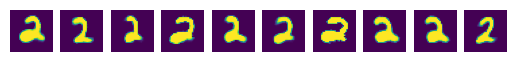

Lambda:  0.9999 | Embedding Dim:  10
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6306 | Reconstruction Loss: 0.6194 | KLD Loss: 112.2425
Epoch 50 | Total Loss: 0.4339 | Reconstruction Loss: 0.4304 | KLD Loss: 35.7276
Epoch 100 | Total Loss: 0.4296 | Reconstruction Loss: 0.4261 | KLD Loss: 35.7791
Epoch 150 | Total Loss: 0.4277 | Reconstruction Loss: 0.4241 | KLD Loss: 35.7822
Epoch 200 | Total Loss: 0.4258 | Reconstruction Loss: 0.4223 | KLD Loss: 35.5374
Epoch 250 | Total Loss: 0.4248 | Reconstruction Loss: 0.4213 | KLD Loss: 35.2893
Epoch 299 | Total Loss: 0.4239 | Reconstruction Loss: 0.4205 | KLD Loss: 35.2263


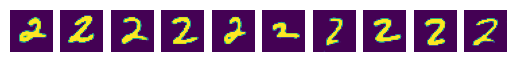

Lambda:  0.9999 | Embedding Dim:  100
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6125 | Reconstruction Loss: 0.5959 | KLD Loss: 166.3333
Epoch 50 | Total Loss: 0.4182 | Reconstruction Loss: 0.4087 | KLD Loss: 95.3914
Epoch 100 | Total Loss: 0.4145 | Reconstruction Loss: 0.4056 | KLD Loss: 90.1882
Epoch 150 | Total Loss: 0.4127 | Reconstruction Loss: 0.4039 | KLD Loss: 88.0875
Epoch 200 | Total Loss: 0.4116 | Reconstruction Loss: 0.4030 | KLD Loss: 86.9271
Epoch 250 | Total Loss: 0.4109 | Reconstruction Loss: 0.4023 | KLD Loss: 86.0571
Epoch 299 | Total Loss: 0.4103 | Reconstruction Loss: 0.4018 | KLD Loss: 85.2838


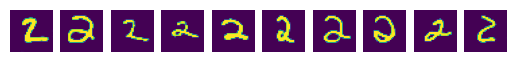

Lambda:  0.9999 | Embedding Dim:  1000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6307 | Reconstruction Loss: 0.6092 | KLD Loss: 215.7847
Epoch 50 | Total Loss: 0.4298 | Reconstruction Loss: 0.4167 | KLD Loss: 131.3840
Epoch 100 | Total Loss: 0.4207 | Reconstruction Loss: 0.4099 | KLD Loss: 108.9554
Epoch 150 | Total Loss: 0.4173 | Reconstruction Loss: 0.4073 | KLD Loss: 100.3349
Epoch 200 | Total Loss: 0.4155 | Reconstruction Loss: 0.4059 | KLD Loss: 95.8322
Epoch 250 | Total Loss: 0.4141 | Reconstruction Loss: 0.4049 | KLD Loss: 93.0743
Epoch 299 | Total Loss: 0.4134 | Reconstruction Loss: 0.4042 | KLD Loss: 91.7577


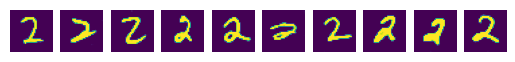

Lambda:  0.9999 | Embedding Dim:  2000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6411 | Reconstruction Loss: 0.6136 | KLD Loss: 275.9947
Epoch 50 | Total Loss: 0.4380 | Reconstruction Loss: 0.4229 | KLD Loss: 152.2029
Epoch 100 | Total Loss: 0.4318 | Reconstruction Loss: 0.4174 | KLD Loss: 144.3063
Epoch 150 | Total Loss: 0.4252 | Reconstruction Loss: 0.4125 | KLD Loss: 126.9996
Epoch 200 | Total Loss: 0.4208 | Reconstruction Loss: 0.4096 | KLD Loss: 112.5143
Epoch 250 | Total Loss: 0.4181 | Reconstruction Loss: 0.4077 | KLD Loss: 104.1348
Epoch 299 | Total Loss: 0.4165 | Reconstruction Loss: 0.4067 | KLD Loss: 98.9315


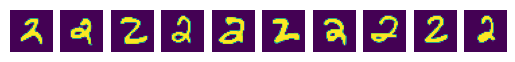

Lambda:  0.9999 | Embedding Dim:  4000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6992 | Reconstruction Loss: 0.6487 | KLD Loss: 505.8435
Epoch 50 | Total Loss: 0.4408 | Reconstruction Loss: 0.4252 | KLD Loss: 156.7386
Epoch 100 | Total Loss: 0.4351 | Reconstruction Loss: 0.4199 | KLD Loss: 151.9790
Epoch 150 | Total Loss: 0.4326 | Reconstruction Loss: 0.4177 | KLD Loss: 149.5131
Epoch 200 | Total Loss: 0.4311 | Reconstruction Loss: 0.4162 | KLD Loss: 148.6243
Epoch 250 | Total Loss: 0.4298 | Reconstruction Loss: 0.4152 | KLD Loss: 146.0635
Epoch 299 | Total Loss: 0.4292 | Reconstruction Loss: 0.4147 | KLD Loss: 145.1841


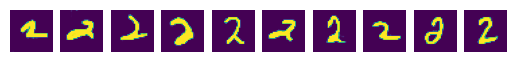

Classe:  3 

Lambda:  0.9 | Embedding Dim:  2
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6621 | Reconstruction Loss: 0.7122 | KLD Loss: 0.2111
Epoch 50 | Total Loss: 0.5140 | Reconstruction Loss: 0.5711 | KLD Loss: 0.0005
Epoch 100 | Total Loss: 0.5137 | Reconstruction Loss: 0.5708 | KLD Loss: 0.0000
Epoch 150 | Total Loss: 0.5136 | Reconstruction Loss: 0.5707 | KLD Loss: 0.0000
Epoch 200 | Total Loss: 0.5136 | Reconstruction Loss: 0.5706 | KLD Loss: 0.0000
Epoch 250 | Total Loss: 0.5136 | Reconstruction Loss: 0.5706 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.5135 | Reconstruction Loss: 0.5706 | KLD Loss: 0.0000


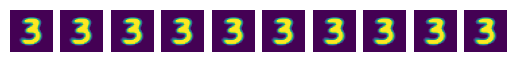

Lambda:  0.9 | Embedding Dim:  10
---------------------------------------------------------
Epoch 0 | Total Loss: 0.7416 | Reconstruction Loss: 0.7424 | KLD Loss: 0.7339
Epoch 50 | Total Loss: 0.5140 | Reconstruction Loss: 0.5711 | KLD Loss: 0.0004
Epoch 100 | Total Loss: 0.5138 | Reconstruction Loss: 0.5709 | KLD Loss: 0.0000
Epoch 150 | Total Loss: 0.5137 | Reconstruction Loss: 0.5707 | KLD Loss: 0.0000
Epoch 200 | Total Loss: 0.5136 | Reconstruction Loss: 0.5707 | KLD Loss: 0.0000
Epoch 250 | Total Loss: 0.5136 | Reconstruction Loss: 0.5707 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.5136 | Reconstruction Loss: 0.5706 | KLD Loss: 0.0000


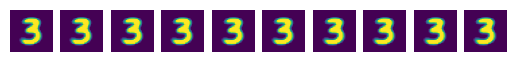

Lambda:  0.9 | Embedding Dim:  100
---------------------------------------------------------
Epoch 0 | Total Loss: 1.1874 | Reconstruction Loss: 0.7920 | KLD Loss: 4.7459
Epoch 50 | Total Loss: 0.5141 | Reconstruction Loss: 0.5712 | KLD Loss: 0.0002
Epoch 100 | Total Loss: 0.5138 | Reconstruction Loss: 0.5709 | KLD Loss: 0.0000
Epoch 150 | Total Loss: 0.5137 | Reconstruction Loss: 0.5708 | KLD Loss: 0.0000
Epoch 200 | Total Loss: 0.5137 | Reconstruction Loss: 0.5707 | KLD Loss: 0.0000
Epoch 250 | Total Loss: 0.5136 | Reconstruction Loss: 0.5707 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.5136 | Reconstruction Loss: 0.5707 | KLD Loss: 0.0000


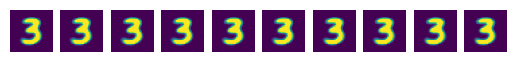

Lambda:  0.9 | Embedding Dim:  1000
---------------------------------------------------------
Epoch 0 | Total Loss: 4.8890 | Reconstruction Loss: 0.8052 | KLD Loss: 41.6429
Epoch 50 | Total Loss: 0.5144 | Reconstruction Loss: 0.5715 | KLD Loss: 0.0006
Epoch 100 | Total Loss: 0.5140 | Reconstruction Loss: 0.5711 | KLD Loss: 0.0000
Epoch 150 | Total Loss: 0.5139 | Reconstruction Loss: 0.5710 | KLD Loss: 0.0000
Epoch 200 | Total Loss: 0.5138 | Reconstruction Loss: 0.5709 | KLD Loss: 0.0000
Epoch 250 | Total Loss: 0.5138 | Reconstruction Loss: 0.5708 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.5137 | Reconstruction Loss: 0.5708 | KLD Loss: 0.0000


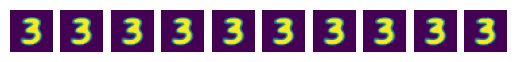

Lambda:  0.9 | Embedding Dim:  2000
---------------------------------------------------------
Epoch 0 | Total Loss: 8.2973 | Reconstruction Loss: 0.8221 | KLD Loss: 75.5742
Epoch 50 | Total Loss: 0.5148 | Reconstruction Loss: 0.5719 | KLD Loss: 0.0007
Epoch 100 | Total Loss: 0.5141 | Reconstruction Loss: 0.5712 | KLD Loss: 0.0000


KeyboardInterrupt: 

In [126]:
%%time

for classe in range(10):
    print('Classe: ', classe,'\n')
    output = grid_search(params, classe)

Classe:  3 

Lambda:  0.9 | Embedding Dim:  2
---------------------------------------------------------
Epoch 0 | Total Loss: 0.7123 | Reconstruction Loss: 0.7521 | KLD Loss: 0.3546
Epoch 50 | Total Loss: 0.5141 | Reconstruction Loss: 0.5712 | KLD Loss: 0.0006
Epoch 100 | Total Loss: 0.5139 | Reconstruction Loss: 0.5710 | KLD Loss: 0.0003
Epoch 150 | Total Loss: 0.5138 | Reconstruction Loss: 0.5708 | KLD Loss: 0.0001
Epoch 200 | Total Loss: 0.5137 | Reconstruction Loss: 0.5708 | KLD Loss: 0.0000
Epoch 250 | Total Loss: 0.5137 | Reconstruction Loss: 0.5707 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.5136 | Reconstruction Loss: 0.5707 | KLD Loss: 0.0000


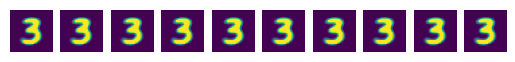

Lambda:  0.9 | Embedding Dim:  10
---------------------------------------------------------
Epoch 0 | Total Loss: 0.8416 | Reconstruction Loss: 0.8210 | KLD Loss: 1.0271
Epoch 50 | Total Loss: 0.5141 | Reconstruction Loss: 0.5711 | KLD Loss: 0.0011
Epoch 100 | Total Loss: 0.5139 | Reconstruction Loss: 0.5709 | KLD Loss: 0.0003
Epoch 150 | Total Loss: 0.5137 | Reconstruction Loss: 0.5708 | KLD Loss: 0.0001
Epoch 200 | Total Loss: 0.5137 | Reconstruction Loss: 0.5708 | KLD Loss: 0.0000
Epoch 250 | Total Loss: 0.5137 | Reconstruction Loss: 0.5707 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.5136 | Reconstruction Loss: 0.5707 | KLD Loss: 0.0000


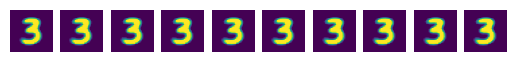

Lambda:  0.9 | Embedding Dim:  100
---------------------------------------------------------
Epoch 0 | Total Loss: 1.5400 | Reconstruction Loss: 0.8603 | KLD Loss: 7.6575
Epoch 50 | Total Loss: 0.5143 | Reconstruction Loss: 0.5712 | KLD Loss: 0.0015
Epoch 100 | Total Loss: 0.5139 | Reconstruction Loss: 0.5710 | KLD Loss: 0.0002
Epoch 150 | Total Loss: 0.5138 | Reconstruction Loss: 0.5709 | KLD Loss: 0.0001
Epoch 200 | Total Loss: 0.5138 | Reconstruction Loss: 0.5709 | KLD Loss: 0.0000
Epoch 250 | Total Loss: 0.5137 | Reconstruction Loss: 0.5708 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.5137 | Reconstruction Loss: 0.5708 | KLD Loss: 0.0000


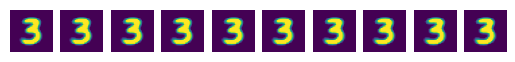

Lambda:  0.9 | Embedding Dim:  1000
---------------------------------------------------------
Epoch 0 | Total Loss: 7.4032 | Reconstruction Loss: 0.8691 | KLD Loss: 66.2099
Epoch 50 | Total Loss: 0.5149 | Reconstruction Loss: 0.5719 | KLD Loss: 0.0020
Epoch 100 | Total Loss: 0.5143 | Reconstruction Loss: 0.5714 | KLD Loss: 0.0005
Epoch 150 | Total Loss: 0.5141 | Reconstruction Loss: 0.5712 | KLD Loss: 0.0001
Epoch 200 | Total Loss: 0.5139 | Reconstruction Loss: 0.5710 | KLD Loss: 0.0000
Epoch 250 | Total Loss: 0.5138 | Reconstruction Loss: 0.5709 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.5139 | Reconstruction Loss: 0.5709 | KLD Loss: 0.0000


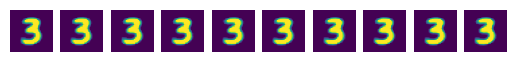

Lambda:  0.9 | Embedding Dim:  2000
---------------------------------------------------------
Epoch 0 | Total Loss: 13.4600 | Reconstruction Loss: 0.8429 | KLD Loss: 127.0137
Epoch 50 | Total Loss: 0.5154 | Reconstruction Loss: 0.5723 | KLD Loss: 0.0031
Epoch 100 | Total Loss: 0.5144 | Reconstruction Loss: 0.5714 | KLD Loss: 0.0006
Epoch 150 | Total Loss: 0.5141 | Reconstruction Loss: 0.5712 | KLD Loss: 0.0001
Epoch 200 | Total Loss: 0.5140 | Reconstruction Loss: 0.5711 | KLD Loss: 0.0000
Epoch 250 | Total Loss: 0.5138 | Reconstruction Loss: 0.5709 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.5138 | Reconstruction Loss: 0.5709 | KLD Loss: 0.0000


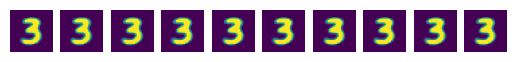

Lambda:  0.9 | Embedding Dim:  4000
---------------------------------------------------------
Epoch 0 | Total Loss: 25.9950 | Reconstruction Loss: 0.8477 | KLD Loss: 252.3207
Epoch 50 | Total Loss: 0.5173 | Reconstruction Loss: 0.5740 | KLD Loss: 0.0070
Epoch 100 | Total Loss: 0.5151 | Reconstruction Loss: 0.5719 | KLD Loss: 0.0033
Epoch 150 | Total Loss: 0.5143 | Reconstruction Loss: 0.5714 | KLD Loss: 0.0001
Epoch 200 | Total Loss: 0.5141 | Reconstruction Loss: 0.5712 | KLD Loss: 0.0000
Epoch 250 | Total Loss: 0.5139 | Reconstruction Loss: 0.5710 | KLD Loss: 0.0001
Epoch 299 | Total Loss: 0.5139 | Reconstruction Loss: 0.5710 | KLD Loss: 0.0002


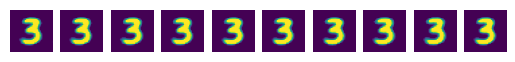

Lambda:  0.99 | Embedding Dim:  2
---------------------------------------------------------
Epoch 0 | Total Loss: 0.7452 | Reconstruction Loss: 0.7356 | KLD Loss: 1.6876
Epoch 50 | Total Loss: 0.5293 | Reconstruction Loss: 0.5125 | KLD Loss: 2.1999
Epoch 100 | Total Loss: 0.5277 | Reconstruction Loss: 0.5097 | KLD Loss: 2.3091
Epoch 150 | Total Loss: 0.5273 | Reconstruction Loss: 0.5083 | KLD Loss: 2.4055
Epoch 200 | Total Loss: 0.5260 | Reconstruction Loss: 0.5067 | KLD Loss: 2.4366
Epoch 250 | Total Loss: 0.5254 | Reconstruction Loss: 0.5056 | KLD Loss: 2.4877
Epoch 299 | Total Loss: 0.5254 | Reconstruction Loss: 0.5043 | KLD Loss: 2.6154


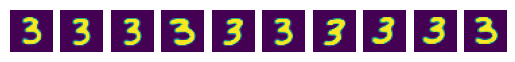

Lambda:  0.99 | Embedding Dim:  10
---------------------------------------------------------
Epoch 0 | Total Loss: 0.7954 | Reconstruction Loss: 0.7867 | KLD Loss: 1.6617
Epoch 50 | Total Loss: 0.5150 | Reconstruction Loss: 0.4772 | KLD Loss: 4.2578
Epoch 100 | Total Loss: 0.5135 | Reconstruction Loss: 0.4739 | KLD Loss: 4.4275
Epoch 150 | Total Loss: 0.5131 | Reconstruction Loss: 0.4728 | KLD Loss: 4.4969
Epoch 200 | Total Loss: 0.5123 | Reconstruction Loss: 0.4718 | KLD Loss: 4.5249
Epoch 250 | Total Loss: 0.5117 | Reconstruction Loss: 0.4712 | KLD Loss: 4.5184
Epoch 299 | Total Loss: 0.5119 | Reconstruction Loss: 0.4709 | KLD Loss: 4.5701


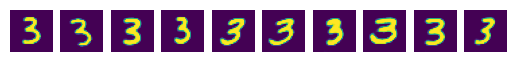

Lambda:  0.99 | Embedding Dim:  100
---------------------------------------------------------
Epoch 0 | Total Loss: 0.9059 | Reconstruction Loss: 0.8253 | KLD Loss: 8.8846
Epoch 50 | Total Loss: 0.5176 | Reconstruction Loss: 0.4831 | KLD Loss: 3.9379
Epoch 100 | Total Loss: 0.5156 | Reconstruction Loss: 0.4780 | KLD Loss: 4.2352
Epoch 150 | Total Loss: 0.5148 | Reconstruction Loss: 0.4766 | KLD Loss: 4.2983
Epoch 200 | Total Loss: 0.5140 | Reconstruction Loss: 0.4752 | KLD Loss: 4.3533
Epoch 250 | Total Loss: 0.5134 | Reconstruction Loss: 0.4738 | KLD Loss: 4.4249
Epoch 299 | Total Loss: 0.5135 | Reconstruction Loss: 0.4734 | KLD Loss: 4.4796


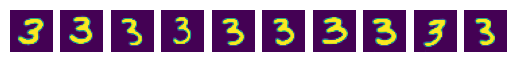

Lambda:  0.99 | Embedding Dim:  1000
---------------------------------------------------------
Epoch 0 | Total Loss: 1.5131 | Reconstruction Loss: 0.8512 | KLD Loss: 67.0473
Epoch 50 | Total Loss: 0.5413 | Reconstruction Loss: 0.5192 | KLD Loss: 2.7260
Epoch 100 | Total Loss: 0.5394 | Reconstruction Loss: 0.5166 | KLD Loss: 2.7968
Epoch 150 | Total Loss: 0.5391 | Reconstruction Loss: 0.5157 | KLD Loss: 2.8575
Epoch 200 | Total Loss: 0.5392 | Reconstruction Loss: 0.5158 | KLD Loss: 2.8560
Epoch 250 | Total Loss: 0.5389 | Reconstruction Loss: 0.5154 | KLD Loss: 2.8654
Epoch 299 | Total Loss: 0.5387 | Reconstruction Loss: 0.5150 | KLD Loss: 2.8834


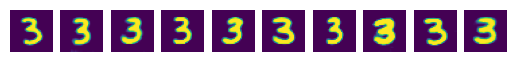

Lambda:  0.99 | Embedding Dim:  2000
---------------------------------------------------------
Epoch 0 | Total Loss: 2.0441 | Reconstruction Loss: 0.8098 | KLD Loss: 124.2402
Epoch 50 | Total Loss: 0.5439 | Reconstruction Loss: 0.5225 | KLD Loss: 2.6689
Epoch 100 | Total Loss: 0.5409 | Reconstruction Loss: 0.5186 | KLD Loss: 2.7518
Epoch 150 | Total Loss: 0.5412 | Reconstruction Loss: 0.5182 | KLD Loss: 2.8132
Epoch 200 | Total Loss: 0.5391 | Reconstruction Loss: 0.5165 | KLD Loss: 2.7823
Epoch 250 | Total Loss: 0.5402 | Reconstruction Loss: 0.5167 | KLD Loss: 2.8708
Epoch 299 | Total Loss: 0.5397 | Reconstruction Loss: 0.5163 | KLD Loss: 2.8532


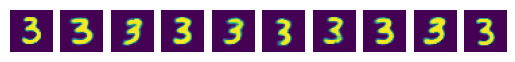

Lambda:  0.99 | Embedding Dim:  4000
---------------------------------------------------------
Epoch 0 | Total Loss: 3.3956 | Reconstruction Loss: 0.8255 | KLD Loss: 257.8302
Epoch 50 | Total Loss: 0.5458 | Reconstruction Loss: 0.5245 | KLD Loss: 2.6543
Epoch 100 | Total Loss: 0.5427 | Reconstruction Loss: 0.5205 | KLD Loss: 2.7383
Epoch 150 | Total Loss: 0.5404 | Reconstruction Loss: 0.5186 | KLD Loss: 2.7017
Epoch 200 | Total Loss: 0.5417 | Reconstruction Loss: 0.5194 | KLD Loss: 2.7567
Epoch 250 | Total Loss: 0.5405 | Reconstruction Loss: 0.5180 | KLD Loss: 2.7692
Epoch 299 | Total Loss: 0.5403 | Reconstruction Loss: 0.5177 | KLD Loss: 2.7792


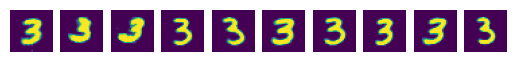

Lambda:  0.999 | Embedding Dim:  2
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6700 | Reconstruction Loss: 0.6519 | KLD Loss: 18.7342
Epoch 50 | Total Loss: 0.5019 | Reconstruction Loss: 0.4970 | KLD Loss: 5.3619
Epoch 100 | Total Loss: 0.4969 | Reconstruction Loss: 0.4915 | KLD Loss: 5.8403
Epoch 150 | Total Loss: 0.4948 | Reconstruction Loss: 0.4893 | KLD Loss: 5.9978
Epoch 200 | Total Loss: 0.4918 | Reconstruction Loss: 0.4861 | KLD Loss: 6.2641
Epoch 250 | Total Loss: 0.4905 | Reconstruction Loss: 0.4847 | KLD Loss: 6.2900
Epoch 299 | Total Loss: 0.4902 | Reconstruction Loss: 0.4843 | KLD Loss: 6.3902


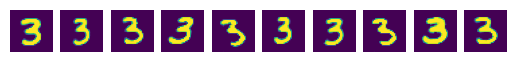

Lambda:  0.999 | Embedding Dim:  10
---------------------------------------------------------
Epoch 0 | Total Loss: 0.7406 | Reconstruction Loss: 0.7182 | KLD Loss: 23.1466
Epoch 50 | Total Loss: 0.4354 | Reconstruction Loss: 0.4166 | KLD Loss: 19.2252
Epoch 100 | Total Loss: 0.4326 | Reconstruction Loss: 0.4135 | KLD Loss: 19.4686
Epoch 150 | Total Loss: 0.4310 | Reconstruction Loss: 0.4120 | KLD Loss: 19.3893
Epoch 200 | Total Loss: 0.4297 | Reconstruction Loss: 0.4106 | KLD Loss: 19.5413
Epoch 250 | Total Loss: 0.4291 | Reconstruction Loss: 0.4100 | KLD Loss: 19.5560
Epoch 299 | Total Loss: 0.4284 | Reconstruction Loss: 0.4091 | KLD Loss: 19.6961


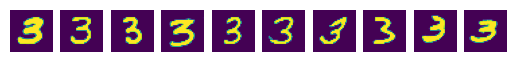

Lambda:  0.999 | Embedding Dim:  100
---------------------------------------------------------
Epoch 0 | Total Loss: 0.7687 | Reconstruction Loss: 0.7449 | KLD Loss: 24.5487
Epoch 50 | Total Loss: 0.4337 | Reconstruction Loss: 0.4090 | KLD Loss: 25.0712
Epoch 100 | Total Loss: 0.4299 | Reconstruction Loss: 0.4054 | KLD Loss: 24.8566
Epoch 150 | Total Loss: 0.4281 | Reconstruction Loss: 0.4036 | KLD Loss: 24.8875
Epoch 200 | Total Loss: 0.4269 | Reconstruction Loss: 0.4026 | KLD Loss: 24.6625
Epoch 250 | Total Loss: 0.4263 | Reconstruction Loss: 0.4021 | KLD Loss: 24.6335
Epoch 299 | Total Loss: 0.4255 | Reconstruction Loss: 0.4013 | KLD Loss: 24.5774


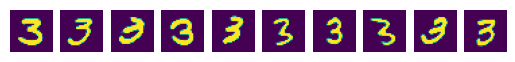

Lambda:  0.999 | Embedding Dim:  1000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.8819 | Reconstruction Loss: 0.7879 | KLD Loss: 94.7842
Epoch 50 | Total Loss: 0.4556 | Reconstruction Loss: 0.4290 | KLD Loss: 27.0220
Epoch 100 | Total Loss: 0.4387 | Reconstruction Loss: 0.4144 | KLD Loss: 24.7185
Epoch 150 | Total Loss: 0.4336 | Reconstruction Loss: 0.4097 | KLD Loss: 24.3146
Epoch 200 | Total Loss: 0.4315 | Reconstruction Loss: 0.4076 | KLD Loss: 24.3087
Epoch 250 | Total Loss: 0.4301 | Reconstruction Loss: 0.4062 | KLD Loss: 24.2250
Epoch 299 | Total Loss: 0.4291 | Reconstruction Loss: 0.4054 | KLD Loss: 24.1330


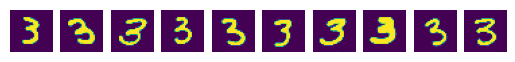

Lambda:  0.999 | Embedding Dim:  2000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.8820 | Reconstruction Loss: 0.7284 | KLD Loss: 154.3565
Epoch 50 | Total Loss: 0.4691 | Reconstruction Loss: 0.4394 | KLD Loss: 30.1804
Epoch 100 | Total Loss: 0.4622 | Reconstruction Loss: 0.4326 | KLD Loss: 30.0260
Epoch 150 | Total Loss: 0.4578 | Reconstruction Loss: 0.4291 | KLD Loss: 29.1388
Epoch 200 | Total Loss: 0.4496 | Reconstruction Loss: 0.4234 | KLD Loss: 26.6863
Epoch 250 | Total Loss: 0.4464 | Reconstruction Loss: 0.4211 | KLD Loss: 25.6942
Epoch 299 | Total Loss: 0.4437 | Reconstruction Loss: 0.4188 | KLD Loss: 25.3220


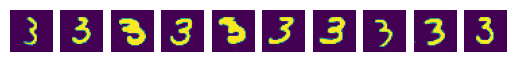

Lambda:  0.999 | Embedding Dim:  4000
---------------------------------------------------------
Epoch 0 | Total Loss: 1.0380 | Reconstruction Loss: 0.7552 | KLD Loss: 283.4753
Epoch 50 | Total Loss: 0.4710 | Reconstruction Loss: 0.4404 | KLD Loss: 30.9978
Epoch 100 | Total Loss: 0.4663 | Reconstruction Loss: 0.4355 | KLD Loss: 31.2339
Epoch 150 | Total Loss: 0.4640 | Reconstruction Loss: 0.4328 | KLD Loss: 31.6243
Epoch 200 | Total Loss: 0.4627 | Reconstruction Loss: 0.4314 | KLD Loss: 31.6984
Epoch 250 | Total Loss: 0.4619 | Reconstruction Loss: 0.4307 | KLD Loss: 31.7023
Epoch 299 | Total Loss: 0.4619 | Reconstruction Loss: 0.4305 | KLD Loss: 31.8125


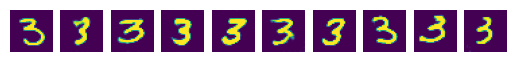

Lambda:  0.9999 | Embedding Dim:  2
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6803 | Reconstruction Loss: 0.6686 | KLD Loss: 118.5179
Epoch 50 | Total Loss: 0.4981 | Reconstruction Loss: 0.4971 | KLD Loss: 10.2403
Epoch 100 | Total Loss: 0.4911 | Reconstruction Loss: 0.4901 | KLD Loss: 10.1821
Epoch 150 | Total Loss: 0.4885 | Reconstruction Loss: 0.4874 | KLD Loss: 10.6234
Epoch 200 | Total Loss: 0.4870 | Reconstruction Loss: 0.4860 | KLD Loss: 10.5111
Epoch 250 | Total Loss: 0.4854 | Reconstruction Loss: 0.4844 | KLD Loss: 10.8532
Epoch 299 | Total Loss: 0.4842 | Reconstruction Loss: 0.4832 | KLD Loss: 10.8745


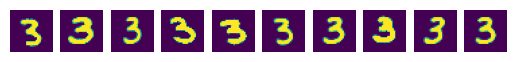

Lambda:  0.9999 | Embedding Dim:  10
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6672 | Reconstruction Loss: 0.6536 | KLD Loss: 136.5330
Epoch 50 | Total Loss: 0.4151 | Reconstruction Loss: 0.4117 | KLD Loss: 34.9203
Epoch 100 | Total Loss: 0.4111 | Reconstruction Loss: 0.4077 | KLD Loss: 34.1915
Epoch 150 | Total Loss: 0.4090 | Reconstruction Loss: 0.4057 | KLD Loss: 34.0117
Epoch 200 | Total Loss: 0.4077 | Reconstruction Loss: 0.4044 | KLD Loss: 34.0216
Epoch 250 | Total Loss: 0.4069 | Reconstruction Loss: 0.4036 | KLD Loss: 34.1298
Epoch 299 | Total Loss: 0.4063 | Reconstruction Loss: 0.4029 | KLD Loss: 34.2351


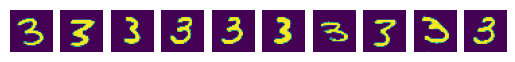

Lambda:  0.9999 | Embedding Dim:  100
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6550 | Reconstruction Loss: 0.6366 | KLD Loss: 184.5330
Epoch 50 | Total Loss: 0.3999 | Reconstruction Loss: 0.3901 | KLD Loss: 97.6311
Epoch 100 | Total Loss: 0.3959 | Reconstruction Loss: 0.3871 | KLD Loss: 88.4969
Epoch 150 | Total Loss: 0.3944 | Reconstruction Loss: 0.3859 | KLD Loss: 85.6617
Epoch 200 | Total Loss: 0.3933 | Reconstruction Loss: 0.3849 | KLD Loss: 84.3169
Epoch 250 | Total Loss: 0.3927 | Reconstruction Loss: 0.3844 | KLD Loss: 83.3857
Epoch 299 | Total Loss: 0.3921 | Reconstruction Loss: 0.3839 | KLD Loss: 82.1534


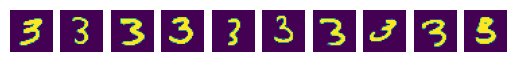

Lambda:  0.9999 | Embedding Dim:  1000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6614 | Reconstruction Loss: 0.6366 | KLD Loss: 249.6174
Epoch 50 | Total Loss: 0.4067 | Reconstruction Loss: 0.3957 | KLD Loss: 110.8188
Epoch 100 | Total Loss: 0.4001 | Reconstruction Loss: 0.3906 | KLD Loss: 94.6282
Epoch 150 | Total Loss: 0.3976 | Reconstruction Loss: 0.3886 | KLD Loss: 90.1312
Epoch 200 | Total Loss: 0.3963 | Reconstruction Loss: 0.3874 | KLD Loss: 88.4601
Epoch 250 | Total Loss: 0.3952 | Reconstruction Loss: 0.3866 | KLD Loss: 86.4616
Epoch 299 | Total Loss: 0.3944 | Reconstruction Loss: 0.3859 | KLD Loss: 85.1655


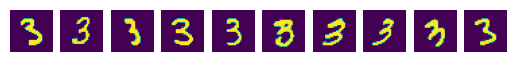

Lambda:  0.9999 | Embedding Dim:  2000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6921 | Reconstruction Loss: 0.6488 | KLD Loss: 433.9719
Epoch 50 | Total Loss: 0.4156 | Reconstruction Loss: 0.4018 | KLD Loss: 137.8876
Epoch 100 | Total Loss: 0.4058 | Reconstruction Loss: 0.3945 | KLD Loss: 113.4281
Epoch 150 | Total Loss: 0.4006 | Reconstruction Loss: 0.3907 | KLD Loss: 98.7636
Epoch 200 | Total Loss: 0.3981 | Reconstruction Loss: 0.3888 | KLD Loss: 92.7082
Epoch 250 | Total Loss: 0.3966 | Reconstruction Loss: 0.3877 | KLD Loss: 89.5066
Epoch 299 | Total Loss: 0.3958 | Reconstruction Loss: 0.3871 | KLD Loss: 87.2829


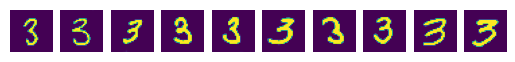

Lambda:  0.9999 | Embedding Dim:  4000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.7393 | Reconstruction Loss: 0.6908 | KLD Loss: 485.2689
Epoch 50 | Total Loss: 0.4184 | Reconstruction Loss: 0.4043 | KLD Loss: 141.6956
Epoch 100 | Total Loss: 0.4142 | Reconstruction Loss: 0.4003 | KLD Loss: 139.1803
Epoch 150 | Total Loss: 0.4119 | Reconstruction Loss: 0.3982 | KLD Loss: 137.3025
Epoch 200 | Total Loss: 0.4105 | Reconstruction Loss: 0.3969 | KLD Loss: 136.7944
Epoch 250 | Total Loss: 0.4088 | Reconstruction Loss: 0.3955 | KLD Loss: 133.2776
Epoch 299 | Total Loss: 0.4073 | Reconstruction Loss: 0.3946 | KLD Loss: 127.6636


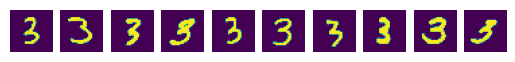

Classe:  4 

Lambda:  0.9 | Embedding Dim:  2
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6786 | Reconstruction Loss: 0.7177 | KLD Loss: 0.3271
Epoch 50 | Total Loss: 0.4751 | Reconstruction Loss: 0.5278 | KLD Loss: 0.0007
Epoch 100 | Total Loss: 0.4749 | Reconstruction Loss: 0.5277 | KLD Loss: 0.0003
Epoch 150 | Total Loss: 0.4748 | Reconstruction Loss: 0.5276 | KLD Loss: 0.0001
Epoch 200 | Total Loss: 0.4748 | Reconstruction Loss: 0.5276 | KLD Loss: 0.0000
Epoch 250 | Total Loss: 0.4748 | Reconstruction Loss: 0.5275 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.4747 | Reconstruction Loss: 0.5275 | KLD Loss: 0.0000


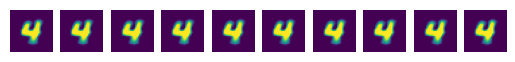

Lambda:  0.9 | Embedding Dim:  10
---------------------------------------------------------
Epoch 0 | Total Loss: 0.7742 | Reconstruction Loss: 0.7411 | KLD Loss: 1.0712
Epoch 50 | Total Loss: 0.4751 | Reconstruction Loss: 0.5278 | KLD Loss: 0.0010
Epoch 100 | Total Loss: 0.4750 | Reconstruction Loss: 0.5278 | KLD Loss: 0.0006
Epoch 150 | Total Loss: 0.4748 | Reconstruction Loss: 0.5276 | KLD Loss: 0.0001
Epoch 200 | Total Loss: 0.4748 | Reconstruction Loss: 0.5275 | KLD Loss: 0.0000
Epoch 250 | Total Loss: 0.4748 | Reconstruction Loss: 0.5275 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.4747 | Reconstruction Loss: 0.5275 | KLD Loss: 0.0000


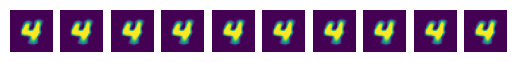

Lambda:  0.9 | Embedding Dim:  100
---------------------------------------------------------
Epoch 0 | Total Loss: 1.4403 | Reconstruction Loss: 0.7890 | KLD Loss: 7.3019
Epoch 50 | Total Loss: 0.4754 | Reconstruction Loss: 0.5279 | KLD Loss: 0.0032
Epoch 100 | Total Loss: 0.4750 | Reconstruction Loss: 0.5277 | KLD Loss: 0.0005
Epoch 150 | Total Loss: 0.4749 | Reconstruction Loss: 0.5277 | KLD Loss: 0.0001
Epoch 200 | Total Loss: 0.4749 | Reconstruction Loss: 0.5276 | KLD Loss: 0.0000
Epoch 250 | Total Loss: 0.4748 | Reconstruction Loss: 0.5275 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.4748 | Reconstruction Loss: 0.5275 | KLD Loss: 0.0000


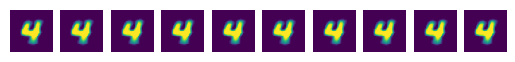

Lambda:  0.9 | Embedding Dim:  1000
---------------------------------------------------------
Epoch 0 | Total Loss: 7.0019 | Reconstruction Loss: 0.7805 | KLD Loss: 62.9941
Epoch 50 | Total Loss: 0.4759 | Reconstruction Loss: 0.5284 | KLD Loss: 0.0037
Epoch 100 | Total Loss: 0.4752 | Reconstruction Loss: 0.5280 | KLD Loss: 0.0005
Epoch 150 | Total Loss: 0.4750 | Reconstruction Loss: 0.5278 | KLD Loss: 0.0001
Epoch 200 | Total Loss: 0.4749 | Reconstruction Loss: 0.5276 | KLD Loss: 0.0000
Epoch 250 | Total Loss: 0.4749 | Reconstruction Loss: 0.5277 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.4749 | Reconstruction Loss: 0.5276 | KLD Loss: 0.0000


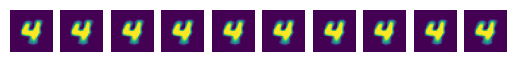

Lambda:  0.9 | Embedding Dim:  2000
---------------------------------------------------------
Epoch 0 | Total Loss: 13.5084 | Reconstruction Loss: 0.8016 | KLD Loss: 127.8700
Epoch 50 | Total Loss: 0.4772 | Reconstruction Loss: 0.5289 | KLD Loss: 0.0120
Epoch 100 | Total Loss: 0.4755 | Reconstruction Loss: 0.5282 | KLD Loss: 0.0011
Epoch 150 | Total Loss: 0.4751 | Reconstruction Loss: 0.5279 | KLD Loss: 0.0001
Epoch 200 | Total Loss: 0.4768 | Reconstruction Loss: 0.5278 | KLD Loss: 0.0176
Epoch 250 | Total Loss: 0.4749 | Reconstruction Loss: 0.5277 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.4749 | Reconstruction Loss: 0.5276 | KLD Loss: 0.0000


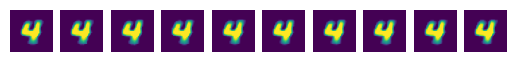

Lambda:  0.9 | Embedding Dim:  4000
---------------------------------------------------------
Epoch 0 | Total Loss: 26.0758 | Reconstruction Loss: 0.7628 | KLD Loss: 253.8922
Epoch 50 | Total Loss: 0.4778 | Reconstruction Loss: 0.5297 | KLD Loss: 0.0109
Epoch 100 | Total Loss: 0.4757 | Reconstruction Loss: 0.5284 | KLD Loss: 0.0013
Epoch 150 | Total Loss: 0.4753 | Reconstruction Loss: 0.5281 | KLD Loss: 0.0001
Epoch 200 | Total Loss: 0.4751 | Reconstruction Loss: 0.5278 | KLD Loss: 0.0001
Epoch 250 | Total Loss: 0.4750 | Reconstruction Loss: 0.5278 | KLD Loss: 0.0004
Epoch 299 | Total Loss: 0.4750 | Reconstruction Loss: 0.5278 | KLD Loss: 0.0001


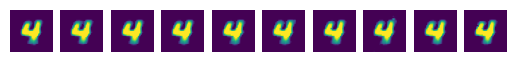

Lambda:  0.99 | Embedding Dim:  2
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6950 | Reconstruction Loss: 0.6846 | KLD Loss: 1.7183
Epoch 50 | Total Loss: 0.4769 | Reconstruction Loss: 0.4554 | KLD Loss: 2.6068
Epoch 100 | Total Loss: 0.4761 | Reconstruction Loss: 0.4536 | KLD Loss: 2.7065
Epoch 150 | Total Loss: 0.4754 | Reconstruction Loss: 0.4528 | KLD Loss: 2.7130
Epoch 200 | Total Loss: 0.4749 | Reconstruction Loss: 0.4521 | KLD Loss: 2.7296
Epoch 250 | Total Loss: 0.4745 | Reconstruction Loss: 0.4513 | KLD Loss: 2.7624
Epoch 299 | Total Loss: 0.4742 | Reconstruction Loss: 0.4508 | KLD Loss: 2.7830


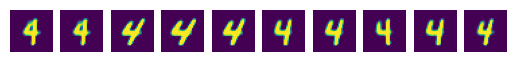

Lambda:  0.99 | Embedding Dim:  10
---------------------------------------------------------
Epoch 0 | Total Loss: 0.7819 | Reconstruction Loss: 0.7644 | KLD Loss: 2.5132
Epoch 50 | Total Loss: 0.4679 | Reconstruction Loss: 0.4268 | KLD Loss: 4.5415
Epoch 100 | Total Loss: 0.4657 | Reconstruction Loss: 0.4233 | KLD Loss: 4.6557
Epoch 150 | Total Loss: 0.4648 | Reconstruction Loss: 0.4222 | KLD Loss: 4.6822
Epoch 200 | Total Loss: 0.4641 | Reconstruction Loss: 0.4213 | KLD Loss: 4.6969
Epoch 250 | Total Loss: 0.4634 | Reconstruction Loss: 0.4206 | KLD Loss: 4.7008
Epoch 299 | Total Loss: 0.4629 | Reconstruction Loss: 0.4200 | KLD Loss: 4.7137


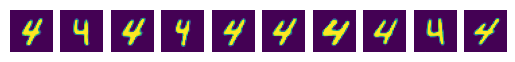

Lambda:  0.99 | Embedding Dim:  100
---------------------------------------------------------
Epoch 0 | Total Loss: 0.8210 | Reconstruction Loss: 0.7413 | KLD Loss: 8.7087
Epoch 50 | Total Loss: 0.4711 | Reconstruction Loss: 0.4350 | KLD Loss: 4.0444
Epoch 100 | Total Loss: 0.4679 | Reconstruction Loss: 0.4299 | KLD Loss: 4.2338
Epoch 150 | Total Loss: 0.4658 | Reconstruction Loss: 0.4256 | KLD Loss: 4.4453
Epoch 200 | Total Loss: 0.4652 | Reconstruction Loss: 0.4245 | KLD Loss: 4.4940
Epoch 250 | Total Loss: 0.4643 | Reconstruction Loss: 0.4233 | KLD Loss: 4.5192
Epoch 299 | Total Loss: 0.4652 | Reconstruction Loss: 0.4236 | KLD Loss: 4.5837


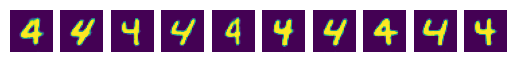

Lambda:  0.99 | Embedding Dim:  1000
---------------------------------------------------------
Epoch 0 | Total Loss: 1.4291 | Reconstruction Loss: 0.7547 | KLD Loss: 68.1905
Epoch 50 | Total Loss: 0.4967 | Reconstruction Loss: 0.4708 | KLD Loss: 3.0575
Epoch 100 | Total Loss: 0.4937 | Reconstruction Loss: 0.4680 | KLD Loss: 3.0379
Epoch 150 | Total Loss: 0.4932 | Reconstruction Loss: 0.4669 | KLD Loss: 3.0966
Epoch 200 | Total Loss: 0.4936 | Reconstruction Loss: 0.4664 | KLD Loss: 3.1875
Epoch 250 | Total Loss: 0.4938 | Reconstruction Loss: 0.4665 | KLD Loss: 3.1941
Epoch 299 | Total Loss: 0.4924 | Reconstruction Loss: 0.4645 | KLD Loss: 3.2489


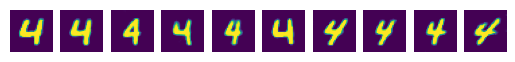

Lambda:  0.99 | Embedding Dim:  2000
---------------------------------------------------------
Epoch 0 | Total Loss: 2.0080 | Reconstruction Loss: 0.7449 | KLD Loss: 127.0588
Epoch 50 | Total Loss: 0.4976 | Reconstruction Loss: 0.4722 | KLD Loss: 3.0125
Epoch 100 | Total Loss: 0.4962 | Reconstruction Loss: 0.4700 | KLD Loss: 3.0881
Epoch 150 | Total Loss: 0.4944 | Reconstruction Loss: 0.4682 | KLD Loss: 3.0810
Epoch 200 | Total Loss: 0.4942 | Reconstruction Loss: 0.4677 | KLD Loss: 3.1252
Epoch 250 | Total Loss: 0.4949 | Reconstruction Loss: 0.4683 | KLD Loss: 3.1259
Epoch 299 | Total Loss: 0.4931 | Reconstruction Loss: 0.4663 | KLD Loss: 3.1487


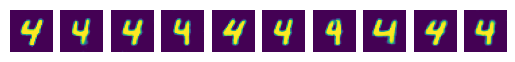

Lambda:  0.99 | Embedding Dim:  4000
---------------------------------------------------------
Epoch 0 | Total Loss: 3.1680 | Reconstruction Loss: 0.7406 | KLD Loss: 243.4769
Epoch 50 | Total Loss: 0.5003 | Reconstruction Loss: 0.4752 | KLD Loss: 2.9882
Epoch 100 | Total Loss: 0.4963 | Reconstruction Loss: 0.4711 | KLD Loss: 2.9897
Epoch 150 | Total Loss: 0.4955 | Reconstruction Loss: 0.4695 | KLD Loss: 3.0692
Epoch 200 | Total Loss: 0.4952 | Reconstruction Loss: 0.4686 | KLD Loss: 3.1316
Epoch 250 | Total Loss: 0.4954 | Reconstruction Loss: 0.4685 | KLD Loss: 3.1602
Epoch 299 | Total Loss: 0.4963 | Reconstruction Loss: 0.4693 | KLD Loss: 3.1667


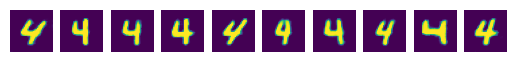

Lambda:  0.999 | Embedding Dim:  2
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6343 | Reconstruction Loss: 0.6162 | KLD Loss: 18.7566
Epoch 50 | Total Loss: 0.4505 | Reconstruction Loss: 0.4455 | KLD Loss: 5.4966
Epoch 100 | Total Loss: 0.4472 | Reconstruction Loss: 0.4419 | KLD Loss: 5.7729
Epoch 150 | Total Loss: 0.4457 | Reconstruction Loss: 0.4403 | KLD Loss: 5.8794
Epoch 200 | Total Loss: 0.4440 | Reconstruction Loss: 0.4385 | KLD Loss: 5.9924
Epoch 250 | Total Loss: 0.4431 | Reconstruction Loss: 0.4374 | KLD Loss: 6.1270
Epoch 299 | Total Loss: 0.4416 | Reconstruction Loss: 0.4358 | KLD Loss: 6.2931


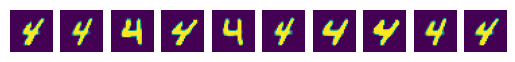

Lambda:  0.999 | Embedding Dim:  10
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6938 | Reconstruction Loss: 0.6718 | KLD Loss: 22.6759
Epoch 50 | Total Loss: 0.3918 | Reconstruction Loss: 0.3732 | KLD Loss: 18.9642
Epoch 100 | Total Loss: 0.3889 | Reconstruction Loss: 0.3701 | KLD Loss: 19.1516
Epoch 150 | Total Loss: 0.3867 | Reconstruction Loss: 0.3679 | KLD Loss: 19.1155
Epoch 200 | Total Loss: 0.3857 | Reconstruction Loss: 0.3669 | KLD Loss: 19.2039
Epoch 250 | Total Loss: 0.3850 | Reconstruction Loss: 0.3662 | KLD Loss: 19.1826
Epoch 299 | Total Loss: 0.3843 | Reconstruction Loss: 0.3655 | KLD Loss: 19.2201


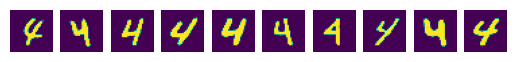

Lambda:  0.999 | Embedding Dim:  100
---------------------------------------------------------
Epoch 0 | Total Loss: 0.7008 | Reconstruction Loss: 0.6775 | KLD Loss: 23.9181
Epoch 50 | Total Loss: 0.3921 | Reconstruction Loss: 0.3692 | KLD Loss: 23.2417
Epoch 100 | Total Loss: 0.3885 | Reconstruction Loss: 0.3655 | KLD Loss: 23.3922
Epoch 150 | Total Loss: 0.3868 | Reconstruction Loss: 0.3640 | KLD Loss: 23.0772
Epoch 200 | Total Loss: 0.3858 | Reconstruction Loss: 0.3631 | KLD Loss: 23.0354
Epoch 250 | Total Loss: 0.3850 | Reconstruction Loss: 0.3624 | KLD Loss: 22.9843
Epoch 299 | Total Loss: 0.3841 | Reconstruction Loss: 0.3615 | KLD Loss: 22.9427


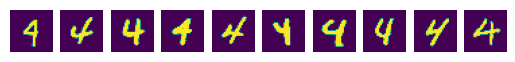

Lambda:  0.999 | Embedding Dim:  1000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.8306 | Reconstruction Loss: 0.7286 | KLD Loss: 102.7553
Epoch 50 | Total Loss: 0.4210 | Reconstruction Loss: 0.3944 | KLD Loss: 26.9651
Epoch 100 | Total Loss: 0.4000 | Reconstruction Loss: 0.3773 | KLD Loss: 23.0500
Epoch 150 | Total Loss: 0.3932 | Reconstruction Loss: 0.3709 | KLD Loss: 22.6119
Epoch 200 | Total Loss: 0.3898 | Reconstruction Loss: 0.3675 | KLD Loss: 22.7041
Epoch 250 | Total Loss: 0.3883 | Reconstruction Loss: 0.3660 | KLD Loss: 22.7083
Epoch 299 | Total Loss: 0.3875 | Reconstruction Loss: 0.3652 | KLD Loss: 22.7090


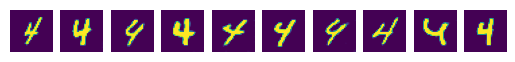

Lambda:  0.999 | Embedding Dim:  2000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.8768 | Reconstruction Loss: 0.7210 | KLD Loss: 156.5776
Epoch 50 | Total Loss: 0.4241 | Reconstruction Loss: 0.3970 | KLD Loss: 27.4804
Epoch 100 | Total Loss: 0.4200 | Reconstruction Loss: 0.3925 | KLD Loss: 27.9469
Epoch 150 | Total Loss: 0.4187 | Reconstruction Loss: 0.3907 | KLD Loss: 28.3556
Epoch 200 | Total Loss: 0.4174 | Reconstruction Loss: 0.3892 | KLD Loss: 28.5560
Epoch 250 | Total Loss: 0.4169 | Reconstruction Loss: 0.3884 | KLD Loss: 28.9672
Epoch 299 | Total Loss: 0.4137 | Reconstruction Loss: 0.3862 | KLD Loss: 27.8867


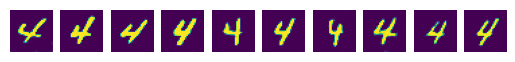

Lambda:  0.999 | Embedding Dim:  4000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.9325 | Reconstruction Loss: 0.6581 | KLD Loss: 275.0943
Epoch 50 | Total Loss: 0.4264 | Reconstruction Loss: 0.3990 | KLD Loss: 27.7990
Epoch 100 | Total Loss: 0.4218 | Reconstruction Loss: 0.3941 | KLD Loss: 28.0683
Epoch 150 | Total Loss: 0.4201 | Reconstruction Loss: 0.3919 | KLD Loss: 28.5939
Epoch 200 | Total Loss: 0.4185 | Reconstruction Loss: 0.3902 | KLD Loss: 28.7195
Epoch 250 | Total Loss: 0.4184 | Reconstruction Loss: 0.3897 | KLD Loss: 29.0313
Epoch 299 | Total Loss: 0.4171 | Reconstruction Loss: 0.3887 | KLD Loss: 28.8125


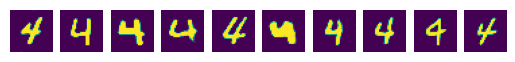

Lambda:  0.9999 | Embedding Dim:  2
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6210 | Reconstruction Loss: 0.6106 | KLD Loss: 105.1301
Epoch 50 | Total Loss: 0.4418 | Reconstruction Loss: 0.4409 | KLD Loss: 10.1256
Epoch 100 | Total Loss: 0.4389 | Reconstruction Loss: 0.4380 | KLD Loss: 9.7186
Epoch 150 | Total Loss: 0.4373 | Reconstruction Loss: 0.4363 | KLD Loss: 9.8615
Epoch 200 | Total Loss: 0.4360 | Reconstruction Loss: 0.4350 | KLD Loss: 10.0532
Epoch 250 | Total Loss: 0.4350 | Reconstruction Loss: 0.4340 | KLD Loss: 10.4930
Epoch 299 | Total Loss: 0.4341 | Reconstruction Loss: 0.4331 | KLD Loss: 10.5235


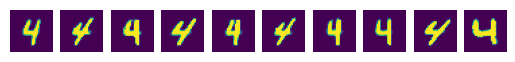

Lambda:  0.9999 | Embedding Dim:  10
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6498 | Reconstruction Loss: 0.6352 | KLD Loss: 146.3489
Epoch 50 | Total Loss: 0.3704 | Reconstruction Loss: 0.3669 | KLD Loss: 35.0153
Epoch 100 | Total Loss: 0.3667 | Reconstruction Loss: 0.3633 | KLD Loss: 34.2371
Epoch 150 | Total Loss: 0.3652 | Reconstruction Loss: 0.3618 | KLD Loss: 34.2804
Epoch 200 | Total Loss: 0.3640 | Reconstruction Loss: 0.3607 | KLD Loss: 34.2185
Epoch 250 | Total Loss: 0.3633 | Reconstruction Loss: 0.3599 | KLD Loss: 34.1905
Epoch 299 | Total Loss: 0.3626 | Reconstruction Loss: 0.3592 | KLD Loss: 34.2893


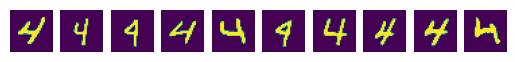

Lambda:  0.9999 | Embedding Dim:  100
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6071 | Reconstruction Loss: 0.5888 | KLD Loss: 183.7037
Epoch 50 | Total Loss: 0.3619 | Reconstruction Loss: 0.3529 | KLD Loss: 89.8246
Epoch 100 | Total Loss: 0.3577 | Reconstruction Loss: 0.3497 | KLD Loss: 80.1648
Epoch 150 | Total Loss: 0.3562 | Reconstruction Loss: 0.3485 | KLD Loss: 77.7457
Epoch 200 | Total Loss: 0.3552 | Reconstruction Loss: 0.3476 | KLD Loss: 76.3390
Epoch 250 | Total Loss: 0.3546 | Reconstruction Loss: 0.3471 | KLD Loss: 75.4367
Epoch 299 | Total Loss: 0.3539 | Reconstruction Loss: 0.3466 | KLD Loss: 74.0147


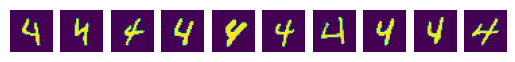

Lambda:  0.9999 | Embedding Dim:  1000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6183 | Reconstruction Loss: 0.5959 | KLD Loss: 225.0649
Epoch 50 | Total Loss: 0.3696 | Reconstruction Loss: 0.3588 | KLD Loss: 107.3880
Epoch 100 | Total Loss: 0.3622 | Reconstruction Loss: 0.3534 | KLD Loss: 89.0333
Epoch 150 | Total Loss: 0.3597 | Reconstruction Loss: 0.3514 | KLD Loss: 83.4660
Epoch 200 | Total Loss: 0.3581 | Reconstruction Loss: 0.3501 | KLD Loss: 80.4781
Epoch 250 | Total Loss: 0.3571 | Reconstruction Loss: 0.3492 | KLD Loss: 78.8508
Epoch 299 | Total Loss: 0.3564 | Reconstruction Loss: 0.3487 | KLD Loss: 77.2798


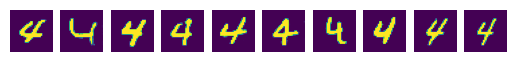

Lambda:  0.9999 | Embedding Dim:  2000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6280 | Reconstruction Loss: 0.5974 | KLD Loss: 306.1497
Epoch 50 | Total Loss: 0.3770 | Reconstruction Loss: 0.3642 | KLD Loss: 128.3575
Epoch 100 | Total Loss: 0.3699 | Reconstruction Loss: 0.3585 | KLD Loss: 114.1482
Epoch 150 | Total Loss: 0.3639 | Reconstruction Loss: 0.3542 | KLD Loss: 96.5122
Epoch 200 | Total Loss: 0.3609 | Reconstruction Loss: 0.3523 | KLD Loss: 86.5455
Epoch 250 | Total Loss: 0.3591 | Reconstruction Loss: 0.3509 | KLD Loss: 82.2120
Epoch 299 | Total Loss: 0.3579 | Reconstruction Loss: 0.3501 | KLD Loss: 79.1906


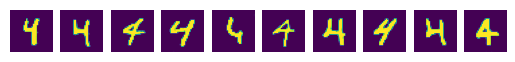

Lambda:  0.9999 | Embedding Dim:  4000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6708 | Reconstruction Loss: 0.6209 | KLD Loss: 499.5195
Epoch 50 | Total Loss: 0.3789 | Reconstruction Loss: 0.3659 | KLD Loss: 130.0479
Epoch 100 | Total Loss: 0.3746 | Reconstruction Loss: 0.3620 | KLD Loss: 126.2080
Epoch 150 | Total Loss: 0.3727 | Reconstruction Loss: 0.3601 | KLD Loss: 125.6150
Epoch 200 | Total Loss: 0.3714 | Reconstruction Loss: 0.3589 | KLD Loss: 125.2505
Epoch 250 | Total Loss: 0.3701 | Reconstruction Loss: 0.3578 | KLD Loss: 122.7891
Epoch 299 | Total Loss: 0.3695 | Reconstruction Loss: 0.3572 | KLD Loss: 122.8832


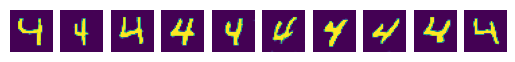

Classe:  5 

Lambda:  0.9 | Embedding Dim:  2
---------------------------------------------------------
Epoch 0 | Total Loss: 0.7095 | Reconstruction Loss: 0.7485 | KLD Loss: 0.3591
Epoch 50 | Total Loss: 0.5151 | Reconstruction Loss: 0.5723 | KLD Loss: 0.0007
Epoch 100 | Total Loss: 0.5149 | Reconstruction Loss: 0.5720 | KLD Loss: 0.0011
Epoch 150 | Total Loss: 0.5147 | Reconstruction Loss: 0.5717 | KLD Loss: 0.0013
Epoch 200 | Total Loss: 0.5147 | Reconstruction Loss: 0.5717 | KLD Loss: 0.0009
Epoch 250 | Total Loss: 0.5146 | Reconstruction Loss: 0.5714 | KLD Loss: 0.0031
Epoch 299 | Total Loss: 0.5145 | Reconstruction Loss: 0.5717 | KLD Loss: 0.0003


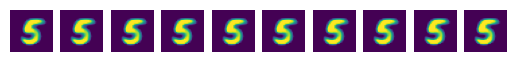

Lambda:  0.9 | Embedding Dim:  10
---------------------------------------------------------
Epoch 0 | Total Loss: 0.8287 | Reconstruction Loss: 0.7941 | KLD Loss: 1.1404
Epoch 50 | Total Loss: 0.5153 | Reconstruction Loss: 0.5720 | KLD Loss: 0.0048
Epoch 100 | Total Loss: 0.5149 | Reconstruction Loss: 0.5720 | KLD Loss: 0.0005
Epoch 150 | Total Loss: 0.5148 | Reconstruction Loss: 0.5719 | KLD Loss: 0.0003
Epoch 200 | Total Loss: 0.5147 | Reconstruction Loss: 0.5719 | KLD Loss: 0.0001
Epoch 250 | Total Loss: 0.5146 | Reconstruction Loss: 0.5718 | KLD Loss: 0.0001
Epoch 299 | Total Loss: 0.5146 | Reconstruction Loss: 0.5717 | KLD Loss: 0.0000


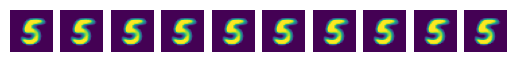

Lambda:  0.9 | Embedding Dim:  100
---------------------------------------------------------
Epoch 0 | Total Loss: 1.5205 | Reconstruction Loss: 0.8058 | KLD Loss: 7.9529
Epoch 50 | Total Loss: 0.5152 | Reconstruction Loss: 0.5723 | KLD Loss: 0.0013
Epoch 100 | Total Loss: 0.5149 | Reconstruction Loss: 0.5721 | KLD Loss: 0.0003
Epoch 150 | Total Loss: 0.5147 | Reconstruction Loss: 0.5719 | KLD Loss: 0.0001
Epoch 200 | Total Loss: 0.5147 | Reconstruction Loss: 0.5719 | KLD Loss: 0.0001
Epoch 250 | Total Loss: 0.5146 | Reconstruction Loss: 0.5718 | KLD Loss: 0.0001
Epoch 299 | Total Loss: 0.5146 | Reconstruction Loss: 0.5717 | KLD Loss: 0.0001


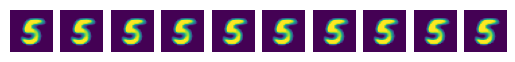

Lambda:  0.9 | Embedding Dim:  1000
---------------------------------------------------------
Epoch 0 | Total Loss: 7.3658 | Reconstruction Loss: 0.8030 | KLD Loss: 66.4309
Epoch 50 | Total Loss: 0.5159 | Reconstruction Loss: 0.5729 | KLD Loss: 0.0027
Epoch 100 | Total Loss: 0.5153 | Reconstruction Loss: 0.5725 | KLD Loss: 0.0011
Epoch 150 | Total Loss: 0.5149 | Reconstruction Loss: 0.5721 | KLD Loss: 0.0001
Epoch 200 | Total Loss: 0.5148 | Reconstruction Loss: 0.5720 | KLD Loss: 0.0000
Epoch 250 | Total Loss: 0.5148 | Reconstruction Loss: 0.5720 | KLD Loss: 0.0001
Epoch 299 | Total Loss: 0.5147 | Reconstruction Loss: 0.5719 | KLD Loss: 0.0001


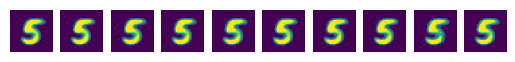

Lambda:  0.9 | Embedding Dim:  2000
---------------------------------------------------------
Epoch 0 | Total Loss: 13.9791 | Reconstruction Loss: 0.7833 | KLD Loss: 132.7411
Epoch 50 | Total Loss: 0.5164 | Reconstruction Loss: 0.5734 | KLD Loss: 0.0043
Epoch 100 | Total Loss: 0.5153 | Reconstruction Loss: 0.5725 | KLD Loss: 0.0005
Epoch 150 | Total Loss: 0.5149 | Reconstruction Loss: 0.5721 | KLD Loss: 0.0002
Epoch 200 | Total Loss: 0.5147 | Reconstruction Loss: 0.5719 | KLD Loss: 0.0001
Epoch 250 | Total Loss: 0.5147 | Reconstruction Loss: 0.5719 | KLD Loss: 0.0001
Epoch 299 | Total Loss: 0.5147 | Reconstruction Loss: 0.5718 | KLD Loss: 0.0000


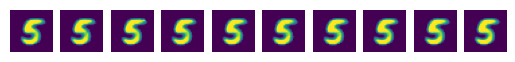

Lambda:  0.9 | Embedding Dim:  4000
---------------------------------------------------------
Epoch 0 | Total Loss: 28.1310 | Reconstruction Loss: 0.7718 | KLD Loss: 274.3634
Epoch 50 | Total Loss: 0.5180 | Reconstruction Loss: 0.5747 | KLD Loss: 0.0075
Epoch 100 | Total Loss: 0.5157 | Reconstruction Loss: 0.5727 | KLD Loss: 0.0027
Epoch 150 | Total Loss: 0.5151 | Reconstruction Loss: 0.5723 | KLD Loss: 0.0001
Epoch 200 | Total Loss: 0.5150 | Reconstruction Loss: 0.5723 | KLD Loss: 0.0001
Epoch 250 | Total Loss: 0.5149 | Reconstruction Loss: 0.5721 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.5148 | Reconstruction Loss: 0.5720 | KLD Loss: 0.0001


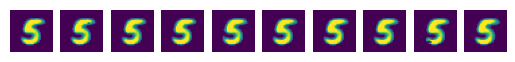

Lambda:  0.99 | Embedding Dim:  2
---------------------------------------------------------
Epoch 0 | Total Loss: 0.7794 | Reconstruction Loss: 0.7654 | KLD Loss: 2.1662
Epoch 50 | Total Loss: 0.4985 | Reconstruction Loss: 0.4770 | KLD Loss: 2.6301
Epoch 100 | Total Loss: 0.4973 | Reconstruction Loss: 0.4750 | KLD Loss: 2.7071
Epoch 150 | Total Loss: 0.4965 | Reconstruction Loss: 0.4740 | KLD Loss: 2.7192
Epoch 200 | Total Loss: 0.4958 | Reconstruction Loss: 0.4735 | KLD Loss: 2.7072
Epoch 250 | Total Loss: 0.4959 | Reconstruction Loss: 0.4727 | KLD Loss: 2.7927
Epoch 299 | Total Loss: 0.4959 | Reconstruction Loss: 0.4724 | KLD Loss: 2.8195


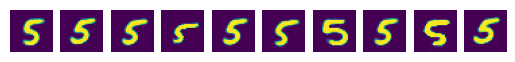

Lambda:  0.99 | Embedding Dim:  10
---------------------------------------------------------
Epoch 0 | Total Loss: 0.7578 | Reconstruction Loss: 0.7468 | KLD Loss: 1.8513
Epoch 50 | Total Loss: 0.4896 | Reconstruction Loss: 0.4487 | KLD Loss: 4.5343
Epoch 100 | Total Loss: 0.4875 | Reconstruction Loss: 0.4462 | KLD Loss: 4.5781
Epoch 150 | Total Loss: 0.4869 | Reconstruction Loss: 0.4445 | KLD Loss: 4.6906
Epoch 200 | Total Loss: 0.4859 | Reconstruction Loss: 0.4429 | KLD Loss: 4.7405
Epoch 250 | Total Loss: 0.4854 | Reconstruction Loss: 0.4423 | KLD Loss: 4.7523
Epoch 299 | Total Loss: 0.4847 | Reconstruction Loss: 0.4413 | KLD Loss: 4.7752


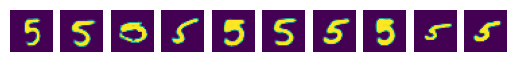

Lambda:  0.99 | Embedding Dim:  100
---------------------------------------------------------
Epoch 0 | Total Loss: 0.9165 | Reconstruction Loss: 0.8313 | KLD Loss: 9.3463
Epoch 50 | Total Loss: 0.4951 | Reconstruction Loss: 0.4570 | KLD Loss: 4.2619
Epoch 100 | Total Loss: 0.4911 | Reconstruction Loss: 0.4516 | KLD Loss: 4.4051
Epoch 150 | Total Loss: 0.4903 | Reconstruction Loss: 0.4493 | KLD Loss: 4.5515
Epoch 200 | Total Loss: 0.4885 | Reconstruction Loss: 0.4482 | KLD Loss: 4.4801
Epoch 250 | Total Loss: 0.4879 | Reconstruction Loss: 0.4467 | KLD Loss: 4.5642
Epoch 299 | Total Loss: 0.4868 | Reconstruction Loss: 0.4454 | KLD Loss: 4.5883


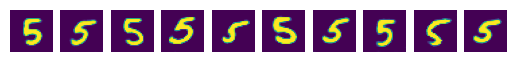

Lambda:  0.99 | Embedding Dim:  1000
---------------------------------------------------------
Epoch 0 | Total Loss: 1.4736 | Reconstruction Loss: 0.7909 | KLD Loss: 69.0663
Epoch 50 | Total Loss: 0.5246 | Reconstruction Loss: 0.4962 | KLD Loss: 3.3427
Epoch 100 | Total Loss: 0.5221 | Reconstruction Loss: 0.4929 | KLD Loss: 3.4167
Epoch 150 | Total Loss: 0.5200 | Reconstruction Loss: 0.4897 | KLD Loss: 3.5202
Epoch 200 | Total Loss: 0.5205 | Reconstruction Loss: 0.4900 | KLD Loss: 3.5354
Epoch 250 | Total Loss: 0.5193 | Reconstruction Loss: 0.4891 | KLD Loss: 3.5172
Epoch 299 | Total Loss: 0.5053 | Reconstruction Loss: 0.4759 | KLD Loss: 3.4132


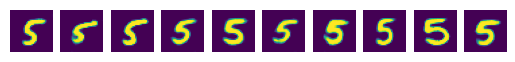

Lambda:  0.99 | Embedding Dim:  2000
---------------------------------------------------------
Epoch 0 | Total Loss: 2.1683 | Reconstruction Loss: 0.7807 | KLD Loss: 139.5353
Epoch 50 | Total Loss: 0.5250 | Reconstruction Loss: 0.4954 | KLD Loss: 3.4528
Epoch 100 | Total Loss: 0.5230 | Reconstruction Loss: 0.4932 | KLD Loss: 3.4740
Epoch 150 | Total Loss: 0.5215 | Reconstruction Loss: 0.4920 | KLD Loss: 3.4421
Epoch 200 | Total Loss: 0.5197 | Reconstruction Loss: 0.4891 | KLD Loss: 3.5542
Epoch 250 | Total Loss: 0.5205 | Reconstruction Loss: 0.4901 | KLD Loss: 3.5357
Epoch 299 | Total Loss: 0.5200 | Reconstruction Loss: 0.4893 | KLD Loss: 3.5535


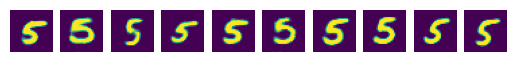

Lambda:  0.99 | Embedding Dim:  4000
---------------------------------------------------------
Epoch 0 | Total Loss: 3.5025 | Reconstruction Loss: 0.7861 | KLD Loss: 272.4247
Epoch 50 | Total Loss: 0.5297 | Reconstruction Loss: 0.5007 | KLD Loss: 3.3953
Epoch 100 | Total Loss: 0.5254 | Reconstruction Loss: 0.4960 | KLD Loss: 3.4342
Epoch 150 | Total Loss: 0.5233 | Reconstruction Loss: 0.4940 | KLD Loss: 3.4264
Epoch 200 | Total Loss: 0.5224 | Reconstruction Loss: 0.4918 | KLD Loss: 3.5529
Epoch 250 | Total Loss: 0.5228 | Reconstruction Loss: 0.4941 | KLD Loss: 3.3672
Epoch 299 | Total Loss: 0.5225 | Reconstruction Loss: 0.4932 | KLD Loss: 3.4209


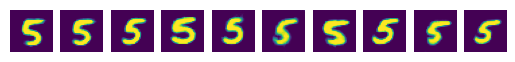

Lambda:  0.999 | Embedding Dim:  2
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6805 | Reconstruction Loss: 0.6629 | KLD Loss: 18.1985
Epoch 50 | Total Loss: 0.4691 | Reconstruction Loss: 0.4640 | KLD Loss: 5.5703
Epoch 100 | Total Loss: 0.4665 | Reconstruction Loss: 0.4612 | KLD Loss: 5.8134
Epoch 150 | Total Loss: 0.4640 | Reconstruction Loss: 0.4585 | KLD Loss: 5.9948
Epoch 200 | Total Loss: 0.4623 | Reconstruction Loss: 0.4566 | KLD Loss: 6.1627
Epoch 250 | Total Loss: 0.4612 | Reconstruction Loss: 0.4553 | KLD Loss: 6.2813
Epoch 299 | Total Loss: 0.4601 | Reconstruction Loss: 0.4541 | KLD Loss: 6.4497


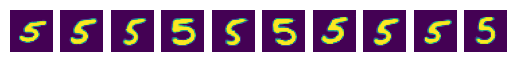

Lambda:  0.999 | Embedding Dim:  10
---------------------------------------------------------
Epoch 0 | Total Loss: 0.7541 | Reconstruction Loss: 0.7288 | KLD Loss: 25.9759
Epoch 50 | Total Loss: 0.4090 | Reconstruction Loss: 0.3899 | KLD Loss: 19.4749
Epoch 100 | Total Loss: 0.4053 | Reconstruction Loss: 0.3861 | KLD Loss: 19.6414
Epoch 150 | Total Loss: 0.4031 | Reconstruction Loss: 0.3838 | KLD Loss: 19.6817
Epoch 200 | Total Loss: 0.4020 | Reconstruction Loss: 0.3826 | KLD Loss: 19.8035
Epoch 250 | Total Loss: 0.4013 | Reconstruction Loss: 0.3819 | KLD Loss: 19.7905
Epoch 299 | Total Loss: 0.4006 | Reconstruction Loss: 0.3812 | KLD Loss: 19.7839


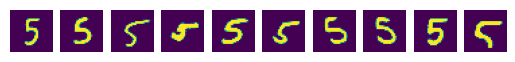

Lambda:  0.999 | Embedding Dim:  100
---------------------------------------------------------
Epoch 0 | Total Loss: 0.7449 | Reconstruction Loss: 0.7255 | KLD Loss: 20.0599
Epoch 50 | Total Loss: 0.4082 | Reconstruction Loss: 0.3825 | KLD Loss: 26.0866
Epoch 100 | Total Loss: 0.4044 | Reconstruction Loss: 0.3786 | KLD Loss: 26.1186
Epoch 150 | Total Loss: 0.4027 | Reconstruction Loss: 0.3769 | KLD Loss: 26.1378
Epoch 200 | Total Loss: 0.4014 | Reconstruction Loss: 0.3756 | KLD Loss: 26.1281
Epoch 250 | Total Loss: 0.4003 | Reconstruction Loss: 0.3747 | KLD Loss: 25.9324
Epoch 299 | Total Loss: 0.3998 | Reconstruction Loss: 0.3742 | KLD Loss: 26.0009


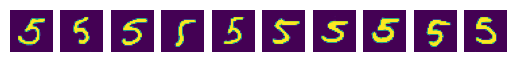

Lambda:  0.999 | Embedding Dim:  1000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.8311 | Reconstruction Loss: 0.7403 | KLD Loss: 91.5480
Epoch 50 | Total Loss: 0.4407 | Reconstruction Loss: 0.4107 | KLD Loss: 30.3980
Epoch 100 | Total Loss: 0.4202 | Reconstruction Loss: 0.3942 | KLD Loss: 26.3572
Epoch 150 | Total Loss: 0.4120 | Reconstruction Loss: 0.3868 | KLD Loss: 25.5665
Epoch 200 | Total Loss: 0.4078 | Reconstruction Loss: 0.3831 | KLD Loss: 25.0270
Epoch 250 | Total Loss: 0.4055 | Reconstruction Loss: 0.3809 | KLD Loss: 24.9873
Epoch 299 | Total Loss: 0.4041 | Reconstruction Loss: 0.3795 | KLD Loss: 24.9560


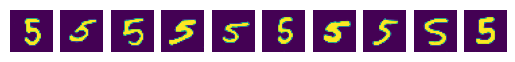

Lambda:  0.999 | Embedding Dim:  2000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.9013 | Reconstruction Loss: 0.7433 | KLD Loss: 158.7159
Epoch 50 | Total Loss: 0.4437 | Reconstruction Loss: 0.4134 | KLD Loss: 30.6843
Epoch 100 | Total Loss: 0.4395 | Reconstruction Loss: 0.4083 | KLD Loss: 31.5307
Epoch 150 | Total Loss: 0.4373 | Reconstruction Loss: 0.4061 | KLD Loss: 31.6120
Epoch 200 | Total Loss: 0.4352 | Reconstruction Loss: 0.4040 | KLD Loss: 31.6185
Epoch 250 | Total Loss: 0.4339 | Reconstruction Loss: 0.4028 | KLD Loss: 31.4937
Epoch 299 | Total Loss: 0.4318 | Reconstruction Loss: 0.4006 | KLD Loss: 31.6698


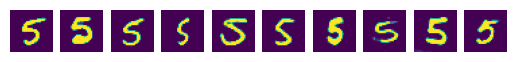

Lambda:  0.999 | Embedding Dim:  4000
---------------------------------------------------------
Epoch 0 | Total Loss: 1.0072 | Reconstruction Loss: 0.6992 | KLD Loss: 308.6675
Epoch 50 | Total Loss: 0.4460 | Reconstruction Loss: 0.4149 | KLD Loss: 31.4424
Epoch 100 | Total Loss: 0.4411 | Reconstruction Loss: 0.4099 | KLD Loss: 31.6040
Epoch 150 | Total Loss: 0.4392 | Reconstruction Loss: 0.4073 | KLD Loss: 32.3299
Epoch 200 | Total Loss: 0.4376 | Reconstruction Loss: 0.4060 | KLD Loss: 32.0458
Epoch 250 | Total Loss: 0.4355 | Reconstruction Loss: 0.4038 | KLD Loss: 32.1785
Epoch 299 | Total Loss: 0.4351 | Reconstruction Loss: 0.4035 | KLD Loss: 32.0463


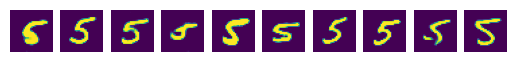

Lambda:  0.9999 | Embedding Dim:  2
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6625 | Reconstruction Loss: 0.6539 | KLD Loss: 86.3025
Epoch 50 | Total Loss: 0.4708 | Reconstruction Loss: 0.4697 | KLD Loss: 11.4153
Epoch 100 | Total Loss: 0.4648 | Reconstruction Loss: 0.4638 | KLD Loss: 10.8626
Epoch 150 | Total Loss: 0.4623 | Reconstruction Loss: 0.4612 | KLD Loss: 10.9240
Epoch 200 | Total Loss: 0.4608 | Reconstruction Loss: 0.4598 | KLD Loss: 10.8433
Epoch 250 | Total Loss: 0.4595 | Reconstruction Loss: 0.4584 | KLD Loss: 11.1822
Epoch 299 | Total Loss: 0.4581 | Reconstruction Loss: 0.4570 | KLD Loss: 11.2597


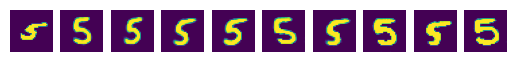

Lambda:  0.9999 | Embedding Dim:  10
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6719 | Reconstruction Loss: 0.6587 | KLD Loss: 133.3088
Epoch 50 | Total Loss: 0.3881 | Reconstruction Loss: 0.3845 | KLD Loss: 36.2052
Epoch 100 | Total Loss: 0.3838 | Reconstruction Loss: 0.3803 | KLD Loss: 35.1620
Epoch 150 | Total Loss: 0.3814 | Reconstruction Loss: 0.3780 | KLD Loss: 35.0641
Epoch 200 | Total Loss: 0.3801 | Reconstruction Loss: 0.3766 | KLD Loss: 35.1830
Epoch 250 | Total Loss: 0.3787 | Reconstruction Loss: 0.3753 | KLD Loss: 35.0121
Epoch 299 | Total Loss: 0.3785 | Reconstruction Loss: 0.3750 | KLD Loss: 35.1184


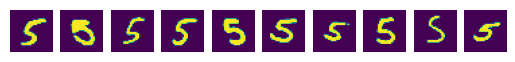

Lambda:  0.9999 | Embedding Dim:  100
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6659 | Reconstruction Loss: 0.6484 | KLD Loss: 176.1780
Epoch 50 | Total Loss: 0.3736 | Reconstruction Loss: 0.3637 | KLD Loss: 98.5795
Epoch 100 | Total Loss: 0.3691 | Reconstruction Loss: 0.3600 | KLD Loss: 90.6845
Epoch 150 | Total Loss: 0.3672 | Reconstruction Loss: 0.3585 | KLD Loss: 87.0536
Epoch 200 | Total Loss: 0.3661 | Reconstruction Loss: 0.3576 | KLD Loss: 86.1999
Epoch 250 | Total Loss: 0.3652 | Reconstruction Loss: 0.3568 | KLD Loss: 84.7308
Epoch 299 | Total Loss: 0.3648 | Reconstruction Loss: 0.3564 | KLD Loss: 84.1922


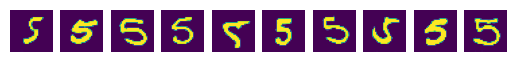

Lambda:  0.9999 | Embedding Dim:  1000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6356 | Reconstruction Loss: 0.6123 | KLD Loss: 233.5659
Epoch 50 | Total Loss: 0.3829 | Reconstruction Loss: 0.3704 | KLD Loss: 124.8508
Epoch 100 | Total Loss: 0.3741 | Reconstruction Loss: 0.3640 | KLD Loss: 100.9525
Epoch 150 | Total Loss: 0.3710 | Reconstruction Loss: 0.3616 | KLD Loss: 94.0933
Epoch 200 | Total Loss: 0.3692 | Reconstruction Loss: 0.3601 | KLD Loss: 91.0565
Epoch 250 | Total Loss: 0.3680 | Reconstruction Loss: 0.3591 | KLD Loss: 89.0219
Epoch 299 | Total Loss: 0.3672 | Reconstruction Loss: 0.3584 | KLD Loss: 87.7261


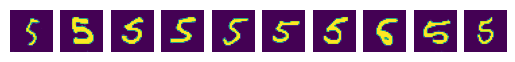

Lambda:  0.9999 | Embedding Dim:  2000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6550 | Reconstruction Loss: 0.6230 | KLD Loss: 321.2459
Epoch 50 | Total Loss: 0.3905 | Reconstruction Loss: 0.3763 | KLD Loss: 142.4820
Epoch 100 | Total Loss: 0.3849 | Reconstruction Loss: 0.3713 | KLD Loss: 136.4651
Epoch 150 | Total Loss: 0.3782 | Reconstruction Loss: 0.3663 | KLD Loss: 119.7682
Epoch 200 | Total Loss: 0.3738 | Reconstruction Loss: 0.3633 | KLD Loss: 105.2396
Epoch 250 | Total Loss: 0.3714 | Reconstruction Loss: 0.3615 | KLD Loss: 98.8270
Epoch 299 | Total Loss: 0.3697 | Reconstruction Loss: 0.3603 | KLD Loss: 94.7048


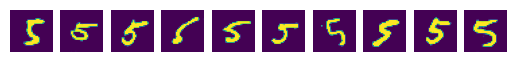

Lambda:  0.9999 | Embedding Dim:  4000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6880 | Reconstruction Loss: 0.6369 | KLD Loss: 511.4707
Epoch 50 | Total Loss: 0.3920 | Reconstruction Loss: 0.3774 | KLD Loss: 146.4513
Epoch 100 | Total Loss: 0.3876 | Reconstruction Loss: 0.3734 | KLD Loss: 142.0286
Epoch 150 | Total Loss: 0.3854 | Reconstruction Loss: 0.3714 | KLD Loss: 140.5684
Epoch 200 | Total Loss: 0.3839 | Reconstruction Loss: 0.3699 | KLD Loss: 139.8605
Epoch 250 | Total Loss: 0.3821 | Reconstruction Loss: 0.3685 | KLD Loss: 136.5424
Epoch 299 | Total Loss: 0.3810 | Reconstruction Loss: 0.3677 | KLD Loss: 133.5482


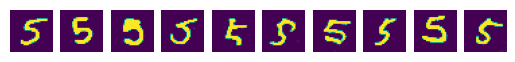

Classe:  6 

Lambda:  0.9 | Embedding Dim:  2
---------------------------------------------------------
Epoch 0 | Total Loss: 0.7358 | Reconstruction Loss: 0.7741 | KLD Loss: 0.3910
Epoch 50 | Total Loss: 0.5008 | Reconstruction Loss: 0.5564 | KLD Loss: 0.0006
Epoch 100 | Total Loss: 0.5006 | Reconstruction Loss: 0.5562 | KLD Loss: 0.0001
Epoch 150 | Total Loss: 0.5005 | Reconstruction Loss: 0.5561 | KLD Loss: 0.0001
Epoch 200 | Total Loss: 0.5004 | Reconstruction Loss: 0.5560 | KLD Loss: 0.0000
Epoch 250 | Total Loss: 0.5004 | Reconstruction Loss: 0.5559 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.5003 | Reconstruction Loss: 0.5559 | KLD Loss: 0.0000


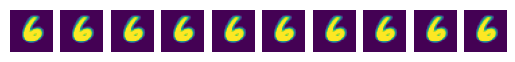

Lambda:  0.9 | Embedding Dim:  10
---------------------------------------------------------
Epoch 0 | Total Loss: 0.8496 | Reconstruction Loss: 0.8222 | KLD Loss: 1.0966
Epoch 50 | Total Loss: 0.5007 | Reconstruction Loss: 0.5562 | KLD Loss: 0.0014
Epoch 100 | Total Loss: 0.5006 | Reconstruction Loss: 0.5562 | KLD Loss: 0.0004
Epoch 150 | Total Loss: 0.5004 | Reconstruction Loss: 0.5560 | KLD Loss: 0.0003
Epoch 200 | Total Loss: 0.5004 | Reconstruction Loss: 0.5560 | KLD Loss: 0.0000
Epoch 250 | Total Loss: 0.5004 | Reconstruction Loss: 0.5560 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.5003 | Reconstruction Loss: 0.5559 | KLD Loss: 0.0000


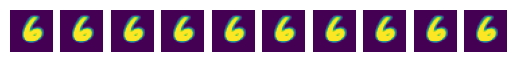

Lambda:  0.9 | Embedding Dim:  100
---------------------------------------------------------
Epoch 0 | Total Loss: 1.5398 | Reconstruction Loss: 0.8422 | KLD Loss: 7.8179
Epoch 50 | Total Loss: 0.5010 | Reconstruction Loss: 0.5565 | KLD Loss: 0.0012
Epoch 100 | Total Loss: 0.5007 | Reconstruction Loss: 0.5563 | KLD Loss: 0.0003
Epoch 150 | Total Loss: 0.5005 | Reconstruction Loss: 0.5561 | KLD Loss: 0.0001
Epoch 200 | Total Loss: 0.5004 | Reconstruction Loss: 0.5560 | KLD Loss: 0.0001
Epoch 250 | Total Loss: 0.5005 | Reconstruction Loss: 0.5561 | KLD Loss: 0.0001
Epoch 299 | Total Loss: 0.5004 | Reconstruction Loss: 0.5560 | KLD Loss: 0.0000


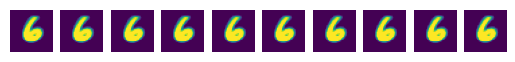

Lambda:  0.9 | Embedding Dim:  1000
---------------------------------------------------------
Epoch 0 | Total Loss: 7.1513 | Reconstruction Loss: 0.8557 | KLD Loss: 63.8119
Epoch 50 | Total Loss: 0.5022 | Reconstruction Loss: 0.5575 | KLD Loss: 0.0046
Epoch 100 | Total Loss: 0.5009 | Reconstruction Loss: 0.5564 | KLD Loss: 0.0008
Epoch 150 | Total Loss: 0.5007 | Reconstruction Loss: 0.5562 | KLD Loss: 0.0007
Epoch 200 | Total Loss: 0.5006 | Reconstruction Loss: 0.5562 | KLD Loss: 0.0000
Epoch 250 | Total Loss: 0.5005 | Reconstruction Loss: 0.5561 | KLD Loss: 0.0001
Epoch 299 | Total Loss: 0.5004 | Reconstruction Loss: 0.5560 | KLD Loss: 0.0000


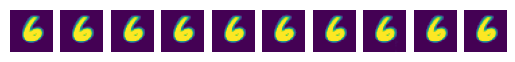

Lambda:  0.9 | Embedding Dim:  2000
---------------------------------------------------------
Epoch 0 | Total Loss: 12.9305 | Reconstruction Loss: 0.8535 | KLD Loss: 121.6236
Epoch 50 | Total Loss: 0.5026 | Reconstruction Loss: 0.5578 | KLD Loss: 0.0058
Epoch 100 | Total Loss: 0.5011 | Reconstruction Loss: 0.5566 | KLD Loss: 0.0014
Epoch 150 | Total Loss: 0.5007 | Reconstruction Loss: 0.5563 | KLD Loss: 0.0001
Epoch 200 | Total Loss: 0.5006 | Reconstruction Loss: 0.5562 | KLD Loss: 0.0001
Epoch 250 | Total Loss: 0.5005 | Reconstruction Loss: 0.5561 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.5005 | Reconstruction Loss: 0.5561 | KLD Loss: 0.0000


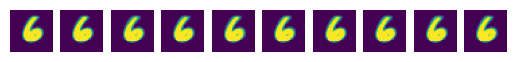

Lambda:  0.9 | Embedding Dim:  4000
---------------------------------------------------------
Epoch 0 | Total Loss: 26.3318 | Reconstruction Loss: 0.8344 | KLD Loss: 255.8088
Epoch 50 | Total Loss: 0.5039 | Reconstruction Loss: 0.5586 | KLD Loss: 0.0118
Epoch 100 | Total Loss: 0.5017 | Reconstruction Loss: 0.5570 | KLD Loss: 0.0033
Epoch 150 | Total Loss: 0.5009 | Reconstruction Loss: 0.5565 | KLD Loss: 0.0001
Epoch 200 | Total Loss: 0.5007 | Reconstruction Loss: 0.5564 | KLD Loss: 0.0001
Epoch 250 | Total Loss: 0.5006 | Reconstruction Loss: 0.5562 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.5006 | Reconstruction Loss: 0.5562 | KLD Loss: 0.0000


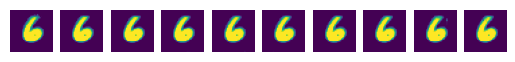

Lambda:  0.99 | Embedding Dim:  2
---------------------------------------------------------
Epoch 0 | Total Loss: 0.7495 | Reconstruction Loss: 0.7332 | KLD Loss: 2.3620
Epoch 50 | Total Loss: 0.4954 | Reconstruction Loss: 0.4750 | KLD Loss: 2.5224
Epoch 100 | Total Loss: 0.4948 | Reconstruction Loss: 0.4744 | KLD Loss: 2.5177
Epoch 150 | Total Loss: 0.4943 | Reconstruction Loss: 0.4737 | KLD Loss: 2.5331
Epoch 200 | Total Loss: 0.4940 | Reconstruction Loss: 0.4733 | KLD Loss: 2.5496
Epoch 250 | Total Loss: 0.4940 | Reconstruction Loss: 0.4727 | KLD Loss: 2.5973
Epoch 299 | Total Loss: 0.4933 | Reconstruction Loss: 0.4724 | KLD Loss: 2.5623


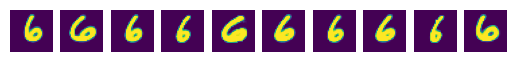

Lambda:  0.99 | Embedding Dim:  10
---------------------------------------------------------
Epoch 0 | Total Loss: 0.7838 | Reconstruction Loss: 0.7730 | KLD Loss: 1.8511
Epoch 50 | Total Loss: 0.4872 | Reconstruction Loss: 0.4505 | KLD Loss: 4.1148
Epoch 100 | Total Loss: 0.4850 | Reconstruction Loss: 0.4487 | KLD Loss: 4.0782
Epoch 150 | Total Loss: 0.4849 | Reconstruction Loss: 0.4476 | KLD Loss: 4.1740
Epoch 200 | Total Loss: 0.4842 | Reconstruction Loss: 0.4469 | KLD Loss: 4.1792
Epoch 250 | Total Loss: 0.4838 | Reconstruction Loss: 0.4462 | KLD Loss: 4.2063
Epoch 299 | Total Loss: 0.4830 | Reconstruction Loss: 0.4457 | KLD Loss: 4.1770


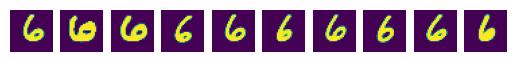

Lambda:  0.99 | Embedding Dim:  100
---------------------------------------------------------
Epoch 0 | Total Loss: 0.9034 | Reconstruction Loss: 0.8159 | KLD Loss: 9.5706
Epoch 50 | Total Loss: 0.4896 | Reconstruction Loss: 0.4561 | KLD Loss: 3.8099
Epoch 100 | Total Loss: 0.4873 | Reconstruction Loss: 0.4527 | KLD Loss: 3.9164
Epoch 150 | Total Loss: 0.4863 | Reconstruction Loss: 0.4511 | KLD Loss: 3.9721
Epoch 200 | Total Loss: 0.4852 | Reconstruction Loss: 0.4487 | KLD Loss: 4.0996
Epoch 250 | Total Loss: 0.4853 | Reconstruction Loss: 0.4482 | KLD Loss: 4.1614
Epoch 299 | Total Loss: 0.4849 | Reconstruction Loss: 0.4475 | KLD Loss: 4.1929


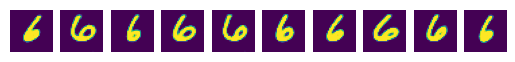

Lambda:  0.99 | Embedding Dim:  1000
---------------------------------------------------------
Epoch 0 | Total Loss: 1.4464 | Reconstruction Loss: 0.8236 | KLD Loss: 63.0966
Epoch 50 | Total Loss: 0.5188 | Reconstruction Loss: 0.4950 | KLD Loss: 2.8754
Epoch 100 | Total Loss: 0.5159 | Reconstruction Loss: 0.4909 | KLD Loss: 2.9838
Epoch 150 | Total Loss: 0.5152 | Reconstruction Loss: 0.4892 | KLD Loss: 3.0901
Epoch 200 | Total Loss: 0.5158 | Reconstruction Loss: 0.4897 | KLD Loss: 3.1000
Epoch 250 | Total Loss: 0.5144 | Reconstruction Loss: 0.4883 | KLD Loss: 3.0945
Epoch 299 | Total Loss: 0.5127 | Reconstruction Loss: 0.4866 | KLD Loss: 3.0901


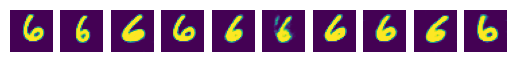

Lambda:  0.99 | Embedding Dim:  2000
---------------------------------------------------------
Epoch 0 | Total Loss: 2.0277 | Reconstruction Loss: 0.7970 | KLD Loss: 123.8719
Epoch 50 | Total Loss: 0.5190 | Reconstruction Loss: 0.4963 | KLD Loss: 2.7702
Epoch 100 | Total Loss: 0.5174 | Reconstruction Loss: 0.4930 | KLD Loss: 2.9332
Epoch 150 | Total Loss: 0.5161 | Reconstruction Loss: 0.4912 | KLD Loss: 2.9792
Epoch 200 | Total Loss: 0.5163 | Reconstruction Loss: 0.4906 | KLD Loss: 3.0562
Epoch 250 | Total Loss: 0.5152 | Reconstruction Loss: 0.4901 | KLD Loss: 2.9939
Epoch 299 | Total Loss: 0.5144 | Reconstruction Loss: 0.4891 | KLD Loss: 3.0156


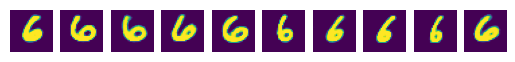

Lambda:  0.99 | Embedding Dim:  4000
---------------------------------------------------------
Epoch 0 | Total Loss: 3.3620 | Reconstruction Loss: 0.8055 | KLD Loss: 256.4511
Epoch 50 | Total Loss: 0.5240 | Reconstruction Loss: 0.5007 | KLD Loss: 2.8300
Epoch 100 | Total Loss: 0.5194 | Reconstruction Loss: 0.4953 | KLD Loss: 2.9125
Epoch 150 | Total Loss: 0.5171 | Reconstruction Loss: 0.4931 | KLD Loss: 2.8946
Epoch 200 | Total Loss: 0.5172 | Reconstruction Loss: 0.4924 | KLD Loss: 2.9649
Epoch 250 | Total Loss: 0.5168 | Reconstruction Loss: 0.4918 | KLD Loss: 2.9892
Epoch 299 | Total Loss: 0.5154 | Reconstruction Loss: 0.4906 | KLD Loss: 2.9661


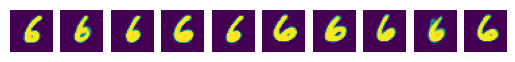

Lambda:  0.999 | Embedding Dim:  2
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6521 | Reconstruction Loss: 0.6310 | KLD Loss: 21.7618
Epoch 50 | Total Loss: 0.4678 | Reconstruction Loss: 0.4629 | KLD Loss: 5.3265
Epoch 100 | Total Loss: 0.4664 | Reconstruction Loss: 0.4614 | KLD Loss: 5.4150
Epoch 150 | Total Loss: 0.4642 | Reconstruction Loss: 0.4590 | KLD Loss: 5.6663
Epoch 200 | Total Loss: 0.4624 | Reconstruction Loss: 0.4569 | KLD Loss: 6.0168
Epoch 250 | Total Loss: 0.4614 | Reconstruction Loss: 0.4557 | KLD Loss: 6.1388
Epoch 299 | Total Loss: 0.4598 | Reconstruction Loss: 0.4540 | KLD Loss: 6.2667


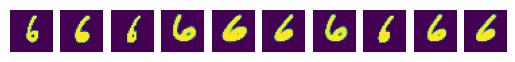

Lambda:  0.999 | Embedding Dim:  10
---------------------------------------------------------
Epoch 0 | Total Loss: 0.7328 | Reconstruction Loss: 0.7052 | KLD Loss: 28.2889
Epoch 50 | Total Loss: 0.4214 | Reconstruction Loss: 0.4040 | KLD Loss: 17.8154
Epoch 100 | Total Loss: 0.4143 | Reconstruction Loss: 0.3965 | KLD Loss: 18.1788
Epoch 150 | Total Loss: 0.4128 | Reconstruction Loss: 0.3949 | KLD Loss: 18.2890
Epoch 200 | Total Loss: 0.4118 | Reconstruction Loss: 0.3941 | KLD Loss: 18.1209
Epoch 250 | Total Loss: 0.4111 | Reconstruction Loss: 0.3934 | KLD Loss: 18.1083
Epoch 299 | Total Loss: 0.4107 | Reconstruction Loss: 0.3928 | KLD Loss: 18.2689


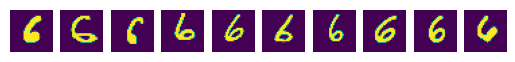

Lambda:  0.999 | Embedding Dim:  100
---------------------------------------------------------
Epoch 0 | Total Loss: 0.7691 | Reconstruction Loss: 0.7425 | KLD Loss: 27.2497
Epoch 50 | Total Loss: 0.4209 | Reconstruction Loss: 0.4018 | KLD Loss: 19.5199
Epoch 100 | Total Loss: 0.4164 | Reconstruction Loss: 0.3971 | KLD Loss: 19.6770
Epoch 150 | Total Loss: 0.4146 | Reconstruction Loss: 0.3955 | KLD Loss: 19.5291
Epoch 200 | Total Loss: 0.4135 | Reconstruction Loss: 0.3946 | KLD Loss: 19.3271
Epoch 250 | Total Loss: 0.4128 | Reconstruction Loss: 0.3937 | KLD Loss: 19.5133
Epoch 299 | Total Loss: 0.4121 | Reconstruction Loss: 0.3932 | KLD Loss: 19.3474


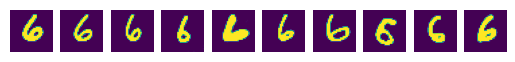

Lambda:  0.999 | Embedding Dim:  1000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.8451 | Reconstruction Loss: 0.7546 | KLD Loss: 91.1823
Epoch 50 | Total Loss: 0.4484 | Reconstruction Loss: 0.4234 | KLD Loss: 25.4074
Epoch 100 | Total Loss: 0.4282 | Reconstruction Loss: 0.4069 | KLD Loss: 21.7122
Epoch 150 | Total Loss: 0.4206 | Reconstruction Loss: 0.4006 | KLD Loss: 20.4234
Epoch 200 | Total Loss: 0.4179 | Reconstruction Loss: 0.3979 | KLD Loss: 20.3126
Epoch 250 | Total Loss: 0.4163 | Reconstruction Loss: 0.3965 | KLD Loss: 20.1803
Epoch 299 | Total Loss: 0.4154 | Reconstruction Loss: 0.3956 | KLD Loss: 20.1576


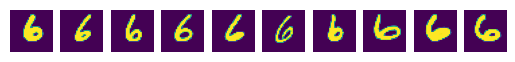

Lambda:  0.999 | Embedding Dim:  2000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.8521 | Reconstruction Loss: 0.7109 | KLD Loss: 141.9211
Epoch 50 | Total Loss: 0.4508 | Reconstruction Loss: 0.4254 | KLD Loss: 25.8441
Epoch 100 | Total Loss: 0.4468 | Reconstruction Loss: 0.4211 | KLD Loss: 26.1305
Epoch 150 | Total Loss: 0.4446 | Reconstruction Loss: 0.4189 | KLD Loss: 26.1797
Epoch 200 | Total Loss: 0.4416 | Reconstruction Loss: 0.4165 | KLD Loss: 25.4830
Epoch 250 | Total Loss: 0.4390 | Reconstruction Loss: 0.4146 | KLD Loss: 24.8185
Epoch 299 | Total Loss: 0.4380 | Reconstruction Loss: 0.4140 | KLD Loss: 24.4811


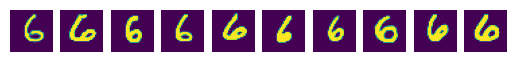

Lambda:  0.999 | Embedding Dim:  4000
---------------------------------------------------------
Epoch 0 | Total Loss: 1.0070 | Reconstruction Loss: 0.7050 | KLD Loss: 302.6976
Epoch 50 | Total Loss: 0.4526 | Reconstruction Loss: 0.4269 | KLD Loss: 26.1371
Epoch 100 | Total Loss: 0.4484 | Reconstruction Loss: 0.4222 | KLD Loss: 26.6183
Epoch 150 | Total Loss: 0.4459 | Reconstruction Loss: 0.4195 | KLD Loss: 26.8264
Epoch 200 | Total Loss: 0.4445 | Reconstruction Loss: 0.4181 | KLD Loss: 26.7971
Epoch 250 | Total Loss: 0.4438 | Reconstruction Loss: 0.4176 | KLD Loss: 26.6233
Epoch 299 | Total Loss: 0.4430 | Reconstruction Loss: 0.4170 | KLD Loss: 26.3528


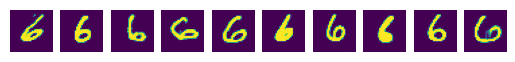

Lambda:  0.9999 | Embedding Dim:  2
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6727 | Reconstruction Loss: 0.6614 | KLD Loss: 114.1502
Epoch 50 | Total Loss: 0.4639 | Reconstruction Loss: 0.4630 | KLD Loss: 9.4625
Epoch 100 | Total Loss: 0.4618 | Reconstruction Loss: 0.4610 | KLD Loss: 8.9100
Epoch 150 | Total Loss: 0.4602 | Reconstruction Loss: 0.4593 | KLD Loss: 9.3357
Epoch 200 | Total Loss: 0.4573 | Reconstruction Loss: 0.4563 | KLD Loss: 10.0331
Epoch 250 | Total Loss: 0.4553 | Reconstruction Loss: 0.4543 | KLD Loss: 10.4510
Epoch 299 | Total Loss: 0.4541 | Reconstruction Loss: 0.4531 | KLD Loss: 10.5028


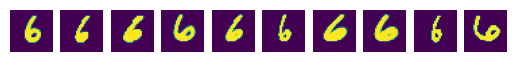

Lambda:  0.9999 | Embedding Dim:  10
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6660 | Reconstruction Loss: 0.6485 | KLD Loss: 174.7840
Epoch 50 | Total Loss: 0.4100 | Reconstruction Loss: 0.4067 | KLD Loss: 33.3599
Epoch 100 | Total Loss: 0.3948 | Reconstruction Loss: 0.3915 | KLD Loss: 33.1982
Epoch 150 | Total Loss: 0.3928 | Reconstruction Loss: 0.3896 | KLD Loss: 33.1501
Epoch 200 | Total Loss: 0.3917 | Reconstruction Loss: 0.3884 | KLD Loss: 33.4045
Epoch 250 | Total Loss: 0.3910 | Reconstruction Loss: 0.3877 | KLD Loss: 33.3267
Epoch 299 | Total Loss: 0.3902 | Reconstruction Loss: 0.3869 | KLD Loss: 33.0768


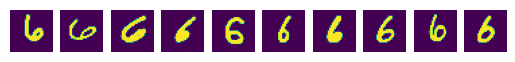

Lambda:  0.9999 | Embedding Dim:  100
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6540 | Reconstruction Loss: 0.6349 | KLD Loss: 191.6329
Epoch 50 | Total Loss: 0.3927 | Reconstruction Loss: 0.3848 | KLD Loss: 79.3837
Epoch 100 | Total Loss: 0.3888 | Reconstruction Loss: 0.3816 | KLD Loss: 71.7372
Epoch 150 | Total Loss: 0.3873 | Reconstruction Loss: 0.3804 | KLD Loss: 69.6382
Epoch 200 | Total Loss: 0.3864 | Reconstruction Loss: 0.3796 | KLD Loss: 68.6277
Epoch 250 | Total Loss: 0.3858 | Reconstruction Loss: 0.3790 | KLD Loss: 67.6223
Epoch 299 | Total Loss: 0.3852 | Reconstruction Loss: 0.3786 | KLD Loss: 67.1623


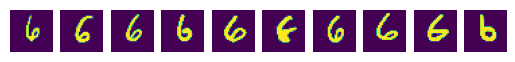

Lambda:  0.9999 | Embedding Dim:  1000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6241 | Reconstruction Loss: 0.5999 | KLD Loss: 243.1213
Epoch 50 | Total Loss: 0.4001 | Reconstruction Loss: 0.3903 | KLD Loss: 98.2960
Epoch 100 | Total Loss: 0.3927 | Reconstruction Loss: 0.3848 | KLD Loss: 79.3225
Epoch 150 | Total Loss: 0.3902 | Reconstruction Loss: 0.3828 | KLD Loss: 74.4907
Epoch 200 | Total Loss: 0.3889 | Reconstruction Loss: 0.3818 | KLD Loss: 72.0935
Epoch 250 | Total Loss: 0.3879 | Reconstruction Loss: 0.3809 | KLD Loss: 70.5886
Epoch 299 | Total Loss: 0.3872 | Reconstruction Loss: 0.3803 | KLD Loss: 69.3017


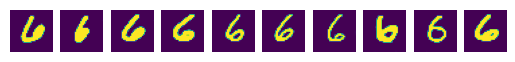

Lambda:  0.9999 | Embedding Dim:  2000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6702 | Reconstruction Loss: 0.6308 | KLD Loss: 394.1686
Epoch 50 | Total Loss: 0.4071 | Reconstruction Loss: 0.3955 | KLD Loss: 115.7433
Epoch 100 | Total Loss: 0.3993 | Reconstruction Loss: 0.3893 | KLD Loss: 100.5008
Epoch 150 | Total Loss: 0.3937 | Reconstruction Loss: 0.3853 | KLD Loss: 84.0732
Epoch 200 | Total Loss: 0.3911 | Reconstruction Loss: 0.3835 | KLD Loss: 76.6091
Epoch 250 | Total Loss: 0.3896 | Reconstruction Loss: 0.3823 | KLD Loss: 73.2688
Epoch 299 | Total Loss: 0.3885 | Reconstruction Loss: 0.3815 | KLD Loss: 70.8207


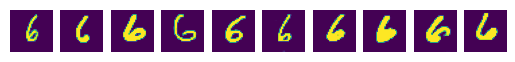

Lambda:  0.9999 | Embedding Dim:  4000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6927 | Reconstruction Loss: 0.6338 | KLD Loss: 589.6778
Epoch 50 | Total Loss: 0.4082 | Reconstruction Loss: 0.3964 | KLD Loss: 117.9010
Epoch 100 | Total Loss: 0.4044 | Reconstruction Loss: 0.3930 | KLD Loss: 114.5908
Epoch 150 | Total Loss: 0.4025 | Reconstruction Loss: 0.3911 | KLD Loss: 114.2331
Epoch 200 | Total Loss: 0.4011 | Reconstruction Loss: 0.3899 | KLD Loss: 112.2676
Epoch 250 | Total Loss: 0.3999 | Reconstruction Loss: 0.3889 | KLD Loss: 110.8161
Epoch 299 | Total Loss: 0.3985 | Reconstruction Loss: 0.3877 | KLD Loss: 107.8761


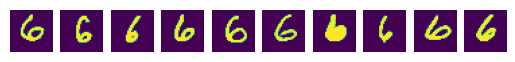

Classe:  7 

Lambda:  0.9 | Embedding Dim:  2
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6486 | Reconstruction Loss: 0.6904 | KLD Loss: 0.2728
Epoch 50 | Total Loss: 0.4481 | Reconstruction Loss: 0.4978 | KLD Loss: 0.0005
Epoch 100 | Total Loss: 0.4479 | Reconstruction Loss: 0.4976 | KLD Loss: 0.0002
Epoch 150 | Total Loss: 0.4478 | Reconstruction Loss: 0.4975 | KLD Loss: 0.0000
Epoch 200 | Total Loss: 0.4477 | Reconstruction Loss: 0.4974 | KLD Loss: 0.0000
Epoch 250 | Total Loss: 0.4477 | Reconstruction Loss: 0.4974 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.4476 | Reconstruction Loss: 0.4974 | KLD Loss: 0.0000


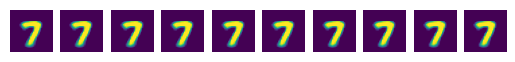

Lambda:  0.9 | Embedding Dim:  10
---------------------------------------------------------
Epoch 0 | Total Loss: 0.7421 | Reconstruction Loss: 0.7085 | KLD Loss: 1.0445
Epoch 50 | Total Loss: 0.4481 | Reconstruction Loss: 0.4977 | KLD Loss: 0.0010
Epoch 100 | Total Loss: 0.4479 | Reconstruction Loss: 0.4976 | KLD Loss: 0.0002
Epoch 150 | Total Loss: 0.4477 | Reconstruction Loss: 0.4975 | KLD Loss: 0.0001
Epoch 200 | Total Loss: 0.4477 | Reconstruction Loss: 0.4974 | KLD Loss: 0.0000
Epoch 250 | Total Loss: 0.4477 | Reconstruction Loss: 0.4974 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.4477 | Reconstruction Loss: 0.4974 | KLD Loss: 0.0000


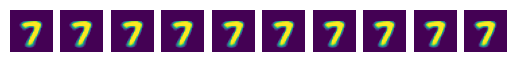

Lambda:  0.9 | Embedding Dim:  100
---------------------------------------------------------
Epoch 0 | Total Loss: 1.3842 | Reconstruction Loss: 0.7705 | KLD Loss: 6.9074
Epoch 50 | Total Loss: 0.4482 | Reconstruction Loss: 0.4978 | KLD Loss: 0.0013
Epoch 100 | Total Loss: 0.4479 | Reconstruction Loss: 0.4976 | KLD Loss: 0.0003
Epoch 150 | Total Loss: 0.4478 | Reconstruction Loss: 0.4976 | KLD Loss: 0.0001
Epoch 200 | Total Loss: 0.4477 | Reconstruction Loss: 0.4975 | KLD Loss: 0.0001
Epoch 250 | Total Loss: 0.4477 | Reconstruction Loss: 0.4975 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.4477 | Reconstruction Loss: 0.4975 | KLD Loss: 0.0000


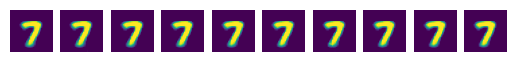

Lambda:  0.9 | Embedding Dim:  1000
---------------------------------------------------------
Epoch 0 | Total Loss: 6.8094 | Reconstruction Loss: 0.7793 | KLD Loss: 61.0799
Epoch 50 | Total Loss: 0.4487 | Reconstruction Loss: 0.4983 | KLD Loss: 0.0026
Epoch 100 | Total Loss: 0.4483 | Reconstruction Loss: 0.4980 | KLD Loss: 0.0012
Epoch 150 | Total Loss: 0.4479 | Reconstruction Loss: 0.4977 | KLD Loss: 0.0001
Epoch 200 | Total Loss: 0.4479 | Reconstruction Loss: 0.4976 | KLD Loss: 0.0000
Epoch 250 | Total Loss: 0.4478 | Reconstruction Loss: 0.4976 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.4478 | Reconstruction Loss: 0.4975 | KLD Loss: 0.0000


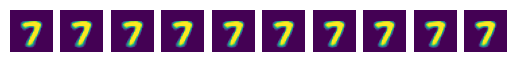

Lambda:  0.9 | Embedding Dim:  2000
---------------------------------------------------------
Epoch 0 | Total Loss: 12.5406 | Reconstruction Loss: 0.7677 | KLD Loss: 118.4970
Epoch 50 | Total Loss: 0.4495 | Reconstruction Loss: 0.4985 | KLD Loss: 0.0081
Epoch 100 | Total Loss: 0.4483 | Reconstruction Loss: 0.4981 | KLD Loss: 0.0008
Epoch 150 | Total Loss: 0.4481 | Reconstruction Loss: 0.4979 | KLD Loss: 0.0002
Epoch 200 | Total Loss: 0.4480 | Reconstruction Loss: 0.4978 | KLD Loss: 0.0000
Epoch 250 | Total Loss: 0.4478 | Reconstruction Loss: 0.4976 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.4478 | Reconstruction Loss: 0.4976 | KLD Loss: 0.0000


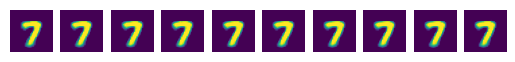

Lambda:  0.9 | Embedding Dim:  4000
---------------------------------------------------------
Epoch 0 | Total Loss: 23.5584 | Reconstruction Loss: 0.7319 | KLD Loss: 228.9973
Epoch 50 | Total Loss: 0.4505 | Reconstruction Loss: 0.4997 | KLD Loss: 0.0072
Epoch 100 | Total Loss: 0.4488 | Reconstruction Loss: 0.4986 | KLD Loss: 0.0013
Epoch 150 | Total Loss: 0.4482 | Reconstruction Loss: 0.4980 | KLD Loss: 0.0001
Epoch 200 | Total Loss: 0.4480 | Reconstruction Loss: 0.4978 | KLD Loss: 0.0001
Epoch 250 | Total Loss: 0.4480 | Reconstruction Loss: 0.4977 | KLD Loss: 0.0001
Epoch 299 | Total Loss: 0.4479 | Reconstruction Loss: 0.4976 | KLD Loss: 0.0000


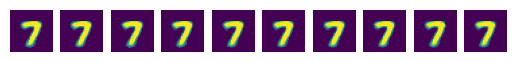

Lambda:  0.99 | Embedding Dim:  2
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6936 | Reconstruction Loss: 0.6782 | KLD Loss: 2.2164
Epoch 50 | Total Loss: 0.4481 | Reconstruction Loss: 0.4281 | KLD Loss: 2.4277
Epoch 100 | Total Loss: 0.4476 | Reconstruction Loss: 0.4273 | KLD Loss: 2.4551
Epoch 150 | Total Loss: 0.4474 | Reconstruction Loss: 0.4266 | KLD Loss: 2.5106
Epoch 200 | Total Loss: 0.4465 | Reconstruction Loss: 0.4257 | KLD Loss: 2.4996
Epoch 250 | Total Loss: 0.4466 | Reconstruction Loss: 0.4252 | KLD Loss: 2.5656
Epoch 299 | Total Loss: 0.4461 | Reconstruction Loss: 0.4249 | KLD Loss: 2.5452


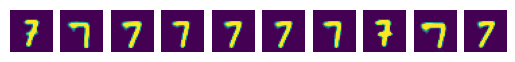

Lambda:  0.99 | Embedding Dim:  10
---------------------------------------------------------
Epoch 0 | Total Loss: 0.7400 | Reconstruction Loss: 0.7232 | KLD Loss: 2.4071
Epoch 50 | Total Loss: 0.4419 | Reconstruction Loss: 0.4074 | KLD Loss: 3.8583
Epoch 100 | Total Loss: 0.4411 | Reconstruction Loss: 0.4059 | KLD Loss: 3.9180
Epoch 150 | Total Loss: 0.4396 | Reconstruction Loss: 0.4041 | KLD Loss: 3.9569
Epoch 200 | Total Loss: 0.4396 | Reconstruction Loss: 0.4038 | KLD Loss: 3.9834
Epoch 250 | Total Loss: 0.4392 | Reconstruction Loss: 0.4030 | KLD Loss: 4.0250
Epoch 299 | Total Loss: 0.4395 | Reconstruction Loss: 0.4027 | KLD Loss: 4.0779


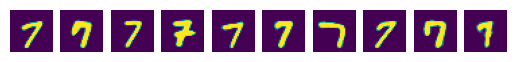

Lambda:  0.99 | Embedding Dim:  100
---------------------------------------------------------
Epoch 0 | Total Loss: 0.8076 | Reconstruction Loss: 0.7338 | KLD Loss: 8.1148
Epoch 50 | Total Loss: 0.4452 | Reconstruction Loss: 0.4159 | KLD Loss: 3.3440
Epoch 100 | Total Loss: 0.4438 | Reconstruction Loss: 0.4129 | KLD Loss: 3.5013
Epoch 150 | Total Loss: 0.4427 | Reconstruction Loss: 0.4115 | KLD Loss: 3.5218
Epoch 200 | Total Loss: 0.4415 | Reconstruction Loss: 0.4085 | KLD Loss: 3.7060
Epoch 250 | Total Loss: 0.4408 | Reconstruction Loss: 0.4072 | KLD Loss: 3.7644
Epoch 299 | Total Loss: 0.4407 | Reconstruction Loss: 0.4071 | KLD Loss: 3.7737


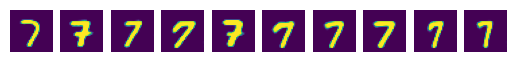

Lambda:  0.99 | Embedding Dim:  1000
---------------------------------------------------------
Epoch 0 | Total Loss: 1.3815 | Reconstruction Loss: 0.7716 | KLD Loss: 61.7605
Epoch 50 | Total Loss: 0.4673 | Reconstruction Loss: 0.4457 | KLD Loss: 2.6040
Epoch 100 | Total Loss: 0.4667 | Reconstruction Loss: 0.4440 | KLD Loss: 2.7149
Epoch 150 | Total Loss: 0.4654 | Reconstruction Loss: 0.4420 | KLD Loss: 2.7758
Epoch 200 | Total Loss: 0.4662 | Reconstruction Loss: 0.4426 | KLD Loss: 2.8017
Epoch 250 | Total Loss: 0.4644 | Reconstruction Loss: 0.4413 | KLD Loss: 2.7536
Epoch 299 | Total Loss: 0.4644 | Reconstruction Loss: 0.4415 | KLD Loss: 2.7352


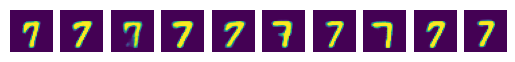

Lambda:  0.99 | Embedding Dim:  2000
---------------------------------------------------------
Epoch 0 | Total Loss: 1.9088 | Reconstruction Loss: 0.7438 | KLD Loss: 117.2459
Epoch 50 | Total Loss: 0.4697 | Reconstruction Loss: 0.4488 | KLD Loss: 2.5339
Epoch 100 | Total Loss: 0.4677 | Reconstruction Loss: 0.4457 | KLD Loss: 2.6394
Epoch 150 | Total Loss: 0.4653 | Reconstruction Loss: 0.4432 | KLD Loss: 2.6505
Epoch 200 | Total Loss: 0.4655 | Reconstruction Loss: 0.4428 | KLD Loss: 2.7085
Epoch 250 | Total Loss: 0.4665 | Reconstruction Loss: 0.4438 | KLD Loss: 2.7142
Epoch 299 | Total Loss: 0.4657 | Reconstruction Loss: 0.4437 | KLD Loss: 2.6413


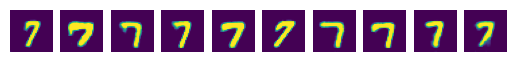

Lambda:  0.99 | Embedding Dim:  4000
---------------------------------------------------------
Epoch 0 | Total Loss: 3.1069 | Reconstruction Loss: 0.7568 | KLD Loss: 235.7611
Epoch 50 | Total Loss: 0.4711 | Reconstruction Loss: 0.4501 | KLD Loss: 2.5576
Epoch 100 | Total Loss: 0.4681 | Reconstruction Loss: 0.4461 | KLD Loss: 2.6408
Epoch 150 | Total Loss: 0.4664 | Reconstruction Loss: 0.4445 | KLD Loss: 2.6303
Epoch 200 | Total Loss: 0.4664 | Reconstruction Loss: 0.4439 | KLD Loss: 2.6892
Epoch 250 | Total Loss: 0.4665 | Reconstruction Loss: 0.4437 | KLD Loss: 2.7253
Epoch 299 | Total Loss: 0.4663 | Reconstruction Loss: 0.4436 | KLD Loss: 2.7083


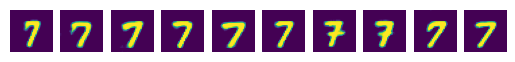

Lambda:  0.999 | Embedding Dim:  2
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6087 | Reconstruction Loss: 0.5879 | KLD Loss: 21.4486
Epoch 50 | Total Loss: 0.4207 | Reconstruction Loss: 0.4157 | KLD Loss: 5.4057
Epoch 100 | Total Loss: 0.4183 | Reconstruction Loss: 0.4131 | KLD Loss: 5.5781
Epoch 150 | Total Loss: 0.4166 | Reconstruction Loss: 0.4112 | KLD Loss: 5.8164
Epoch 200 | Total Loss: 0.4148 | Reconstruction Loss: 0.4092 | KLD Loss: 6.0284
Epoch 250 | Total Loss: 0.4136 | Reconstruction Loss: 0.4079 | KLD Loss: 6.1736
Epoch 299 | Total Loss: 0.4123 | Reconstruction Loss: 0.4064 | KLD Loss: 6.2873


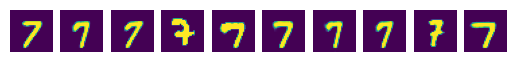

Lambda:  0.999 | Embedding Dim:  10
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6452 | Reconstruction Loss: 0.6206 | KLD Loss: 25.2334
Epoch 50 | Total Loss: 0.3742 | Reconstruction Loss: 0.3571 | KLD Loss: 17.4793
Epoch 100 | Total Loss: 0.3720 | Reconstruction Loss: 0.3546 | KLD Loss: 17.7471
Epoch 150 | Total Loss: 0.3707 | Reconstruction Loss: 0.3533 | KLD Loss: 17.6814
Epoch 200 | Total Loss: 0.3698 | Reconstruction Loss: 0.3525 | KLD Loss: 17.6037
Epoch 250 | Total Loss: 0.3692 | Reconstruction Loss: 0.3519 | KLD Loss: 17.6807
Epoch 299 | Total Loss: 0.3686 | Reconstruction Loss: 0.3512 | KLD Loss: 17.7639


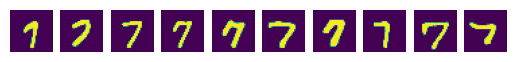

Lambda:  0.999 | Embedding Dim:  100
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6943 | Reconstruction Loss: 0.6669 | KLD Loss: 28.0904
Epoch 50 | Total Loss: 0.3763 | Reconstruction Loss: 0.3570 | KLD Loss: 19.7400
Epoch 100 | Total Loss: 0.3731 | Reconstruction Loss: 0.3537 | KLD Loss: 19.8091
Epoch 150 | Total Loss: 0.3717 | Reconstruction Loss: 0.3524 | KLD Loss: 19.6950
Epoch 200 | Total Loss: 0.3705 | Reconstruction Loss: 0.3513 | KLD Loss: 19.6200
Epoch 250 | Total Loss: 0.3699 | Reconstruction Loss: 0.3507 | KLD Loss: 19.4853
Epoch 299 | Total Loss: 0.3693 | Reconstruction Loss: 0.3502 | KLD Loss: 19.5408


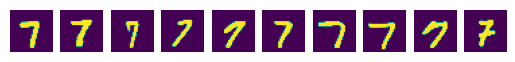

Lambda:  0.999 | Embedding Dim:  1000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.7569 | Reconstruction Loss: 0.6798 | KLD Loss: 77.8176
Epoch 50 | Total Loss: 0.4016 | Reconstruction Loss: 0.3781 | KLD Loss: 23.9059
Epoch 100 | Total Loss: 0.3828 | Reconstruction Loss: 0.3629 | KLD Loss: 20.2374
Epoch 150 | Total Loss: 0.3784 | Reconstruction Loss: 0.3591 | KLD Loss: 19.6756
Epoch 200 | Total Loss: 0.3759 | Reconstruction Loss: 0.3570 | KLD Loss: 19.2710
Epoch 250 | Total Loss: 0.3744 | Reconstruction Loss: 0.3557 | KLD Loss: 19.1045
Epoch 299 | Total Loss: 0.3735 | Reconstruction Loss: 0.3548 | KLD Loss: 18.9884


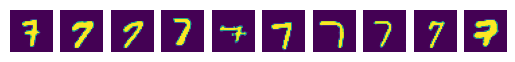

Lambda:  0.999 | Embedding Dim:  2000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.7968 | Reconstruction Loss: 0.6608 | KLD Loss: 136.6124
Epoch 50 | Total Loss: 0.4048 | Reconstruction Loss: 0.3808 | KLD Loss: 24.4091
Epoch 100 | Total Loss: 0.4012 | Reconstruction Loss: 0.3770 | KLD Loss: 24.5914
Epoch 150 | Total Loss: 0.3993 | Reconstruction Loss: 0.3748 | KLD Loss: 24.9386
Epoch 200 | Total Loss: 0.3985 | Reconstruction Loss: 0.3737 | KLD Loss: 25.1370
Epoch 250 | Total Loss: 0.3977 | Reconstruction Loss: 0.3728 | KLD Loss: 25.2910
Epoch 299 | Total Loss: 0.3957 | Reconstruction Loss: 0.3714 | KLD Loss: 24.6813


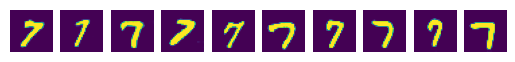

Lambda:  0.999 | Embedding Dim:  4000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.9557 | Reconstruction Loss: 0.6832 | KLD Loss: 273.1448
Epoch 50 | Total Loss: 0.4060 | Reconstruction Loss: 0.3815 | KLD Loss: 24.9053
Epoch 100 | Total Loss: 0.4024 | Reconstruction Loss: 0.3777 | KLD Loss: 25.1392
Epoch 150 | Total Loss: 0.4007 | Reconstruction Loss: 0.3757 | KLD Loss: 25.4048
Epoch 200 | Total Loss: 0.3998 | Reconstruction Loss: 0.3749 | KLD Loss: 25.2660
Epoch 250 | Total Loss: 0.3993 | Reconstruction Loss: 0.3740 | KLD Loss: 25.6690
Epoch 299 | Total Loss: 0.3991 | Reconstruction Loss: 0.3735 | KLD Loss: 25.9625


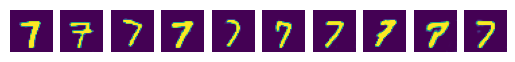

Lambda:  0.9999 | Embedding Dim:  2
---------------------------------------------------------
Epoch 0 | Total Loss: 0.5888 | Reconstruction Loss: 0.5786 | KLD Loss: 102.2802
Epoch 50 | Total Loss: 0.4157 | Reconstruction Loss: 0.4148 | KLD Loss: 9.4386
Epoch 100 | Total Loss: 0.4111 | Reconstruction Loss: 0.4102 | KLD Loss: 9.7095
Epoch 150 | Total Loss: 0.4085 | Reconstruction Loss: 0.4075 | KLD Loss: 10.4196
Epoch 200 | Total Loss: 0.4079 | Reconstruction Loss: 0.4068 | KLD Loss: 10.8771
Epoch 250 | Total Loss: 0.4059 | Reconstruction Loss: 0.4049 | KLD Loss: 10.8150
Epoch 299 | Total Loss: 0.4052 | Reconstruction Loss: 0.4042 | KLD Loss: 10.8765


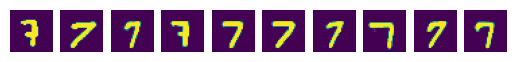

Lambda:  0.9999 | Embedding Dim:  10
---------------------------------------------------------
Epoch 0 | Total Loss: 0.5864 | Reconstruction Loss: 0.5736 | KLD Loss: 128.5610
Epoch 50 | Total Loss: 0.3544 | Reconstruction Loss: 0.3511 | KLD Loss: 33.0447
Epoch 100 | Total Loss: 0.3517 | Reconstruction Loss: 0.3486 | KLD Loss: 31.9755
Epoch 150 | Total Loss: 0.3505 | Reconstruction Loss: 0.3473 | KLD Loss: 32.1307
Epoch 200 | Total Loss: 0.3495 | Reconstruction Loss: 0.3463 | KLD Loss: 32.1491
Epoch 250 | Total Loss: 0.3487 | Reconstruction Loss: 0.3455 | KLD Loss: 32.4158
Epoch 299 | Total Loss: 0.3485 | Reconstruction Loss: 0.3453 | KLD Loss: 32.3641


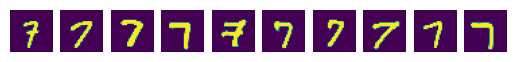

Lambda:  0.9999 | Embedding Dim:  100
---------------------------------------------------------
Epoch 0 | Total Loss: 0.5762 | Reconstruction Loss: 0.5576 | KLD Loss: 186.9804
Epoch 50 | Total Loss: 0.3500 | Reconstruction Loss: 0.3427 | KLD Loss: 73.5026
Epoch 100 | Total Loss: 0.3469 | Reconstruction Loss: 0.3402 | KLD Loss: 67.2872
Epoch 150 | Total Loss: 0.3456 | Reconstruction Loss: 0.3391 | KLD Loss: 65.1725
Epoch 200 | Total Loss: 0.3447 | Reconstruction Loss: 0.3384 | KLD Loss: 63.5382
Epoch 250 | Total Loss: 0.3444 | Reconstruction Loss: 0.3381 | KLD Loss: 62.8112
Epoch 299 | Total Loss: 0.3438 | Reconstruction Loss: 0.3376 | KLD Loss: 61.9189


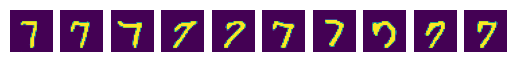

Lambda:  0.9999 | Embedding Dim:  1000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.5890 | Reconstruction Loss: 0.5674 | KLD Loss: 217.4469
Epoch 50 | Total Loss: 0.3559 | Reconstruction Loss: 0.3472 | KLD Loss: 87.6627
Epoch 100 | Total Loss: 0.3507 | Reconstruction Loss: 0.3431 | KLD Loss: 76.0104
Epoch 150 | Total Loss: 0.3486 | Reconstruction Loss: 0.3415 | KLD Loss: 71.2189
Epoch 200 | Total Loss: 0.3474 | Reconstruction Loss: 0.3406 | KLD Loss: 68.7382
Epoch 250 | Total Loss: 0.3465 | Reconstruction Loss: 0.3399 | KLD Loss: 66.7142
Epoch 299 | Total Loss: 0.3458 | Reconstruction Loss: 0.3393 | KLD Loss: 65.1858


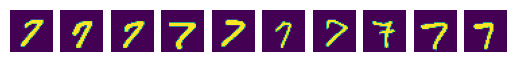

Lambda:  0.9999 | Embedding Dim:  2000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.5882 | Reconstruction Loss: 0.5574 | KLD Loss: 309.0696
Epoch 50 | Total Loss: 0.3636 | Reconstruction Loss: 0.3527 | KLD Loss: 110.1406
Epoch 100 | Total Loss: 0.3570 | Reconstruction Loss: 0.3474 | KLD Loss: 95.7676
Epoch 150 | Total Loss: 0.3521 | Reconstruction Loss: 0.3440 | KLD Loss: 80.9769
Epoch 200 | Total Loss: 0.3496 | Reconstruction Loss: 0.3423 | KLD Loss: 73.0379
Epoch 250 | Total Loss: 0.3483 | Reconstruction Loss: 0.3414 | KLD Loss: 69.3498
Epoch 299 | Total Loss: 0.3474 | Reconstruction Loss: 0.3407 | KLD Loss: 67.0628


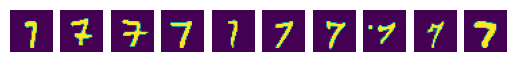

Lambda:  0.9999 | Embedding Dim:  4000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6374 | Reconstruction Loss: 0.5936 | KLD Loss: 438.2084
Epoch 50 | Total Loss: 0.3647 | Reconstruction Loss: 0.3534 | KLD Loss: 113.6684
Epoch 100 | Total Loss: 0.3614 | Reconstruction Loss: 0.3505 | KLD Loss: 109.6883
Epoch 150 | Total Loss: 0.3595 | Reconstruction Loss: 0.3486 | KLD Loss: 108.7543
Epoch 200 | Total Loss: 0.3580 | Reconstruction Loss: 0.3474 | KLD Loss: 106.5084
Epoch 250 | Total Loss: 0.3569 | Reconstruction Loss: 0.3465 | KLD Loss: 104.4920
Epoch 299 | Total Loss: 0.3559 | Reconstruction Loss: 0.3458 | KLD Loss: 100.7505


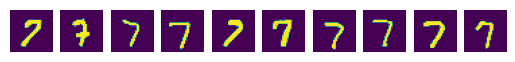

Classe:  8 

Lambda:  0.9 | Embedding Dim:  2
---------------------------------------------------------
Epoch 0 | Total Loss: 0.7783 | Reconstruction Loss: 0.8230 | KLD Loss: 0.3757
Epoch 50 | Total Loss: 0.5253 | Reconstruction Loss: 0.5836 | KLD Loss: 0.0007
Epoch 100 | Total Loss: 0.5251 | Reconstruction Loss: 0.5834 | KLD Loss: 0.0008
Epoch 150 | Total Loss: 0.5250 | Reconstruction Loss: 0.5833 | KLD Loss: 0.0001
Epoch 200 | Total Loss: 0.5250 | Reconstruction Loss: 0.5833 | KLD Loss: 0.0000
Epoch 250 | Total Loss: 0.5249 | Reconstruction Loss: 0.5832 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.5249 | Reconstruction Loss: 0.5832 | KLD Loss: 0.0000


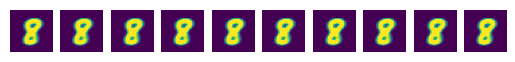

Lambda:  0.9 | Embedding Dim:  10
---------------------------------------------------------
Epoch 0 | Total Loss: 0.8980 | Reconstruction Loss: 0.8779 | KLD Loss: 1.0793
Epoch 50 | Total Loss: 0.5255 | Reconstruction Loss: 0.5836 | KLD Loss: 0.0021
Epoch 100 | Total Loss: 0.5252 | Reconstruction Loss: 0.5835 | KLD Loss: 0.0005
Epoch 150 | Total Loss: 0.5251 | Reconstruction Loss: 0.5834 | KLD Loss: 0.0001
Epoch 200 | Total Loss: 0.5250 | Reconstruction Loss: 0.5833 | KLD Loss: 0.0000
Epoch 250 | Total Loss: 0.5249 | Reconstruction Loss: 0.5832 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.5249 | Reconstruction Loss: 0.5832 | KLD Loss: 0.0000


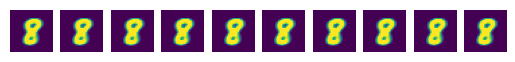

Lambda:  0.9 | Embedding Dim:  100
---------------------------------------------------------
Epoch 0 | Total Loss: 1.6243 | Reconstruction Loss: 0.8993 | KLD Loss: 8.1489
Epoch 50 | Total Loss: 0.5256 | Reconstruction Loss: 0.5837 | KLD Loss: 0.0023
Epoch 100 | Total Loss: 0.5252 | Reconstruction Loss: 0.5835 | KLD Loss: 0.0005
Epoch 150 | Total Loss: 0.5251 | Reconstruction Loss: 0.5834 | KLD Loss: 0.0001
Epoch 200 | Total Loss: 0.5250 | Reconstruction Loss: 0.5833 | KLD Loss: 0.0000
Epoch 250 | Total Loss: 0.5250 | Reconstruction Loss: 0.5833 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.5249 | Reconstruction Loss: 0.5832 | KLD Loss: 0.0000


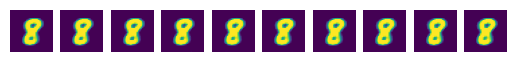

Lambda:  0.9 | Embedding Dim:  1000
---------------------------------------------------------
Epoch 0 | Total Loss: 7.2146 | Reconstruction Loss: 0.8969 | KLD Loss: 64.0738
Epoch 50 | Total Loss: 0.5261 | Reconstruction Loss: 0.5842 | KLD Loss: 0.0038
Epoch 100 | Total Loss: 0.5254 | Reconstruction Loss: 0.5837 | KLD Loss: 0.0007
Epoch 150 | Total Loss: 0.5252 | Reconstruction Loss: 0.5835 | KLD Loss: 0.0001
Epoch 200 | Total Loss: 0.5251 | Reconstruction Loss: 0.5835 | KLD Loss: 0.0000
Epoch 250 | Total Loss: 0.5251 | Reconstruction Loss: 0.5834 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.5250 | Reconstruction Loss: 0.5833 | KLD Loss: 0.0000


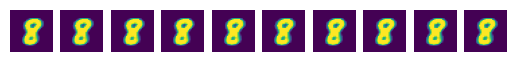

Lambda:  0.9 | Embedding Dim:  2000
---------------------------------------------------------
Epoch 0 | Total Loss: 13.8820 | Reconstruction Loss: 0.8758 | KLD Loss: 130.9383
Epoch 50 | Total Loss: 0.5274 | Reconstruction Loss: 0.5849 | KLD Loss: 0.0097
Epoch 100 | Total Loss: 0.5257 | Reconstruction Loss: 0.5840 | KLD Loss: 0.0009
Epoch 150 | Total Loss: 0.5252 | Reconstruction Loss: 0.5836 | KLD Loss: 0.0000
Epoch 200 | Total Loss: 0.5251 | Reconstruction Loss: 0.5834 | KLD Loss: 0.0000
Epoch 250 | Total Loss: 0.5251 | Reconstruction Loss: 0.5834 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.5250 | Reconstruction Loss: 0.5833 | KLD Loss: 0.0000


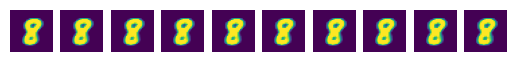

Lambda:  0.9 | Embedding Dim:  4000
---------------------------------------------------------
Epoch 0 | Total Loss: 26.6298 | Reconstruction Loss: 0.8937 | KLD Loss: 258.2542
Epoch 50 | Total Loss: 0.5295 | Reconstruction Loss: 0.5868 | KLD Loss: 0.0135
Epoch 100 | Total Loss: 0.5260 | Reconstruction Loss: 0.5844 | KLD Loss: 0.0007
Epoch 150 | Total Loss: 0.5256 | Reconstruction Loss: 0.5840 | KLD Loss: 0.0001
Epoch 200 | Total Loss: 0.5254 | Reconstruction Loss: 0.5838 | KLD Loss: 0.0000
Epoch 250 | Total Loss: 0.5253 | Reconstruction Loss: 0.5836 | KLD Loss: 0.0004
Epoch 299 | Total Loss: 0.5252 | Reconstruction Loss: 0.5835 | KLD Loss: 0.0000


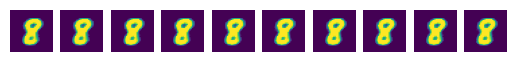

Lambda:  0.99 | Embedding Dim:  2
---------------------------------------------------------
Epoch 0 | Total Loss: 0.7777 | Reconstruction Loss: 0.7639 | KLD Loss: 2.1449
Epoch 50 | Total Loss: 0.5379 | Reconstruction Loss: 0.5207 | KLD Loss: 2.2415
Epoch 100 | Total Loss: 0.5377 | Reconstruction Loss: 0.5195 | KLD Loss: 2.3365
Epoch 150 | Total Loss: 0.5369 | Reconstruction Loss: 0.5186 | KLD Loss: 2.3459
Epoch 200 | Total Loss: 0.5362 | Reconstruction Loss: 0.5174 | KLD Loss: 2.4008
Epoch 250 | Total Loss: 0.5359 | Reconstruction Loss: 0.5170 | KLD Loss: 2.4059
Epoch 299 | Total Loss: 0.5357 | Reconstruction Loss: 0.5163 | KLD Loss: 2.4534


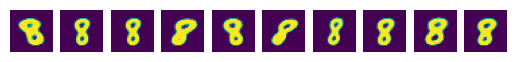

Lambda:  0.99 | Embedding Dim:  10
---------------------------------------------------------
Epoch 0 | Total Loss: 0.8708 | Reconstruction Loss: 0.8560 | KLD Loss: 2.3324
Epoch 50 | Total Loss: 0.5295 | Reconstruction Loss: 0.4952 | KLD Loss: 3.9206
Epoch 100 | Total Loss: 0.5279 | Reconstruction Loss: 0.4921 | KLD Loss: 4.0729
Epoch 150 | Total Loss: 0.5274 | Reconstruction Loss: 0.4908 | KLD Loss: 4.1508
Epoch 200 | Total Loss: 0.5266 | Reconstruction Loss: 0.4894 | KLD Loss: 4.2139
Epoch 250 | Total Loss: 0.5264 | Reconstruction Loss: 0.4885 | KLD Loss: 4.2815
Epoch 299 | Total Loss: 0.5257 | Reconstruction Loss: 0.4878 | KLD Loss: 4.2774


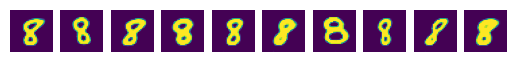

Lambda:  0.99 | Embedding Dim:  100
---------------------------------------------------------
Epoch 0 | Total Loss: 0.9415 | Reconstruction Loss: 0.8591 | KLD Loss: 9.0918
Epoch 50 | Total Loss: 0.5330 | Reconstruction Loss: 0.5039 | KLD Loss: 3.4160
Epoch 100 | Total Loss: 0.5302 | Reconstruction Loss: 0.4989 | KLD Loss: 3.6369
Epoch 150 | Total Loss: 0.5297 | Reconstruction Loss: 0.4981 | KLD Loss: 3.6536
Epoch 200 | Total Loss: 0.5288 | Reconstruction Loss: 0.4962 | KLD Loss: 3.7576
Epoch 250 | Total Loss: 0.5282 | Reconstruction Loss: 0.4941 | KLD Loss: 3.9078
Epoch 299 | Total Loss: 0.5274 | Reconstruction Loss: 0.4930 | KLD Loss: 3.9320


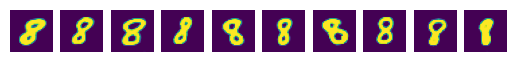

Lambda:  0.99 | Embedding Dim:  1000
---------------------------------------------------------
Epoch 0 | Total Loss: 1.5162 | Reconstruction Loss: 0.8415 | KLD Loss: 68.3164
Epoch 50 | Total Loss: 0.5556 | Reconstruction Loss: 0.5358 | KLD Loss: 2.5107
Epoch 100 | Total Loss: 0.5532 | Reconstruction Loss: 0.5323 | KLD Loss: 2.6236
Epoch 150 | Total Loss: 0.5523 | Reconstruction Loss: 0.5315 | KLD Loss: 2.6130
Epoch 200 | Total Loss: 0.5523 | Reconstruction Loss: 0.5303 | KLD Loss: 2.7261
Epoch 250 | Total Loss: 0.5517 | Reconstruction Loss: 0.5295 | KLD Loss: 2.7465
Epoch 299 | Total Loss: 0.5507 | Reconstruction Loss: 0.5287 | KLD Loss: 2.7368


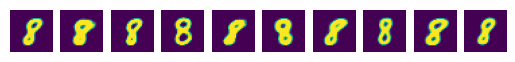

Lambda:  0.99 | Embedding Dim:  2000
---------------------------------------------------------
Epoch 0 | Total Loss: 2.1611 | Reconstruction Loss: 0.8236 | KLD Loss: 134.5754
Epoch 50 | Total Loss: 0.5570 | Reconstruction Loss: 0.5378 | KLD Loss: 2.4585
Epoch 100 | Total Loss: 0.5547 | Reconstruction Loss: 0.5349 | KLD Loss: 2.5073
Epoch 150 | Total Loss: 0.5532 | Reconstruction Loss: 0.5328 | KLD Loss: 2.5754
Epoch 200 | Total Loss: 0.5530 | Reconstruction Loss: 0.5317 | KLD Loss: 2.6621
Epoch 250 | Total Loss: 0.5528 | Reconstruction Loss: 0.5314 | KLD Loss: 2.6701
Epoch 299 | Total Loss: 0.5526 | Reconstruction Loss: 0.5314 | KLD Loss: 2.6547


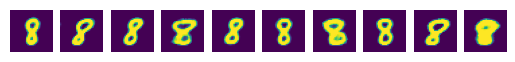

Lambda:  0.99 | Embedding Dim:  4000
---------------------------------------------------------
Epoch 0 | Total Loss: 3.4954 | Reconstruction Loss: 0.8332 | KLD Loss: 267.0569
Epoch 50 | Total Loss: 0.5606 | Reconstruction Loss: 0.5413 | KLD Loss: 2.4689
Epoch 100 | Total Loss: 0.5566 | Reconstruction Loss: 0.5369 | KLD Loss: 2.5055
Epoch 150 | Total Loss: 0.5547 | Reconstruction Loss: 0.5341 | KLD Loss: 2.6015
Epoch 200 | Total Loss: 0.5534 | Reconstruction Loss: 0.5329 | KLD Loss: 2.5862
Epoch 250 | Total Loss: 0.5528 | Reconstruction Loss: 0.5320 | KLD Loss: 2.6088
Epoch 299 | Total Loss: 0.5531 | Reconstruction Loss: 0.5318 | KLD Loss: 2.6568


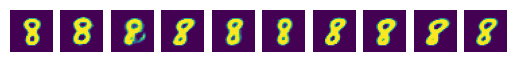

Lambda:  0.999 | Embedding Dim:  2
---------------------------------------------------------
Epoch 0 | Total Loss: 0.7075 | Reconstruction Loss: 0.6866 | KLD Loss: 21.5730
Epoch 50 | Total Loss: 0.5140 | Reconstruction Loss: 0.5093 | KLD Loss: 5.1541
Epoch 100 | Total Loss: 0.5101 | Reconstruction Loss: 0.5051 | KLD Loss: 5.5476
Epoch 150 | Total Loss: 0.5075 | Reconstruction Loss: 0.5022 | KLD Loss: 5.7746
Epoch 200 | Total Loss: 0.5065 | Reconstruction Loss: 0.5011 | KLD Loss: 5.8467
Epoch 250 | Total Loss: 0.5053 | Reconstruction Loss: 0.4997 | KLD Loss: 6.0188
Epoch 299 | Total Loss: 0.5042 | Reconstruction Loss: 0.4986 | KLD Loss: 6.0659


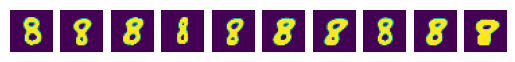

Lambda:  0.999 | Embedding Dim:  10
---------------------------------------------------------
Epoch 0 | Total Loss: 0.7337 | Reconstruction Loss: 0.7071 | KLD Loss: 27.2869
Epoch 50 | Total Loss: 0.4511 | Reconstruction Loss: 0.4324 | KLD Loss: 19.0855
Epoch 100 | Total Loss: 0.4472 | Reconstruction Loss: 0.4283 | KLD Loss: 19.3465
Epoch 150 | Total Loss: 0.4458 | Reconstruction Loss: 0.4267 | KLD Loss: 19.5272
Epoch 200 | Total Loss: 0.4446 | Reconstruction Loss: 0.4256 | KLD Loss: 19.4370
Epoch 250 | Total Loss: 0.4438 | Reconstruction Loss: 0.4246 | KLD Loss: 19.5759
Epoch 299 | Total Loss: 0.4431 | Reconstruction Loss: 0.4239 | KLD Loss: 19.6330


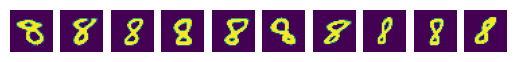

Lambda:  0.999 | Embedding Dim:  100
---------------------------------------------------------
Epoch 0 | Total Loss: 0.8036 | Reconstruction Loss: 0.7804 | KLD Loss: 23.9847
Epoch 50 | Total Loss: 0.4521 | Reconstruction Loss: 0.4289 | KLD Loss: 23.5747
Epoch 100 | Total Loss: 0.4480 | Reconstruction Loss: 0.4243 | KLD Loss: 24.0864
Epoch 150 | Total Loss: 0.4459 | Reconstruction Loss: 0.4224 | KLD Loss: 23.9703
Epoch 200 | Total Loss: 0.4448 | Reconstruction Loss: 0.4213 | KLD Loss: 23.9641
Epoch 250 | Total Loss: 0.4437 | Reconstruction Loss: 0.4202 | KLD Loss: 23.9593
Epoch 299 | Total Loss: 0.4432 | Reconstruction Loss: 0.4197 | KLD Loss: 23.8844


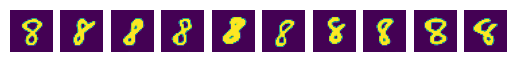

Lambda:  0.999 | Embedding Dim:  1000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.8610 | Reconstruction Loss: 0.7786 | KLD Loss: 83.2014
Epoch 50 | Total Loss: 0.4781 | Reconstruction Loss: 0.4509 | KLD Loss: 27.6507
Epoch 100 | Total Loss: 0.4576 | Reconstruction Loss: 0.4334 | KLD Loss: 24.6480
Epoch 150 | Total Loss: 0.4501 | Reconstruction Loss: 0.4267 | KLD Loss: 23.8589
Epoch 200 | Total Loss: 0.4478 | Reconstruction Loss: 0.4244 | KLD Loss: 23.8385
Epoch 250 | Total Loss: 0.4465 | Reconstruction Loss: 0.4232 | KLD Loss: 23.6643
Epoch 299 | Total Loss: 0.4449 | Reconstruction Loss: 0.4217 | KLD Loss: 23.5757


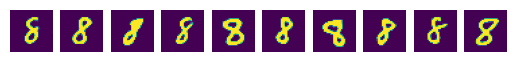

Lambda:  0.999 | Embedding Dim:  2000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.9406 | Reconstruction Loss: 0.7701 | KLD Loss: 171.2468
Epoch 50 | Total Loss: 0.4859 | Reconstruction Loss: 0.4565 | KLD Loss: 29.8659
Epoch 100 | Total Loss: 0.4800 | Reconstruction Loss: 0.4505 | KLD Loss: 29.9408
Epoch 150 | Total Loss: 0.4777 | Reconstruction Loss: 0.4479 | KLD Loss: 30.2874
Epoch 200 | Total Loss: 0.4764 | Reconstruction Loss: 0.4464 | KLD Loss: 30.4020
Epoch 250 | Total Loss: 0.4724 | Reconstruction Loss: 0.4431 | KLD Loss: 29.8065
Epoch 299 | Total Loss: 0.4663 | Reconstruction Loss: 0.4389 | KLD Loss: 27.9067


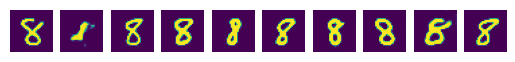

Lambda:  0.999 | Embedding Dim:  4000
---------------------------------------------------------
Epoch 0 | Total Loss: 1.1137 | Reconstruction Loss: 0.8056 | KLD Loss: 308.8805
Epoch 50 | Total Loss: 0.4882 | Reconstruction Loss: 0.4583 | KLD Loss: 30.2944
Epoch 100 | Total Loss: 0.4824 | Reconstruction Loss: 0.4524 | KLD Loss: 30.4402
Epoch 150 | Total Loss: 0.4803 | Reconstruction Loss: 0.4499 | KLD Loss: 30.8367
Epoch 200 | Total Loss: 0.4780 | Reconstruction Loss: 0.4479 | KLD Loss: 30.5852
Epoch 250 | Total Loss: 0.4772 | Reconstruction Loss: 0.4467 | KLD Loss: 30.9398
Epoch 299 | Total Loss: 0.4775 | Reconstruction Loss: 0.4463 | KLD Loss: 31.6362


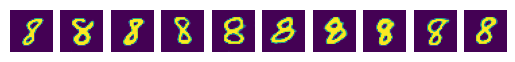

Lambda:  0.9999 | Embedding Dim:  2
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6830 | Reconstruction Loss: 0.6728 | KLD Loss: 102.6630
Epoch 50 | Total Loss: 0.5089 | Reconstruction Loss: 0.5080 | KLD Loss: 9.8564
Epoch 100 | Total Loss: 0.5034 | Reconstruction Loss: 0.5025 | KLD Loss: 9.5355
Epoch 150 | Total Loss: 0.5023 | Reconstruction Loss: 0.5013 | KLD Loss: 9.8287
Epoch 200 | Total Loss: 0.4996 | Reconstruction Loss: 0.4986 | KLD Loss: 10.1219
Epoch 250 | Total Loss: 0.4983 | Reconstruction Loss: 0.4974 | KLD Loss: 10.2558
Epoch 299 | Total Loss: 0.4974 | Reconstruction Loss: 0.4964 | KLD Loss: 10.4449


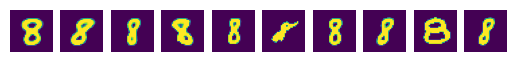

Lambda:  0.9999 | Embedding Dim:  10
---------------------------------------------------------
Epoch 0 | Total Loss: 0.7086 | Reconstruction Loss: 0.6909 | KLD Loss: 177.0147
Epoch 50 | Total Loss: 0.4318 | Reconstruction Loss: 0.4284 | KLD Loss: 34.9290
Epoch 100 | Total Loss: 0.4278 | Reconstruction Loss: 0.4244 | KLD Loss: 34.4341
Epoch 150 | Total Loss: 0.4257 | Reconstruction Loss: 0.4224 | KLD Loss: 34.3326
Epoch 200 | Total Loss: 0.4246 | Reconstruction Loss: 0.4212 | KLD Loss: 34.7978
Epoch 250 | Total Loss: 0.4233 | Reconstruction Loss: 0.4199 | KLD Loss: 34.5319
Epoch 299 | Total Loss: 0.4228 | Reconstruction Loss: 0.4194 | KLD Loss: 34.6172


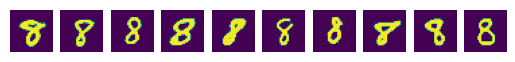

Lambda:  0.9999 | Embedding Dim:  100
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6897 | Reconstruction Loss: 0.6708 | KLD Loss: 189.5936
Epoch 50 | Total Loss: 0.4171 | Reconstruction Loss: 0.4077 | KLD Loss: 94.2696
Epoch 100 | Total Loss: 0.4122 | Reconstruction Loss: 0.4035 | KLD Loss: 87.5241
Epoch 150 | Total Loss: 0.4101 | Reconstruction Loss: 0.4016 | KLD Loss: 85.1503
Epoch 200 | Total Loss: 0.4089 | Reconstruction Loss: 0.4005 | KLD Loss: 84.3343
Epoch 250 | Total Loss: 0.4080 | Reconstruction Loss: 0.3997 | KLD Loss: 83.6867
Epoch 299 | Total Loss: 0.4073 | Reconstruction Loss: 0.3991 | KLD Loss: 82.8481


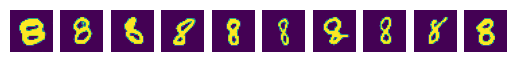

Lambda:  0.9999 | Embedding Dim:  1000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6746 | Reconstruction Loss: 0.6479 | KLD Loss: 267.8906
Epoch 50 | Total Loss: 0.4246 | Reconstruction Loss: 0.4132 | KLD Loss: 114.1833
Epoch 100 | Total Loss: 0.4168 | Reconstruction Loss: 0.4071 | KLD Loss: 97.5620
Epoch 150 | Total Loss: 0.4138 | Reconstruction Loss: 0.4046 | KLD Loss: 92.0272
Epoch 200 | Total Loss: 0.4122 | Reconstruction Loss: 0.4033 | KLD Loss: 89.1964
Epoch 250 | Total Loss: 0.4109 | Reconstruction Loss: 0.4022 | KLD Loss: 87.7348
Epoch 299 | Total Loss: 0.4101 | Reconstruction Loss: 0.4014 | KLD Loss: 86.8540


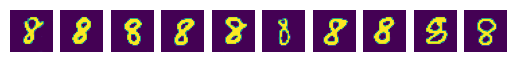

Lambda:  0.9999 | Embedding Dim:  2000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.7056 | Reconstruction Loss: 0.6762 | KLD Loss: 294.3222
Epoch 50 | Total Loss: 0.4333 | Reconstruction Loss: 0.4196 | KLD Loss: 137.0118
Epoch 100 | Total Loss: 0.4232 | Reconstruction Loss: 0.4115 | KLD Loss: 118.3234
Epoch 150 | Total Loss: 0.4172 | Reconstruction Loss: 0.4071 | KLD Loss: 101.6307
Epoch 200 | Total Loss: 0.4142 | Reconstruction Loss: 0.4048 | KLD Loss: 94.7151
Epoch 250 | Total Loss: 0.4125 | Reconstruction Loss: 0.4035 | KLD Loss: 90.6613
Epoch 299 | Total Loss: 0.4115 | Reconstruction Loss: 0.4026 | KLD Loss: 88.8250


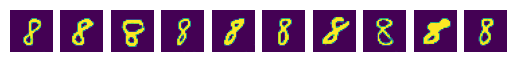

Lambda:  0.9999 | Embedding Dim:  4000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.7436 | Reconstruction Loss: 0.6776 | KLD Loss: 660.8365
Epoch 50 | Total Loss: 0.4356 | Reconstruction Loss: 0.4215 | KLD Loss: 141.1695
Epoch 100 | Total Loss: 0.4306 | Reconstruction Loss: 0.4167 | KLD Loss: 139.0491
Epoch 150 | Total Loss: 0.4280 | Reconstruction Loss: 0.4145 | KLD Loss: 135.4901
Epoch 200 | Total Loss: 0.4256 | Reconstruction Loss: 0.4123 | KLD Loss: 133.1652
Epoch 250 | Total Loss: 0.4237 | Reconstruction Loss: 0.4108 | KLD Loss: 129.0817
Epoch 299 | Total Loss: 0.4210 | Reconstruction Loss: 0.4087 | KLD Loss: 122.9554


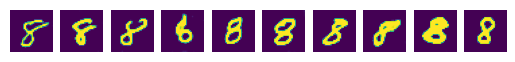

Classe:  9 

Lambda:  0.9 | Embedding Dim:  2
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6838 | Reconstruction Loss: 0.7165 | KLD Loss: 0.3901
Epoch 50 | Total Loss: 0.4599 | Reconstruction Loss: 0.5110 | KLD Loss: 0.0005
Epoch 100 | Total Loss: 0.4597 | Reconstruction Loss: 0.5108 | KLD Loss: 0.0002
Epoch 150 | Total Loss: 0.4597 | Reconstruction Loss: 0.5108 | KLD Loss: 0.0002
Epoch 200 | Total Loss: 0.4596 | Reconstruction Loss: 0.5107 | KLD Loss: 0.0000
Epoch 250 | Total Loss: 0.4596 | Reconstruction Loss: 0.5107 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.4596 | Reconstruction Loss: 0.5107 | KLD Loss: 0.0000


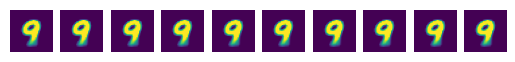

Lambda:  0.9 | Embedding Dim:  10
---------------------------------------------------------
Epoch 0 | Total Loss: 0.8366 | Reconstruction Loss: 0.8131 | KLD Loss: 1.0481
Epoch 50 | Total Loss: 0.4600 | Reconstruction Loss: 0.5110 | KLD Loss: 0.0014
Epoch 100 | Total Loss: 0.4598 | Reconstruction Loss: 0.5108 | KLD Loss: 0.0007
Epoch 150 | Total Loss: 0.4597 | Reconstruction Loss: 0.5107 | KLD Loss: 0.0003
Epoch 200 | Total Loss: 0.4597 | Reconstruction Loss: 0.5107 | KLD Loss: 0.0001
Epoch 250 | Total Loss: 0.4596 | Reconstruction Loss: 0.5107 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.4596 | Reconstruction Loss: 0.5107 | KLD Loss: 0.0000


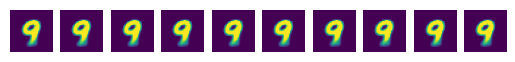

Lambda:  0.9 | Embedding Dim:  100
---------------------------------------------------------
Epoch 0 | Total Loss: 1.4076 | Reconstruction Loss: 0.7869 | KLD Loss: 6.9940
Epoch 50 | Total Loss: 0.4601 | Reconstruction Loss: 0.5110 | KLD Loss: 0.0024
Epoch 100 | Total Loss: 0.4599 | Reconstruction Loss: 0.5109 | KLD Loss: 0.0007
Epoch 150 | Total Loss: 0.4597 | Reconstruction Loss: 0.5108 | KLD Loss: 0.0001
Epoch 200 | Total Loss: 0.4596 | Reconstruction Loss: 0.5107 | KLD Loss: 0.0000
Epoch 250 | Total Loss: 0.4596 | Reconstruction Loss: 0.5107 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.4596 | Reconstruction Loss: 0.5107 | KLD Loss: 0.0000


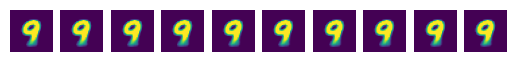

Lambda:  0.9 | Embedding Dim:  1000
---------------------------------------------------------
Epoch 0 | Total Loss: 6.9093 | Reconstruction Loss: 0.8804 | KLD Loss: 61.1694
Epoch 50 | Total Loss: 0.4608 | Reconstruction Loss: 0.5114 | KLD Loss: 0.0051
Epoch 100 | Total Loss: 0.4600 | Reconstruction Loss: 0.5111 | KLD Loss: 0.0002
Epoch 150 | Total Loss: 0.4598 | Reconstruction Loss: 0.5109 | KLD Loss: 0.0000
Epoch 200 | Total Loss: 0.4598 | Reconstruction Loss: 0.5109 | KLD Loss: 0.0000
Epoch 250 | Total Loss: 0.4597 | Reconstruction Loss: 0.5108 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.4597 | Reconstruction Loss: 0.5107 | KLD Loss: 0.0000


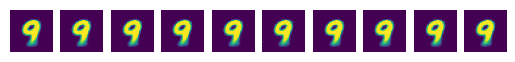

Lambda:  0.9 | Embedding Dim:  2000
---------------------------------------------------------
Epoch 0 | Total Loss: 13.5574 | Reconstruction Loss: 0.7618 | KLD Loss: 128.7179
Epoch 50 | Total Loss: 0.4623 | Reconstruction Loss: 0.5118 | KLD Loss: 0.0169
Epoch 100 | Total Loss: 0.4602 | Reconstruction Loss: 0.5112 | KLD Loss: 0.0014
Epoch 150 | Total Loss: 0.4600 | Reconstruction Loss: 0.5111 | KLD Loss: 0.0001
Epoch 200 | Total Loss: 0.4599 | Reconstruction Loss: 0.5110 | KLD Loss: 0.0001
Epoch 250 | Total Loss: 0.4598 | Reconstruction Loss: 0.5108 | KLD Loss: 0.0001
Epoch 299 | Total Loss: 0.4597 | Reconstruction Loss: 0.5108 | KLD Loss: 0.0000


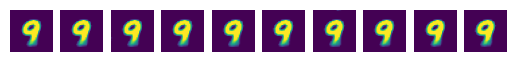

Lambda:  0.9 | Embedding Dim:  4000
---------------------------------------------------------
Epoch 0 | Total Loss: 25.5171 | Reconstruction Loss: 0.7763 | KLD Loss: 248.1840
Epoch 50 | Total Loss: 0.4627 | Reconstruction Loss: 0.5128 | KLD Loss: 0.0126
Epoch 100 | Total Loss: 0.4606 | Reconstruction Loss: 0.5116 | KLD Loss: 0.0015
Epoch 150 | Total Loss: 0.4601 | Reconstruction Loss: 0.5112 | KLD Loss: 0.0001
Epoch 200 | Total Loss: 0.4599 | Reconstruction Loss: 0.5110 | KLD Loss: 0.0001
Epoch 250 | Total Loss: 0.4598 | Reconstruction Loss: 0.5109 | KLD Loss: 0.0000
Epoch 299 | Total Loss: 0.4598 | Reconstruction Loss: 0.5109 | KLD Loss: 0.0000


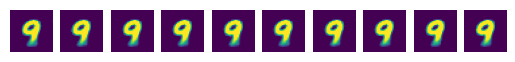

Lambda:  0.99 | Embedding Dim:  2
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6995 | Reconstruction Loss: 0.6836 | KLD Loss: 2.2757
Epoch 50 | Total Loss: 0.4556 | Reconstruction Loss: 0.4349 | KLD Loss: 2.5082
Epoch 100 | Total Loss: 0.4547 | Reconstruction Loss: 0.4335 | KLD Loss: 2.5535
Epoch 150 | Total Loss: 0.4541 | Reconstruction Loss: 0.4330 | KLD Loss: 2.5412
Epoch 200 | Total Loss: 0.4537 | Reconstruction Loss: 0.4327 | KLD Loss: 2.5354
Epoch 250 | Total Loss: 0.4534 | Reconstruction Loss: 0.4322 | KLD Loss: 2.5571
Epoch 299 | Total Loss: 0.4532 | Reconstruction Loss: 0.4319 | KLD Loss: 2.5695


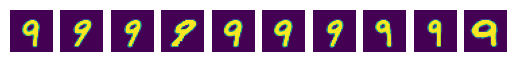

Lambda:  0.99 | Embedding Dim:  10
---------------------------------------------------------
Epoch 0 | Total Loss: 0.7638 | Reconstruction Loss: 0.7410 | KLD Loss: 3.0242
Epoch 50 | Total Loss: 0.4514 | Reconstruction Loss: 0.4185 | KLD Loss: 3.7084
Epoch 100 | Total Loss: 0.4496 | Reconstruction Loss: 0.4162 | KLD Loss: 3.7625
Epoch 150 | Total Loss: 0.4492 | Reconstruction Loss: 0.4159 | KLD Loss: 3.7449
Epoch 200 | Total Loss: 0.4489 | Reconstruction Loss: 0.4147 | KLD Loss: 3.8322
Epoch 250 | Total Loss: 0.4486 | Reconstruction Loss: 0.4142 | KLD Loss: 3.8528
Epoch 299 | Total Loss: 0.4478 | Reconstruction Loss: 0.4141 | KLD Loss: 3.7837


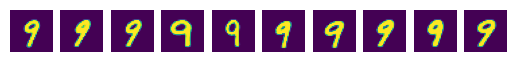

Lambda:  0.99 | Embedding Dim:  100
---------------------------------------------------------
Epoch 0 | Total Loss: 0.8371 | Reconstruction Loss: 0.7588 | KLD Loss: 8.5870
Epoch 50 | Total Loss: 0.4540 | Reconstruction Loss: 0.4258 | KLD Loss: 3.2501
Epoch 100 | Total Loss: 0.4508 | Reconstruction Loss: 0.4203 | KLD Loss: 3.4693
Epoch 150 | Total Loss: 0.4501 | Reconstruction Loss: 0.4191 | KLD Loss: 3.5208
Epoch 200 | Total Loss: 0.4500 | Reconstruction Loss: 0.4181 | KLD Loss: 3.6074
Epoch 250 | Total Loss: 0.4489 | Reconstruction Loss: 0.4172 | KLD Loss: 3.5859
Epoch 299 | Total Loss: 0.4490 | Reconstruction Loss: 0.4171 | KLD Loss: 3.6019


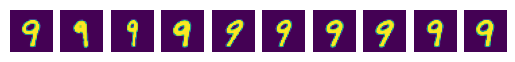

Lambda:  0.99 | Embedding Dim:  1000
---------------------------------------------------------
Epoch 0 | Total Loss: 1.4116 | Reconstruction Loss: 0.7973 | KLD Loss: 62.2223
Epoch 50 | Total Loss: 0.4775 | Reconstruction Loss: 0.4561 | KLD Loss: 2.5951
Epoch 100 | Total Loss: 0.4760 | Reconstruction Loss: 0.4535 | KLD Loss: 2.7039
Epoch 150 | Total Loss: 0.4757 | Reconstruction Loss: 0.4525 | KLD Loss: 2.7664
Epoch 200 | Total Loss: 0.4752 | Reconstruction Loss: 0.4518 | KLD Loss: 2.7933
Epoch 250 | Total Loss: 0.4748 | Reconstruction Loss: 0.4517 | KLD Loss: 2.7615
Epoch 299 | Total Loss: 0.4745 | Reconstruction Loss: 0.4511 | KLD Loss: 2.7849


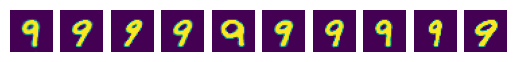

Lambda:  0.99 | Embedding Dim:  2000
---------------------------------------------------------
Epoch 0 | Total Loss: 1.9557 | Reconstruction Loss: 0.7459 | KLD Loss: 121.7216
Epoch 50 | Total Loss: 0.4803 | Reconstruction Loss: 0.4591 | KLD Loss: 2.5824
Epoch 100 | Total Loss: 0.4781 | Reconstruction Loss: 0.4560 | KLD Loss: 2.6605
Epoch 150 | Total Loss: 0.4771 | Reconstruction Loss: 0.4548 | KLD Loss: 2.6811
Epoch 200 | Total Loss: 0.4763 | Reconstruction Loss: 0.4533 | KLD Loss: 2.7531
Epoch 250 | Total Loss: 0.4757 | Reconstruction Loss: 0.4524 | KLD Loss: 2.7815
Epoch 299 | Total Loss: 0.4744 | Reconstruction Loss: 0.4522 | KLD Loss: 2.6665


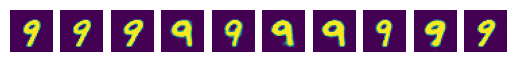

Lambda:  0.99 | Embedding Dim:  4000
---------------------------------------------------------
Epoch 0 | Total Loss: 3.1589 | Reconstruction Loss: 0.7348 | KLD Loss: 243.1469
Epoch 50 | Total Loss: 0.4821 | Reconstruction Loss: 0.4621 | KLD Loss: 2.4624
Epoch 100 | Total Loss: 0.4793 | Reconstruction Loss: 0.4576 | KLD Loss: 2.6208
Epoch 150 | Total Loss: 0.4775 | Reconstruction Loss: 0.4554 | KLD Loss: 2.6590
Epoch 200 | Total Loss: 0.4769 | Reconstruction Loss: 0.4548 | KLD Loss: 2.6616
Epoch 250 | Total Loss: 0.4754 | Reconstruction Loss: 0.4532 | KLD Loss: 2.6680
Epoch 299 | Total Loss: 0.4767 | Reconstruction Loss: 0.4541 | KLD Loss: 2.7125


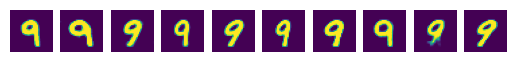

Lambda:  0.999 | Embedding Dim:  2
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6144 | Reconstruction Loss: 0.5982 | KLD Loss: 16.8093
Epoch 50 | Total Loss: 0.4277 | Reconstruction Loss: 0.4227 | KLD Loss: 5.4103
Epoch 100 | Total Loss: 0.4255 | Reconstruction Loss: 0.4204 | KLD Loss: 5.5324
Epoch 150 | Total Loss: 0.4243 | Reconstruction Loss: 0.4189 | KLD Loss: 5.8141
Epoch 200 | Total Loss: 0.4226 | Reconstruction Loss: 0.4171 | KLD Loss: 5.9326
Epoch 250 | Total Loss: 0.4222 | Reconstruction Loss: 0.4166 | KLD Loss: 6.0307
Epoch 299 | Total Loss: 0.4216 | Reconstruction Loss: 0.4158 | KLD Loss: 6.1905


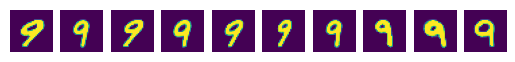

Lambda:  0.999 | Embedding Dim:  10
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6750 | Reconstruction Loss: 0.6506 | KLD Loss: 24.9949
Epoch 50 | Total Loss: 0.3856 | Reconstruction Loss: 0.3685 | KLD Loss: 17.5311
Epoch 100 | Total Loss: 0.3823 | Reconstruction Loss: 0.3649 | KLD Loss: 17.7440
Epoch 150 | Total Loss: 0.3809 | Reconstruction Loss: 0.3636 | KLD Loss: 17.6549
Epoch 200 | Total Loss: 0.3798 | Reconstruction Loss: 0.3626 | KLD Loss: 17.5173
Epoch 250 | Total Loss: 0.3794 | Reconstruction Loss: 0.3622 | KLD Loss: 17.6117
Epoch 299 | Total Loss: 0.3786 | Reconstruction Loss: 0.3614 | KLD Loss: 17.5427


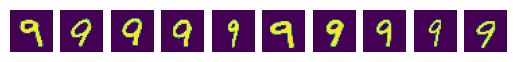

Lambda:  0.999 | Embedding Dim:  100
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6902 | Reconstruction Loss: 0.6684 | KLD Loss: 22.4444
Epoch 50 | Total Loss: 0.3869 | Reconstruction Loss: 0.3680 | KLD Loss: 19.2627
Epoch 100 | Total Loss: 0.3834 | Reconstruction Loss: 0.3645 | KLD Loss: 19.1744
Epoch 150 | Total Loss: 0.3819 | Reconstruction Loss: 0.3630 | KLD Loss: 19.2298
Epoch 200 | Total Loss: 0.3809 | Reconstruction Loss: 0.3623 | KLD Loss: 19.0285
Epoch 250 | Total Loss: 0.3803 | Reconstruction Loss: 0.3617 | KLD Loss: 19.0027
Epoch 299 | Total Loss: 0.3798 | Reconstruction Loss: 0.3612 | KLD Loss: 18.9375


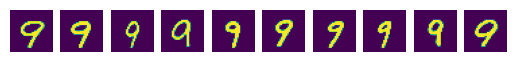

Lambda:  0.999 | Embedding Dim:  1000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.8310 | Reconstruction Loss: 0.7190 | KLD Loss: 112.6522
Epoch 50 | Total Loss: 0.4112 | Reconstruction Loss: 0.3884 | KLD Loss: 23.1471
Epoch 100 | Total Loss: 0.3904 | Reconstruction Loss: 0.3711 | KLD Loss: 19.6313
Epoch 150 | Total Loss: 0.3863 | Reconstruction Loss: 0.3675 | KLD Loss: 19.1293
Epoch 200 | Total Loss: 0.3849 | Reconstruction Loss: 0.3662 | KLD Loss: 19.1302
Epoch 250 | Total Loss: 0.3838 | Reconstruction Loss: 0.3652 | KLD Loss: 18.9446
Epoch 299 | Total Loss: 0.3827 | Reconstruction Loss: 0.3643 | KLD Loss: 18.7562


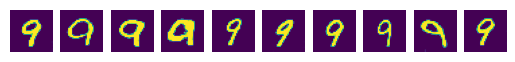

Lambda:  0.999 | Embedding Dim:  2000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.8359 | Reconstruction Loss: 0.6915 | KLD Loss: 145.0486
Epoch 50 | Total Loss: 0.4159 | Reconstruction Loss: 0.3919 | KLD Loss: 24.3682
Epoch 100 | Total Loss: 0.4120 | Reconstruction Loss: 0.3879 | KLD Loss: 24.4586
Epoch 150 | Total Loss: 0.4098 | Reconstruction Loss: 0.3857 | KLD Loss: 24.4813
Epoch 200 | Total Loss: 0.4088 | Reconstruction Loss: 0.3842 | KLD Loss: 24.9651
Epoch 250 | Total Loss: 0.4066 | Reconstruction Loss: 0.3826 | KLD Loss: 24.4566
Epoch 299 | Total Loss: 0.4024 | Reconstruction Loss: 0.3798 | KLD Loss: 22.9692


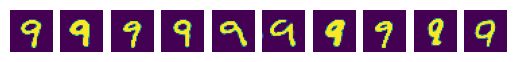

Lambda:  0.999 | Embedding Dim:  4000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.9780 | Reconstruction Loss: 0.6875 | KLD Loss: 291.1684
Epoch 50 | Total Loss: 0.4172 | Reconstruction Loss: 0.3929 | KLD Loss: 24.6552
Epoch 100 | Total Loss: 0.4135 | Reconstruction Loss: 0.3888 | KLD Loss: 25.0919
Epoch 150 | Total Loss: 0.4117 | Reconstruction Loss: 0.3868 | KLD Loss: 25.3176
Epoch 200 | Total Loss: 0.4097 | Reconstruction Loss: 0.3852 | KLD Loss: 24.9171
Epoch 250 | Total Loss: 0.4093 | Reconstruction Loss: 0.3847 | KLD Loss: 24.9567
Epoch 299 | Total Loss: 0.4091 | Reconstruction Loss: 0.3840 | KLD Loss: 25.5085


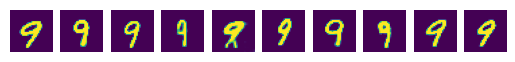

Lambda:  0.9999 | Embedding Dim:  2
---------------------------------------------------------
Epoch 0 | Total Loss: 0.5962 | Reconstruction Loss: 0.5851 | KLD Loss: 111.9050
Epoch 50 | Total Loss: 0.4228 | Reconstruction Loss: 0.4219 | KLD Loss: 9.5924
Epoch 100 | Total Loss: 0.4212 | Reconstruction Loss: 0.4203 | KLD Loss: 9.4241
Epoch 150 | Total Loss: 0.4193 | Reconstruction Loss: 0.4184 | KLD Loss: 9.3874
Epoch 200 | Total Loss: 0.4179 | Reconstruction Loss: 0.4170 | KLD Loss: 9.6534
Epoch 250 | Total Loss: 0.4179 | Reconstruction Loss: 0.4169 | KLD Loss: 10.0486
Epoch 299 | Total Loss: 0.4160 | Reconstruction Loss: 0.4150 | KLD Loss: 10.2493


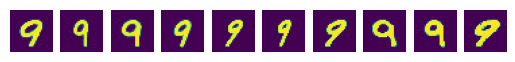

Lambda:  0.9999 | Embedding Dim:  10
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6154 | Reconstruction Loss: 0.5992 | KLD Loss: 162.3240
Epoch 50 | Total Loss: 0.3652 | Reconstruction Loss: 0.3619 | KLD Loss: 33.3529
Epoch 100 | Total Loss: 0.3623 | Reconstruction Loss: 0.3591 | KLD Loss: 32.4278
Epoch 150 | Total Loss: 0.3614 | Reconstruction Loss: 0.3582 | KLD Loss: 32.5641
Epoch 200 | Total Loss: 0.3602 | Reconstruction Loss: 0.3570 | KLD Loss: 32.3345
Epoch 250 | Total Loss: 0.3604 | Reconstruction Loss: 0.3572 | KLD Loss: 32.5858
Epoch 299 | Total Loss: 0.3591 | Reconstruction Loss: 0.3559 | KLD Loss: 32.7688


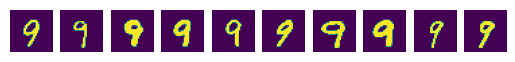

Lambda:  0.9999 | Embedding Dim:  100
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6042 | Reconstruction Loss: 0.5833 | KLD Loss: 209.8717
Epoch 50 | Total Loss: 0.3607 | Reconstruction Loss: 0.3533 | KLD Loss: 74.6946
Epoch 100 | Total Loss: 0.3571 | Reconstruction Loss: 0.3503 | KLD Loss: 68.1079
Epoch 150 | Total Loss: 0.3557 | Reconstruction Loss: 0.3492 | KLD Loss: 66.0636
Epoch 200 | Total Loss: 0.3551 | Reconstruction Loss: 0.3487 | KLD Loss: 64.1602
Epoch 250 | Total Loss: 0.3542 | Reconstruction Loss: 0.3479 | KLD Loss: 64.0130
Epoch 299 | Total Loss: 0.3537 | Reconstruction Loss: 0.3474 | KLD Loss: 63.1902


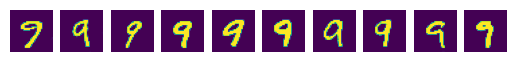

Lambda:  0.9999 | Embedding Dim:  1000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6232 | Reconstruction Loss: 0.5999 | KLD Loss: 233.7088
Epoch 50 | Total Loss: 0.3689 | Reconstruction Loss: 0.3593 | KLD Loss: 95.9571
Epoch 100 | Total Loss: 0.3613 | Reconstruction Loss: 0.3538 | KLD Loss: 75.5016
Epoch 150 | Total Loss: 0.3585 | Reconstruction Loss: 0.3516 | KLD Loss: 69.8640
Epoch 200 | Total Loss: 0.3572 | Reconstruction Loss: 0.3505 | KLD Loss: 67.7072
Epoch 250 | Total Loss: 0.3562 | Reconstruction Loss: 0.3497 | KLD Loss: 65.8096
Epoch 299 | Total Loss: 0.3557 | Reconstruction Loss: 0.3492 | KLD Loss: 65.3050


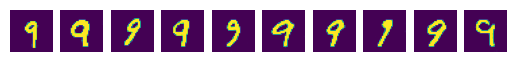

Lambda:  0.9999 | Embedding Dim:  2000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.6361 | Reconstruction Loss: 0.5960 | KLD Loss: 401.0856
Epoch 50 | Total Loss: 0.3743 | Reconstruction Loss: 0.3634 | KLD Loss: 109.8981
Epoch 100 | Total Loss: 0.3664 | Reconstruction Loss: 0.3572 | KLD Loss: 93.0785
Epoch 150 | Total Loss: 0.3616 | Reconstruction Loss: 0.3539 | KLD Loss: 77.8060
Epoch 200 | Total Loss: 0.3595 | Reconstruction Loss: 0.3523 | KLD Loss: 72.3783
Epoch 250 | Total Loss: 0.3582 | Reconstruction Loss: 0.3513 | KLD Loss: 69.1509
Epoch 299 | Total Loss: 0.3572 | Reconstruction Loss: 0.3505 | KLD Loss: 67.6463


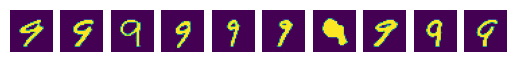

Lambda:  0.9999 | Embedding Dim:  4000
---------------------------------------------------------
Epoch 0 | Total Loss: 0.7009 | Reconstruction Loss: 0.6253 | KLD Loss: 756.3818
Epoch 50 | Total Loss: 0.3761 | Reconstruction Loss: 0.3647 | KLD Loss: 114.0514
Epoch 100 | Total Loss: 0.3724 | Reconstruction Loss: 0.3612 | KLD Loss: 111.9492
Epoch 150 | Total Loss: 0.3703 | Reconstruction Loss: 0.3594 | KLD Loss: 109.6753
Epoch 200 | Total Loss: 0.3689 | Reconstruction Loss: 0.3582 | KLD Loss: 107.9955
Epoch 250 | Total Loss: 0.3675 | Reconstruction Loss: 0.3571 | KLD Loss: 104.9047
Epoch 299 | Total Loss: 0.3661 | Reconstruction Loss: 0.3561 | KLD Loss: 100.6287


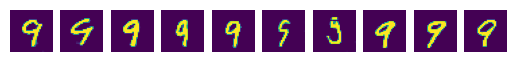

CPU times: user 10h 37min 17s, sys: 12min 47s, total: 10h 50min 5s
Wall time: 6h 18min 39s


In [25]:
%%time

for classe in range(3,10):
    print('Classe: ', classe,'\n')
    output = grid_search(params, classe)

# Análise exploratória dos resultados

In [19]:
%%time

data={'classe':[],'lambda':[],'dim':[],'total_loss':[],'recon_loss':[],'kld_loss':[]}

for classe in range(10):
    with open(f'log_{classe}.pkl', 'rb') as f:
        log = pickle.load(f)
        
    for exp in log:
        
        data['classe'].append(classe)
        data['lambda'].append(exp['lambda'])
        data['dim'].append(exp['embedding_dim'])
        data['total_loss'].append(exp['log']['total_loss'][-1])
        data['recon_loss'].append(exp['log']['recon_loss'][-1])
        data['kld_loss'].append(exp['log']['kld_loss'][-1])
        
df = pd.DataFrame(data)

CPU times: user 22.7 ms, sys: 3.06 ms, total: 25.7 ms
Wall time: 26.7 ms


In [20]:
df.head()

,classe,lambda,dim,total_loss,recon_loss,kld_loss
0,0,0.9,2,0.576474,0.640527,2.285536e-06
1,0,0.9,10,0.576507,0.640564,5.864779e-07
2,0,0.9,100,0.576504,0.640559,3.758618e-06
3,0,0.9,1000,0.576564,0.640625,1.439036e-05
4,0,0.9,2000,0.576645,0.640713,3.038267e-05


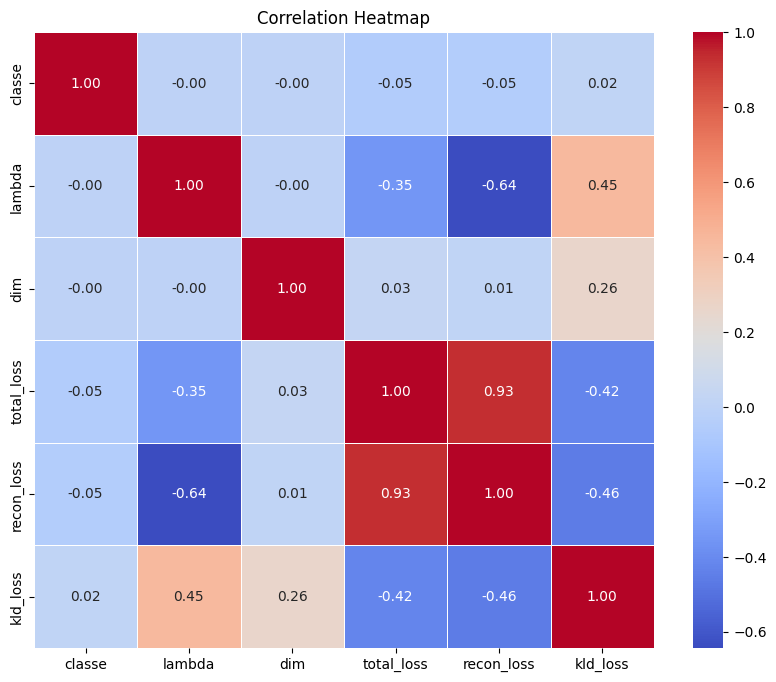

In [21]:
corr_matrix = df.corr()

plt.figure(figsize=(10, 8))  # You can adjust the size as needed
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

## Análise para uma classe (2)

In [22]:
data = df.groupby('classe').get_group(2).reset_index().drop('index',axis=1)

In [23]:
data

,classe,lambda,dim,total_loss,recon_loss,kld_loss
0,2,0.9000,2,0.554763,0.616403,3.072176e-07
1,2,0.9000,10,0.554791,0.616434,8.563412e-07
2,2,0.9000,100,0.554850,0.616500,6.930308e-06
3,2,0.9000,1000,0.554891,0.616543,2.146116e-05
4,2,0.9000,2000,0.554996,0.616657,3.793804e-05
5,2,0.9000,4000,0.555128,0.616797,1.002166e-04
6,2,0.9900,2,0.561236,0.538373,2.824672e+00
7,2,0.9900,10,0.543270,0.492520,5.567519e+00
8,2,0.9900,100,0.544920,0.495237,5.463504e+00
9,2,0.9900,1000,0.576637,0.547225,3.488457e+00


In [24]:
data.index

RangeIndex(start=0, stop=24, step=1)

In [25]:
best_loss = 1
best_index = None

for i in data.index:
    
    loss = data.loc[i,'total_loss']
    
    if loss < best_loss:
        
        best_loss = loss
        best_index = i      

In [26]:
best_index

20

In [27]:
data.iloc[best_index]

classe          2.000000
lambda          0.999900
dim           100.000000
total_loss      0.410295
recon_loss      0.401807
kld_loss       85.283786
Name: 20, dtype: float64

(array([14.,  3.,  3.,  0.,  0.,  1.,  2.,  0.,  0.,  1.]),
 array([3.07217557e-07, 1.45184078e+01, 2.90368154e+01, 4.35552229e+01,
        5.80736304e+01, 7.25920380e+01, 8.71104455e+01, 1.01628853e+02,
        1.16147261e+02, 1.30665668e+02, 1.45184076e+02]),
 <BarContainer object of 10 artists>)

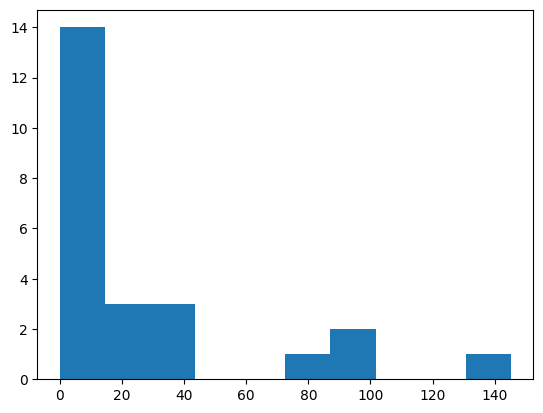

In [75]:
plt.hist(data['kld_loss'], bins=10)

#### - Plotar Lambda x KLD_loss
#### - Para cada lambda, plotar dim x KLD_loss
#### - Descobrir qual o valor min de KLD para que a dist seja normal
#### - Encontrar o melhor par lambda/dim respeitando o threshold de KLD encontrado, caso o tradeoff seja muito duro com a loss de recon, ignorar KLD e seguir com a clusterização

## KLD x Lambda

<Axes: xlabel='lambda', ylabel='kld_loss'>

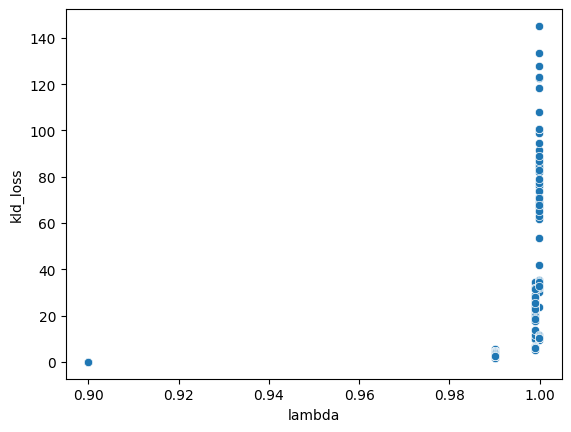

In [80]:
sns.scatterplot(data=df, x='lambda',y='kld_loss')

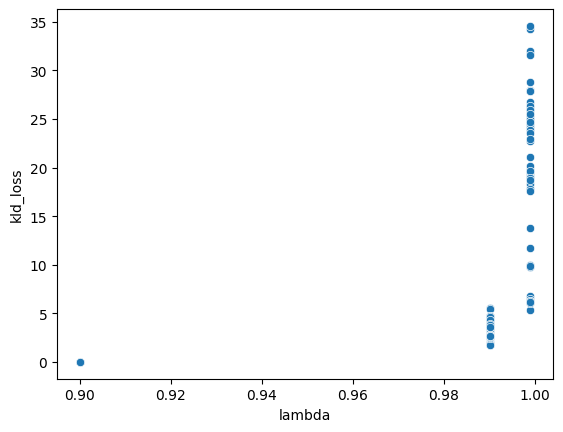

In [75]:
sns.scatterplot(data=df[df['lambda']<0.9999], x='lambda',y='kld_loss')
plt.show()

<Axes: xlabel='kld_loss'>

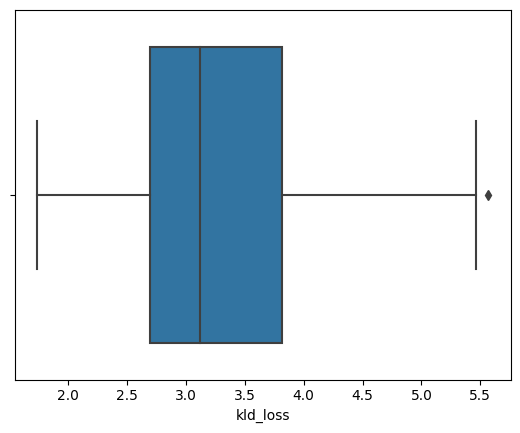

In [111]:
sns.boxplot(data=df[df['lambda']==0.99],x='kld_loss')

<Axes: xlabel='kld_loss'>

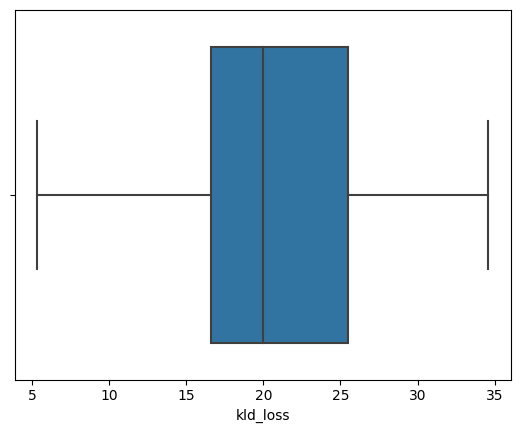

In [48]:
sns.boxplot(data=df[df['lambda']==0.999],x='kld_loss')

#### Lambda =0.99 deixa 75% dos KLD abaixo de 4
#### Lambda =0.999 deixa 75% dos KLD abaixo de 26
#### Resta entender como recon_loss se comporta com esses valores de lambda e verificar se esses valores de KLD são aceitáveis

## Recon_loss

<Axes: xlabel='recon_loss'>

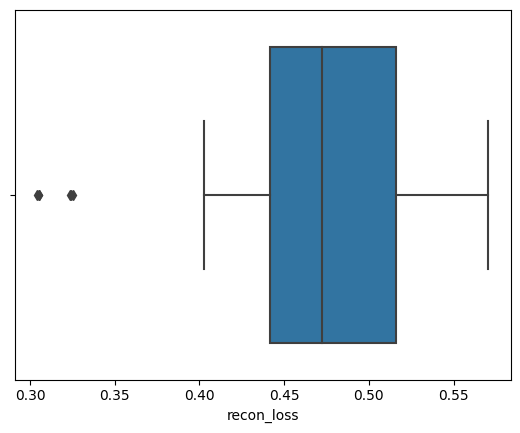

In [76]:
sns.boxplot(data=df[(df['lambda']==0.99)],x='recon_loss')

<Axes: xlabel='recon_loss'>

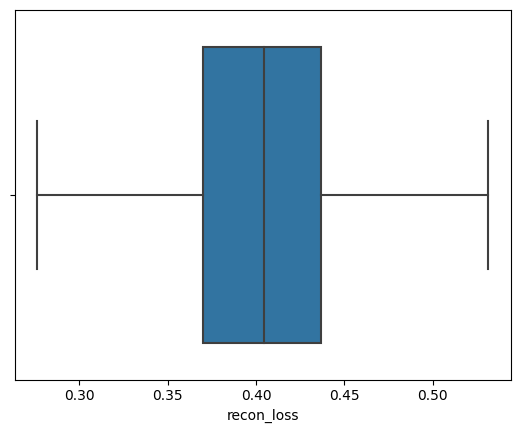

In [73]:
sns.boxplot(data=df[(df['lambda']==0.999)],x='recon_loss',hue='dim')

#### Visualmente, valores de recon acima de 0.5 parecem instáveis.
#### Lambda 0.999 resulta em 75% de recon abaixo de 0.45, o que parece a princípio um excelente resultado, mas tem o tradeoff com KLD.

## Embedding dimension and the losses

<Axes: xlabel='dim', ylabel='recon_loss'>

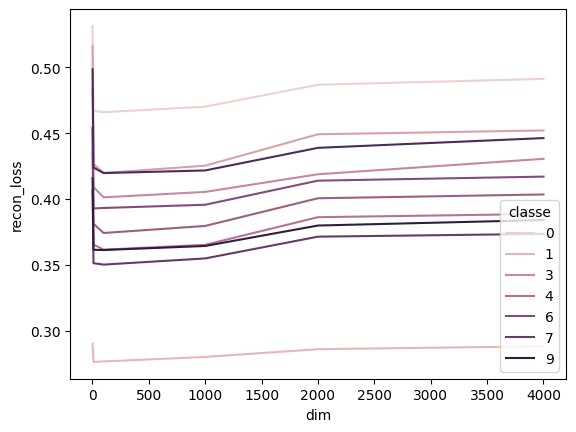

In [45]:
sns.lineplot(data=df[df['lambda']==0.999],x='dim',y='recon_loss',hue='classe')

#### Dim parece não afetar significativamente a recon_loss para lambda fixo em 0.999

<Axes: xlabel='dim', ylabel='kld_loss'>

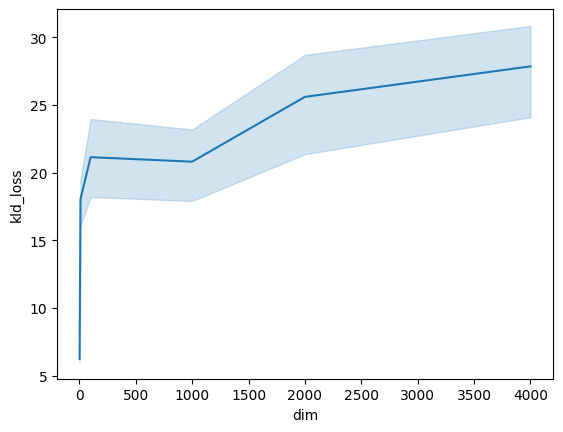

In [82]:
sns.lineplot(data=df[df['lambda']==0.999],x='dim',y='kld_loss')

#### No entanto, é possível ver que a KLD loss pode ser minimizada ajustando a dimensão para um lambda fixo em 0.999

<Axes: xlabel='dim', ylabel='kld_loss'>

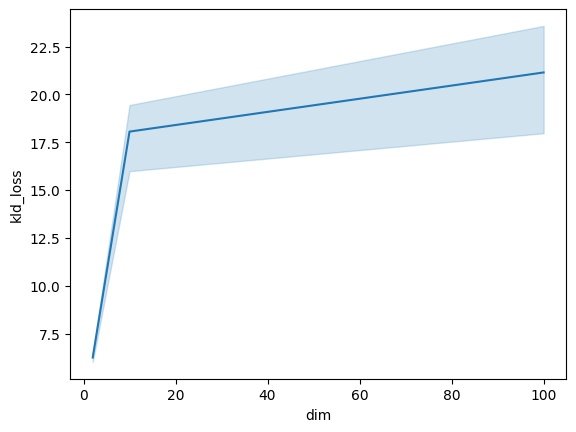

In [84]:
sns.lineplot(data=df[(df['lambda']==0.999)&(df['dim']<1000)],x='dim',y='kld_loss')

<Axes: xlabel='dim', ylabel='recon_loss'>

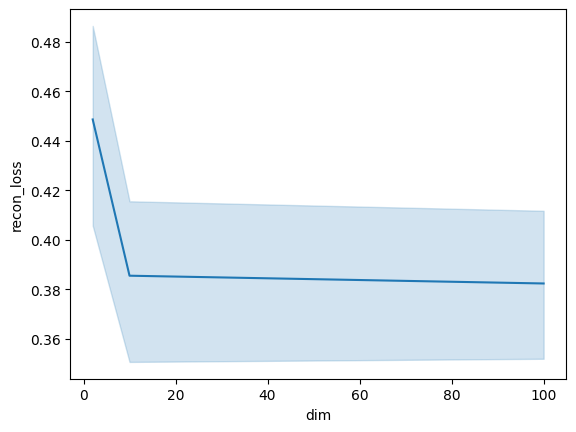

In [88]:
sns.lineplot(data=df[(df['lambda']==0.999)&(df['dim']<=100)],x='dim',y='recon_loss')

In [115]:
def find_losses(df,lamb,dim):

    cut = df[(df['lambda']==lamb)&(df['dim']==dim)][['classe','total_loss','recon_loss','kld_loss']].reset_index().drop('index',axis=1)
            
    return cut

In [116]:
find_losses(df=df,lamb=0.999,dim = 10)

,classe,total_loss,recon_loss,kld_loss
0,0,0.484353,0.467021,17.799384
1,1,0.285691,0.276195,9.772134
2,2,0.447291,0.426665,21.052802
3,3,0.428360,0.409073,19.696081
4,4,0.384316,0.365461,19.220116
5,5,0.400567,0.381164,19.783907
6,6,0.410707,0.392831,18.268903
7,7,0.368625,0.351212,17.763910
8,8,0.443130,0.423921,19.633011
9,9,0.378593,0.361412,17.542668


In [119]:
def get_result(quantile):

    for dim in params['embedding_dim']:
        recon = find_losses(df,0.999,dim)['recon_loss']
        kld = find_losses(df,0.999,dim)['kld_loss']
        print(f'dim = {dim}')
        print(f'Recon_loss -> {100*quantile}% abaixo de {recon.quantile(quantile)}')
        print(f'KLD_loss -> {100*quantile}% abaixo de {kld.quantile(quantile)}')
        print('________________________________________________________________')
    

In [120]:
get_result(0.75)

dim = 2
Recon_loss -> 75.0% abaixo de 0.4950577211431295
KLD_loss -> 75.0% abaixo de 6.378811722160668
________________________________________________________________
dim = 10
Recon_loss -> 75.0% abaixo de 0.4202090843540171
KLD_loss -> 75.0% abaixo de 19.680313401896022
________________________________________________________________
dim = 100
Recon_loss -> 75.0% abaixo de 0.4150965118551276
KLD_loss -> 75.0% abaixo de 24.404127662596494
________________________________________________________________
dim = 1000
Recon_loss -> 75.0% abaixo de 0.41762269582545414
KLD_loss -> 75.0% abaixo de 23.99364638717278
________________________________________________________________
dim = 2000
Recon_loss -> 75.0% abaixo de 0.43386315601621417
KLD_loss -> 75.0% abaixo de 27.901740758315377
________________________________________________________________
dim = 4000
Recon_loss -> 75.0% abaixo de 0.4423545496740743
KLD_loss -> 75.0% abaixo de 31.768449087505754
_______________________________________

In [121]:
get_result(0.9)

dim = 2
Recon_loss -> 90.0% abaixo de 0.5178130729745684
KLD_loss -> 90.0% abaixo de 6.486865152161291
________________________________________________________________
dim = 10
Recon_loss -> 90.0% abaixo de 0.43070036279128365
KLD_loss -> 90.0% abaixo de 19.91079659502085
________________________________________________________________
dim = 100
Recon_loss -> 90.0% abaixo de 0.4244121293581424
KLD_loss -> 90.0% abaixo de 26.073743245909558
________________________________________________________________
dim = 1000
Recon_loss -> 90.0% abaixo de 0.42980179878591374
KLD_loss -> 90.0% abaixo de 25.008892006145025
________________________________________________________________
dim = 2000
Recon_loss -> 90.0% abaixo de 0.4529582506512319
KLD_loss -> 90.0% abaixo de 31.933924313856195
________________________________________________________________
dim = 4000
Recon_loss -> 90.0% abaixo de 0.4560215655166261
KLD_loss -> 90.0% abaixo de 32.30030549038524
________________________________________

#### A dimensão 10 parece a mais promissora, mas não sei se isso vale pra clusterização, a próxima coisa a se fazer é entender esse range (6,32) de KLD_loss. Qual o máximo aceitável para que a distribuição no espaço latente seja próxima de uma gaussiana?

# Fixado lambda em 0.999, testar, para cada dimensão do espaço latente, se as distribuições geradas são estatisticamente gaussianas 